In [16]:
import os
import sys

import pandas as pd
from rdkit import RDLogger, rdBase, Chem
from rdkit.Chem import Draw

# Disable the RDKit warnings that pop up when RDKit fails to create molecules
RDLogger.DisableLog("rdApp.*")
blocker = rdBase.BlockLogs()

if 'ipykernel' in sys.modules:
    from tqdm.auto import tqdm  # for notebooks
    from IPython.display import display
else:
    from tqdm import tqdm

def safe_display(*args):
    """Displays content only if running in a Jupyter notebook."""
    if 'ipykernel' in sys.modules:
        display(*args)
    else:
        print(*args)

In [17]:
# Open file data/protacs_not_splitted_predicted.csv
df = pd.read_csv("data/protacs_not_splitted_predicted.csv")

# Isolate the correct predictions by checking the "correct" column
correct_df = df[df["correct"]]

print(f"Number of correct predictions: {len(correct_df):,}")

Number of correct predictions: 463


PROTAC: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCCOCCOCCOc2ccc(N3C(=S)N(c4ccc(C#N)c(C(F)(F)F)c4)C(=O)C3(C)C)cc2)C(C)(C)C)cc1
E3:     [*:2]N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker: [*:2]C(=O)COCCOCCOCC[*:1]
POI:    [*:1]Oc1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)C(=O)C2(C)C)cc1


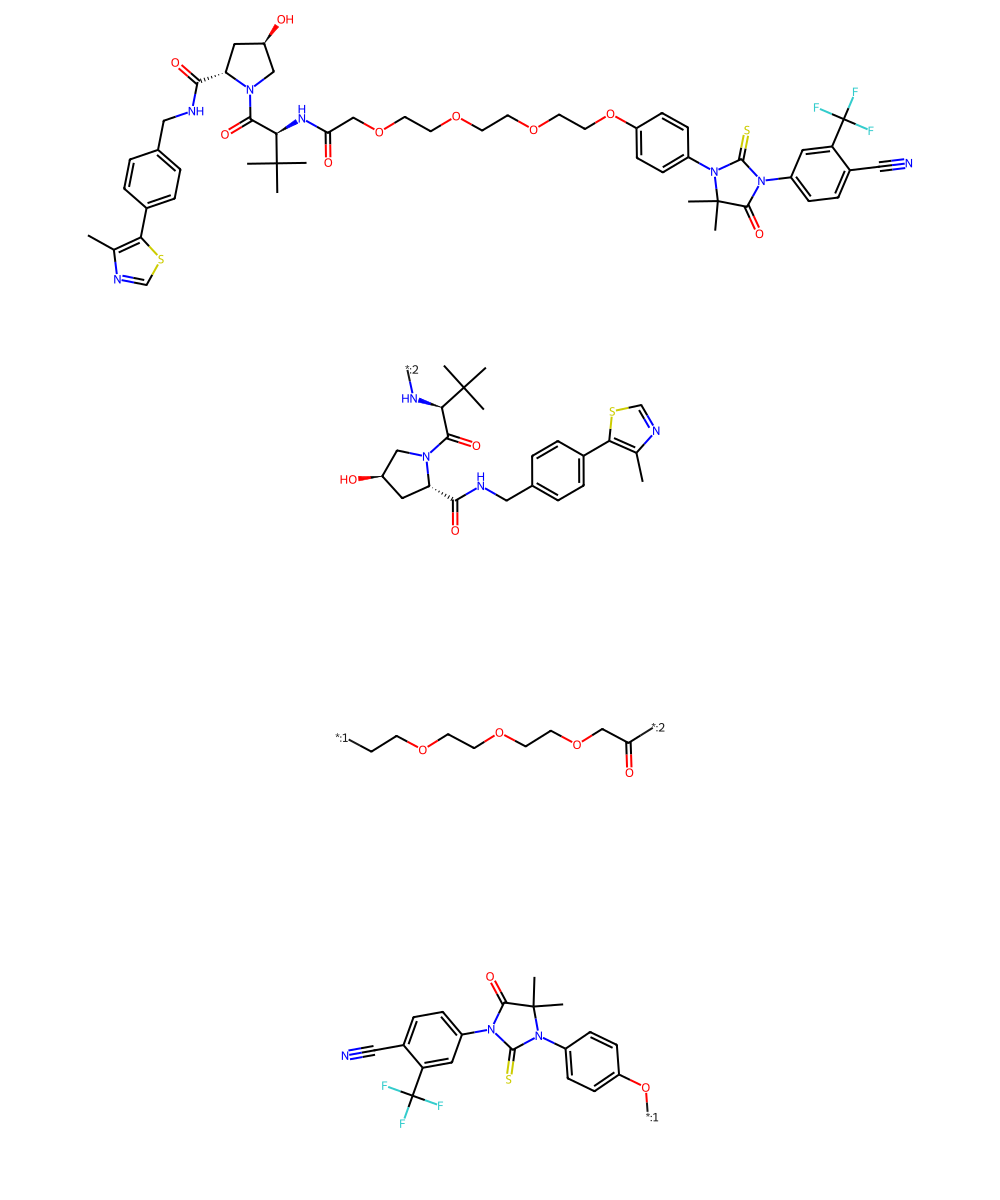

--------------------------------------------------------------------------------
PROTAC: NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN(C(=O)CCCCCC#Cc3ccc4c(c3)CN(C3CCC(=O)NC3=O)C4=O)C[C@H](NC(=O)c3cc4cc(C(F)(F)P(=O)(O)O)ccc4[nH]3)C(=O)N21)C(=O)NC(c1ccccc1)c1ccccc1
E3:     [*:2]c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]C#CCCCC[*:1]
POI:    [*:1]CC(=O)N1CC[C@H]2CC[C@@H](C(=O)N[C@@H](CCC(N)=O)C(=O)NC(c3ccccc3)c3ccccc3)N2C(=O)[C@@H](NC(=O)c2cc3cc(C(F)(F)P(=O)(O)O)ccc3[nH]2)C1


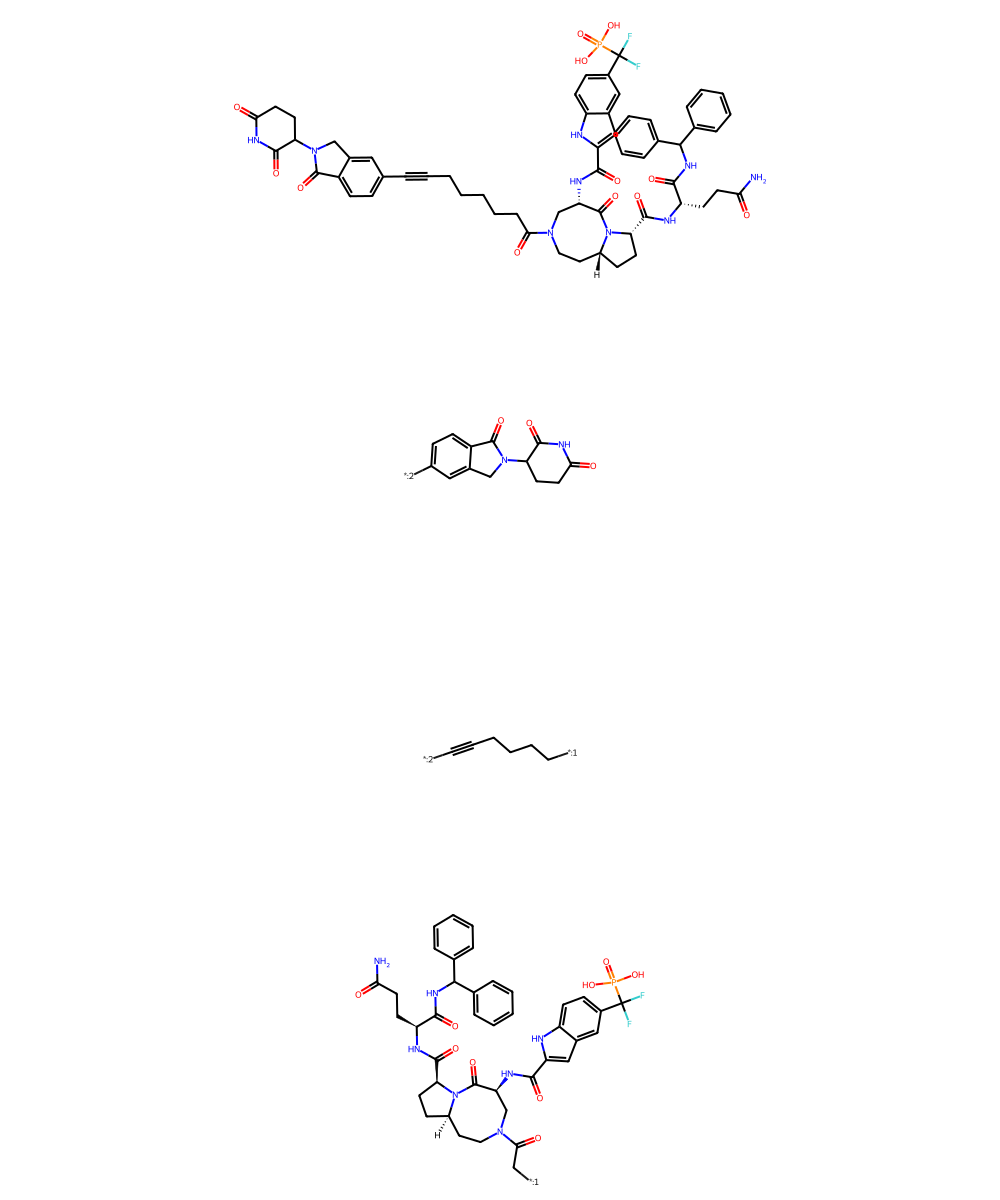

--------------------------------------------------------------------------------
PROTAC: Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCN(CCOCCOCCOc2ccc3c(c2)CN(C2CCC(=O)NC2=O)C3=O)CC1
E3:     [*:2]c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]OCCOCCOCC[*:1]
POI:    [*:1]N1CCC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1


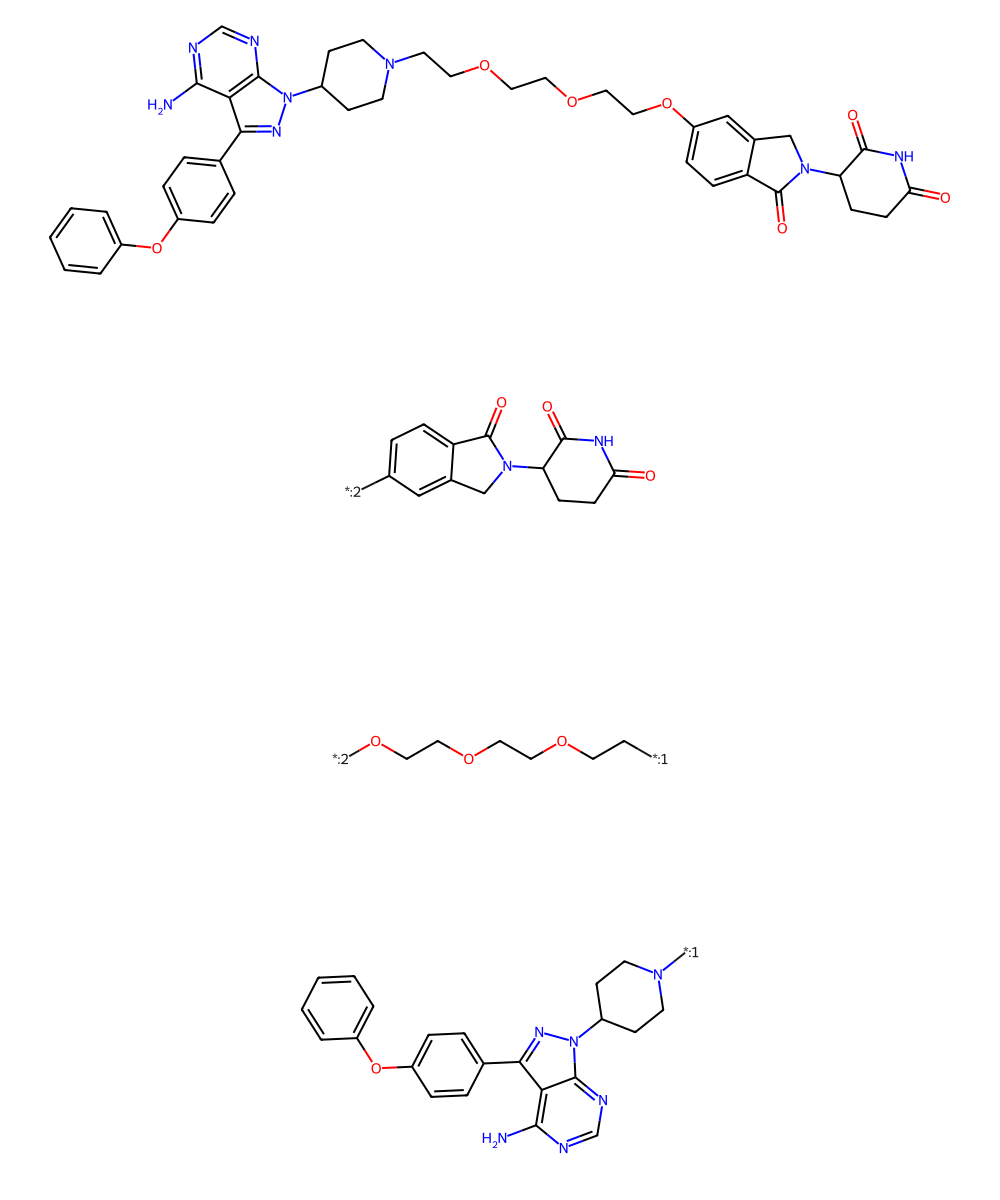

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCCOc2ccc(-c3cc(Nc4ccc(OC(F)(F)F)cc4)ncn3)cc2)C(C)(C)C)cc1
E3:     [*:2]N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker: [*:2]C(=O)COCC[*:1]
POI:    [*:1]Oc1ccc(-c2cc(Nc3ccc(OC(F)(F)F)cc3)ncn2)cc1


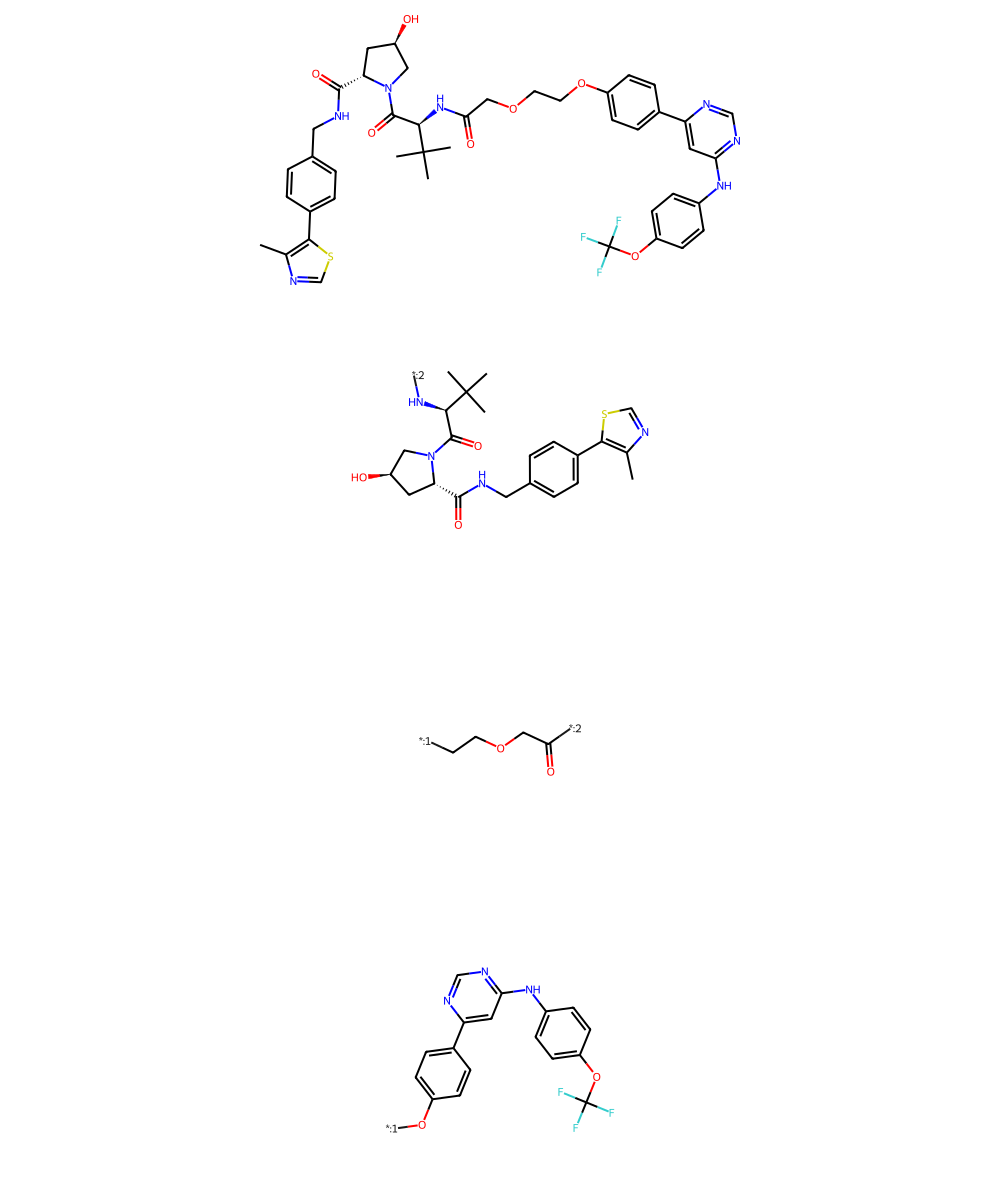

--------------------------------------------------------------------------------
PROTAC: CC/C(=C(\c1ccc(O)cc1)c1ccc(OCCN(C)C(=O)COCCOCCOCCOc2cccc(O[C@@H]3C[C@@H](C(=O)N[C@@H]4CCCc5ccccc54)N(C(=O)[C@@H](NC(=O)[C@H](C)NC)C4CCCCC4)C3)c2)cc1)c1ccccc1
E3:     [*:2]c1cccc(O[C@@H]2C[C@@H](C(=O)N[C@@H]3CCCc4ccccc43)N(C(=O)[C@@H](NC(=O)[C@H](C)NC)C3CCCCC3)C2)c1
Linker: [*:2]OCCOCCOCCOCC(=O)[*:1]
POI:    [*:1]N(C)CCOc1ccc(/C(=C(/CC)c2ccccc2)c2ccc(O)cc2)cc1


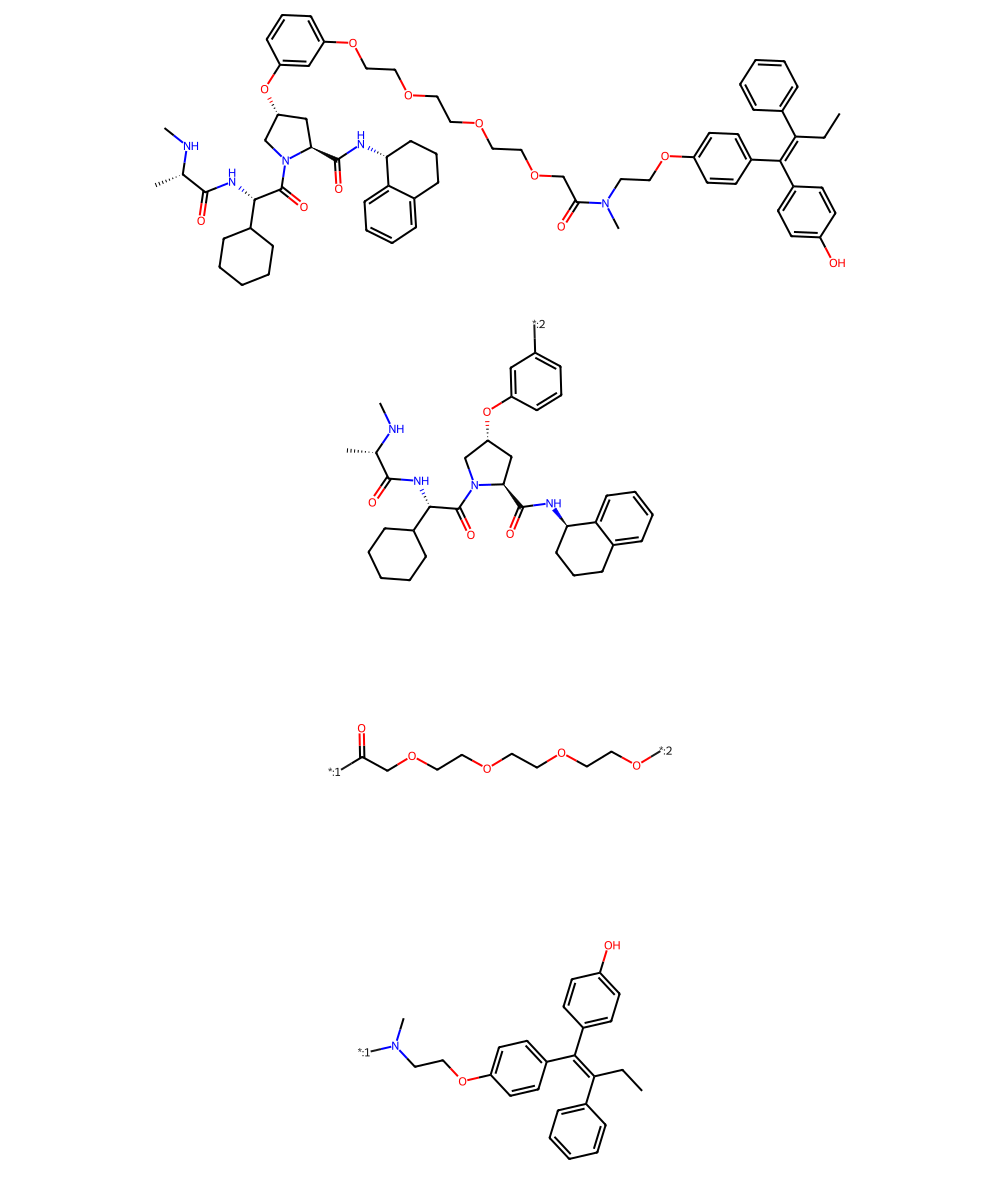

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCOCCOCCOCCn2cc(CCCCN(C)Cc3ccc(-c4[nH]c5cc(F)cc6c5c4CCNC6=O)cc3)nn2)C(C)(C)C)cc1
E3:     [*:2]N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker: [*:2]C(=O)CCOCCOCCOCCn1cc(CCCC[*:1])nn1
POI:    [*:1]N(C)Cc1ccc(-c2[nH]c3cc(F)cc4c3c2CCNC4=O)cc1


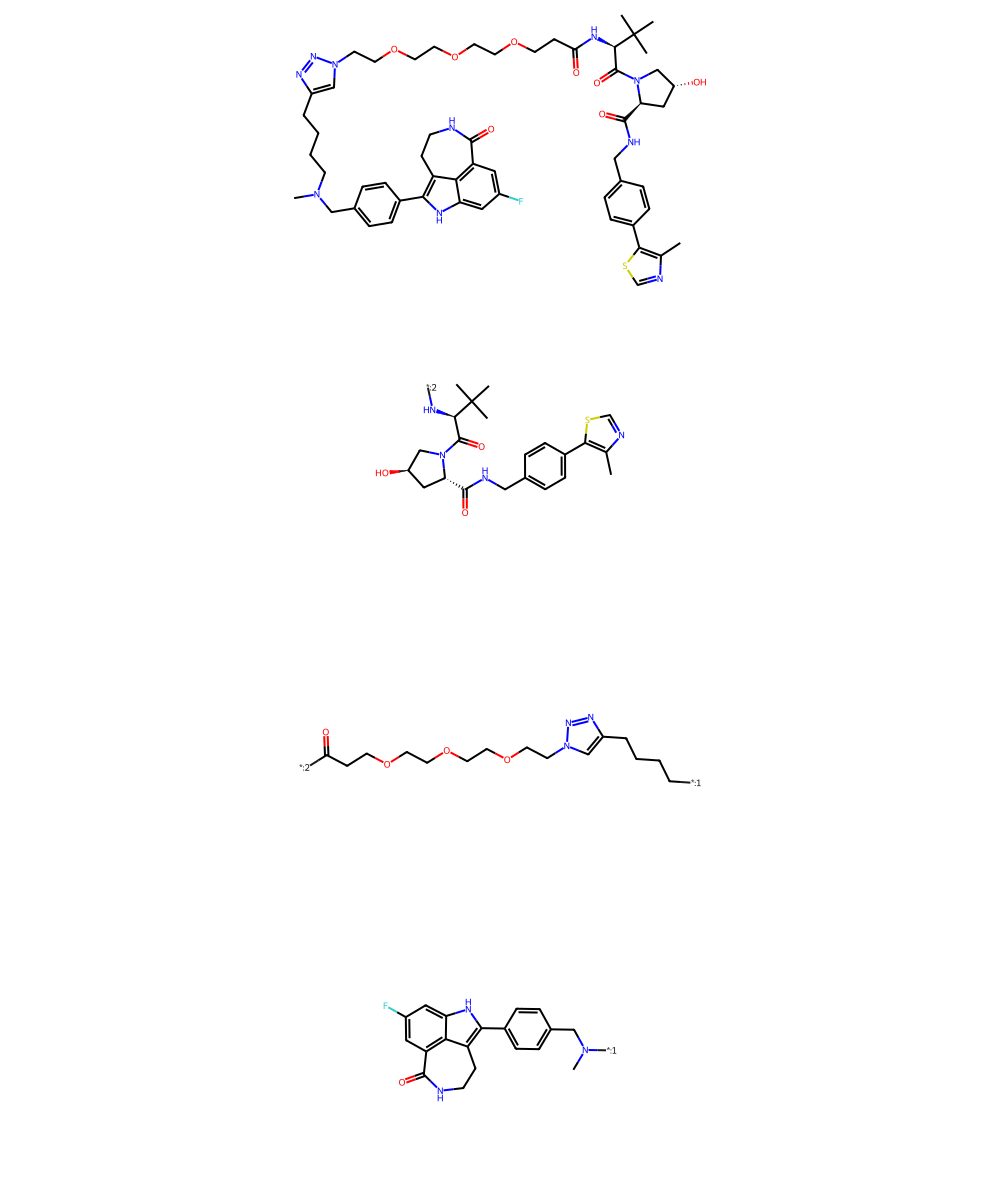

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCOCCOCCOCCOCCn2cc(CCCCN(C)Cc3ccc(-c4[nH]c5cc(F)cc6c5c4CCNC6=O)cc3)nn2)C(C)(C)C)cc1
E3:     [*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker: [*:2]COCCOCCOCCOCCn1cc(CCCC[*:1])nn1
POI:    [*:1]N(C)Cc1ccc(-c2[nH]c3cc(F)cc4c3c2CCNC4=O)cc1


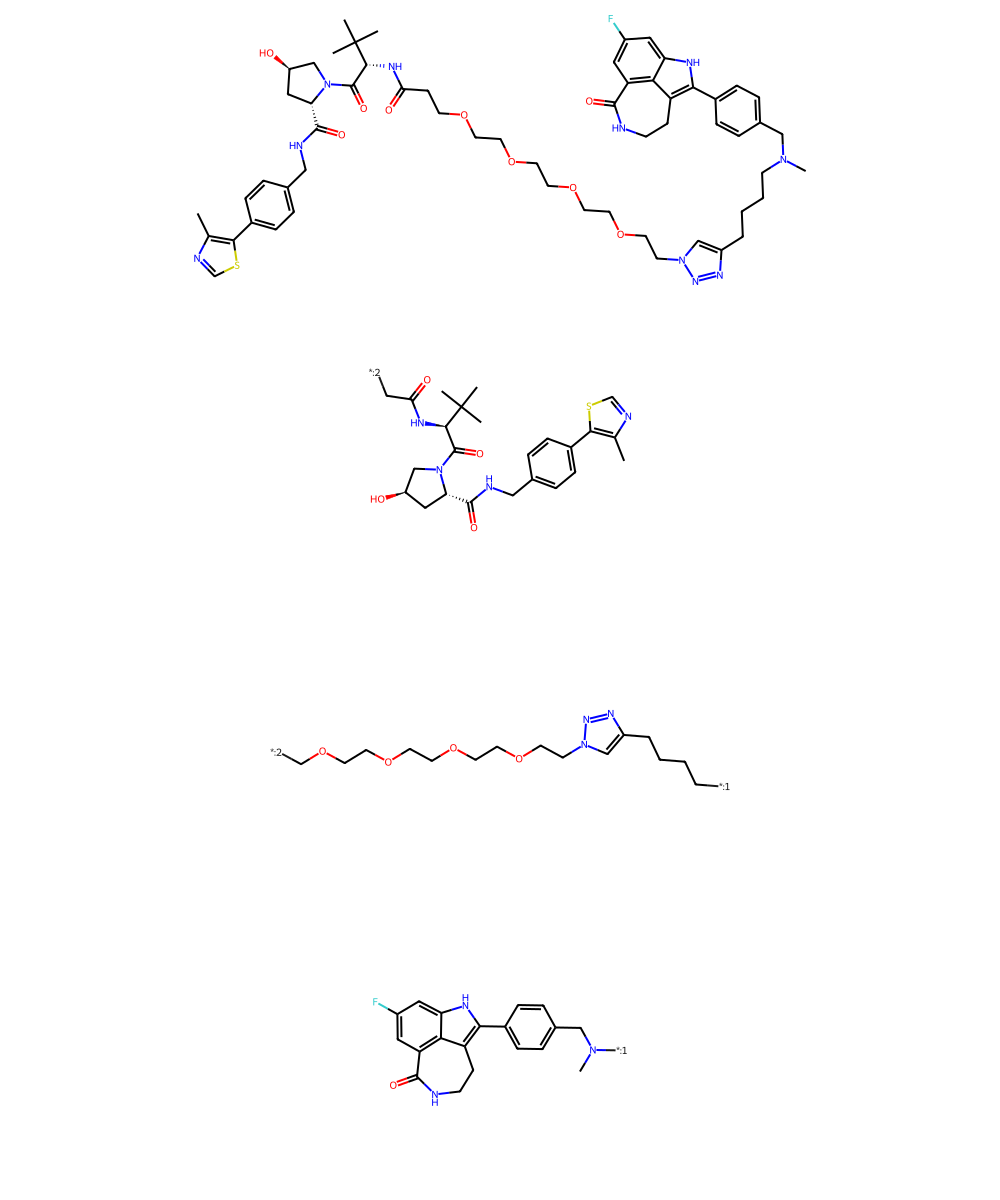

--------------------------------------------------------------------------------
PROTAC: CC1(C)C(=O)N(c2ccc(C#N)c(C(F)(F)F)c2)C(=S)N1c1ccc(OCCOCCOCCOCCOc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)cc1
E3:     [*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]OCCOCCOCCOCC[*:1]
POI:    [*:1]Oc1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)C(=O)C2(C)C)cc1


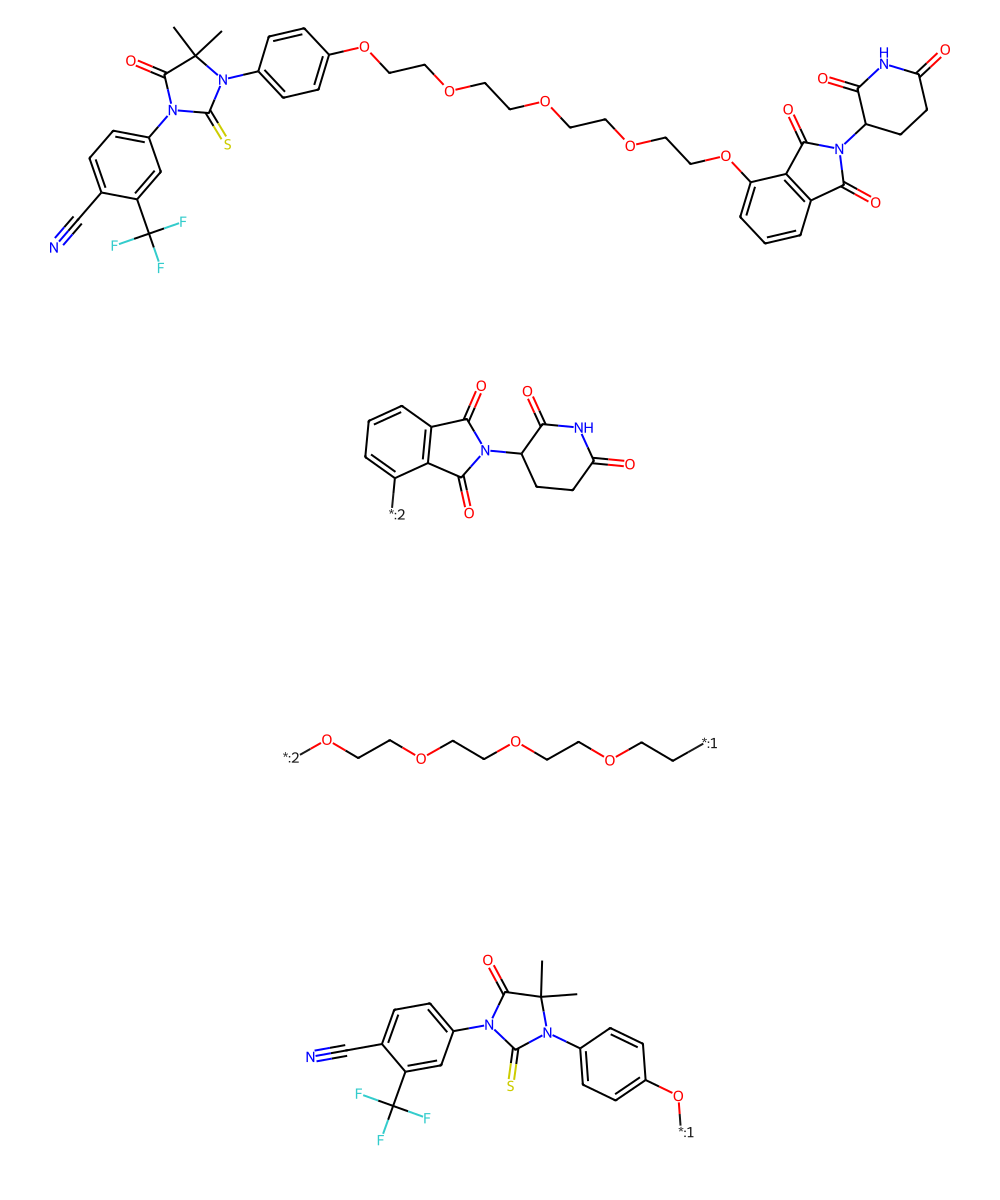

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCCCOCCCCOc2ccc(N3C(=S)N(c4ccc(C#N)c(C(F)(F)F)c4)C(=O)C3(C)C)cc2)C(C)(C)C)cc1
E3:     [*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker: [*:2]OCCCOCCCC[*:1]
POI:    [*:1]Oc1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)C(=O)C2(C)C)cc1


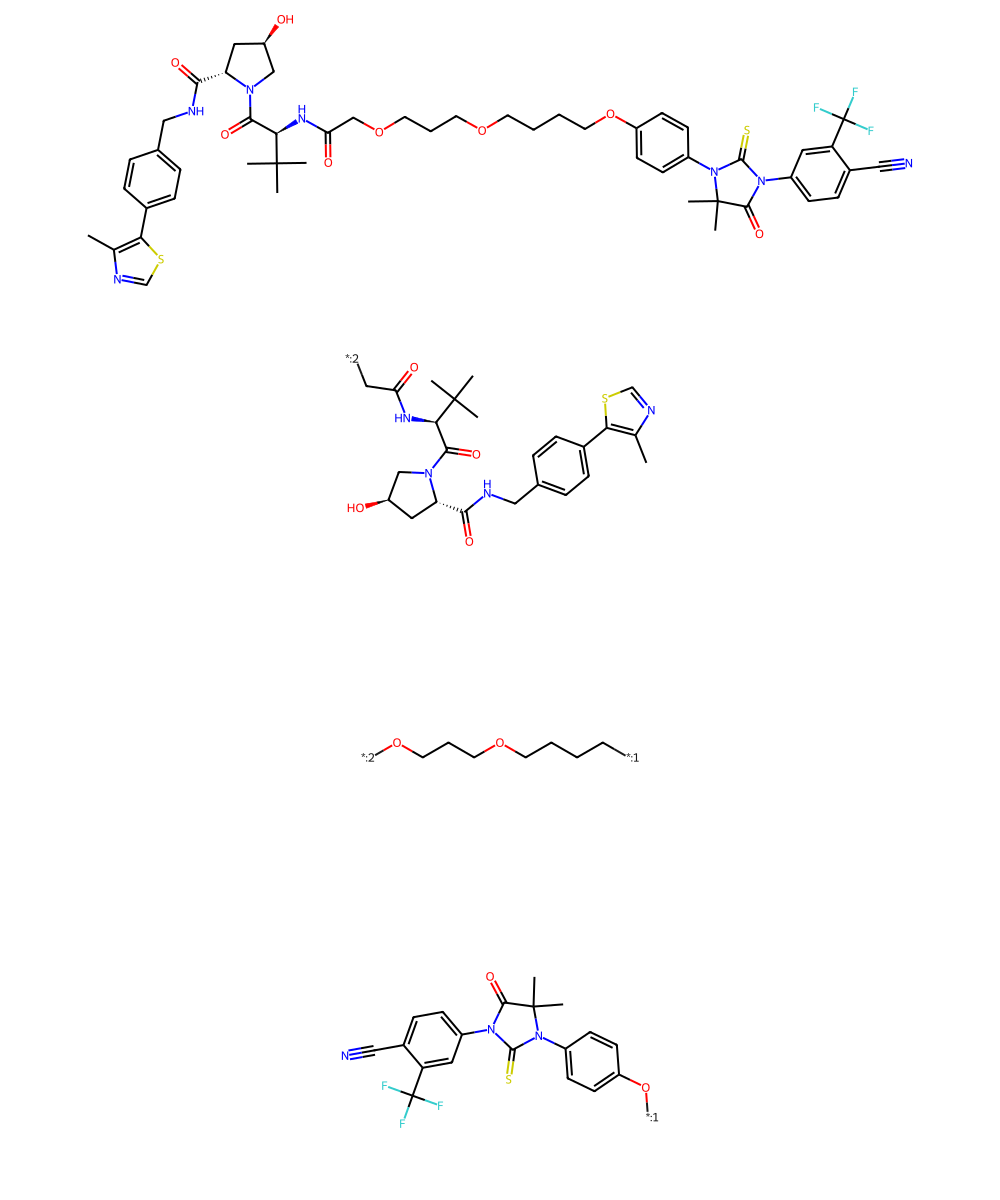

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCOCCOCCOCCOc2ccc(N3C(=S)N(c4ccc(C#N)c(C(F)(F)F)c4)C(=O)C3(C)C)cc2)C(C)(C)C)cc1
E3:     [*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker: [*:2]COCCOCCOCC[*:1]
POI:    [*:1]Oc1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)C(=O)C2(C)C)cc1


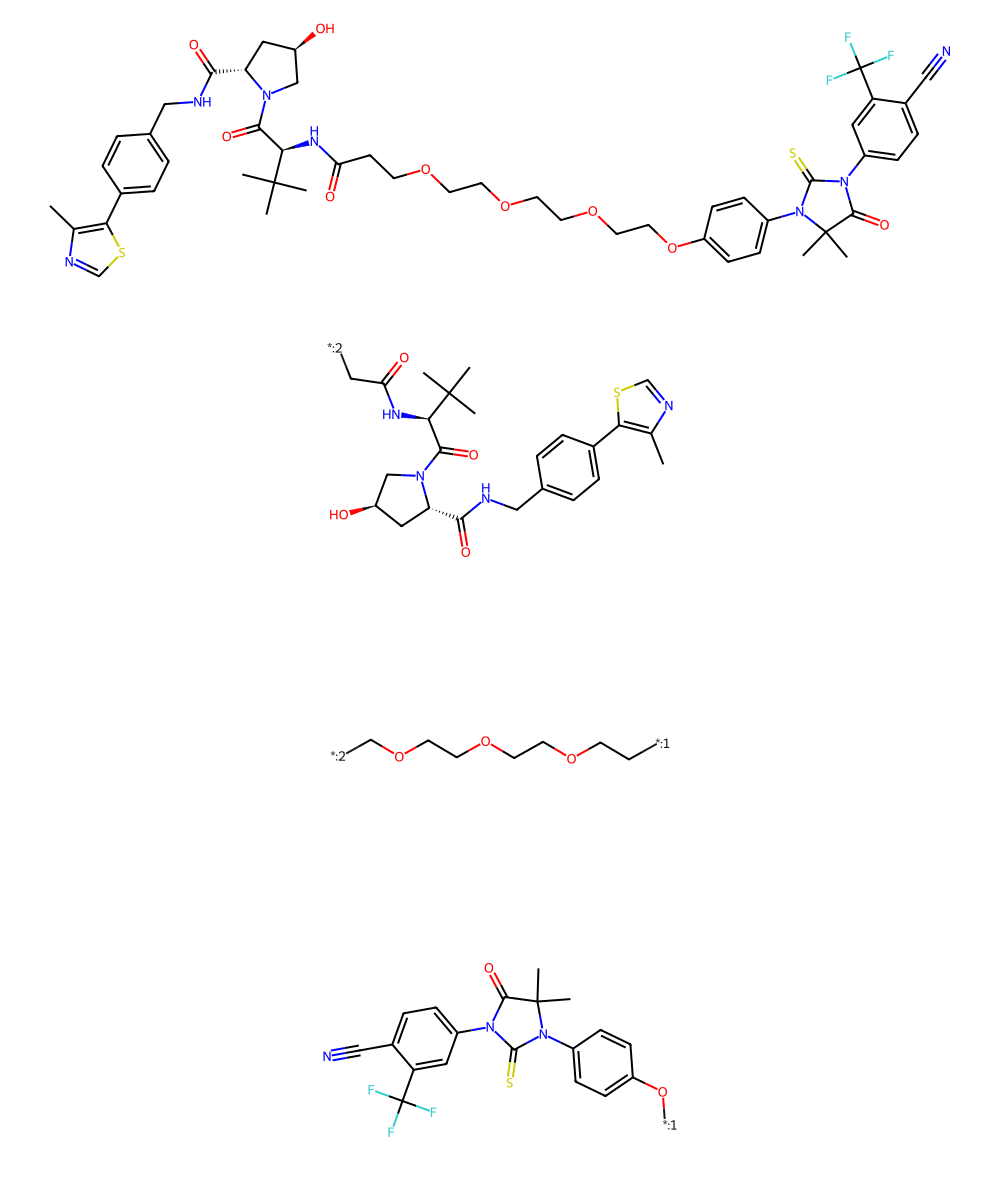

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCCCOCCCCOc2ccc(N3C(=S)N(c4ccc(C#N)c(C(F)(F)F)c4)C(=O)C3(C)C)cc2F)C(C)(C)C)cc1
E3:     [*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker: [*:2]OCCCOCCCC[*:1]
POI:    [*:1]Oc1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)C(=O)C2(C)C)cc1F


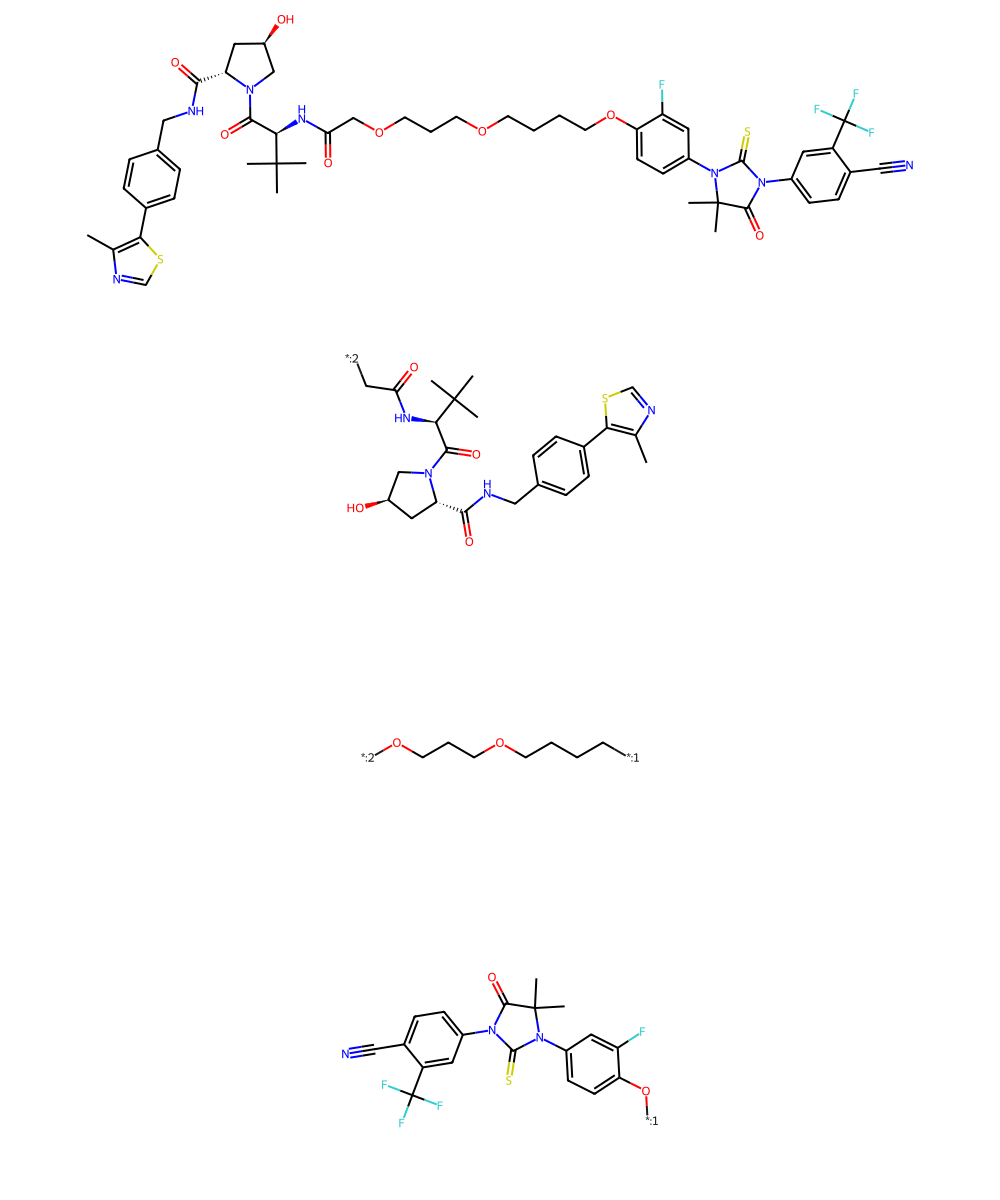

--------------------------------------------------------------------------------
PROTAC: C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCN(C(=O)CNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CC(=O)N1CCN(CCC[*:1])CC1
POI:    [*:1]Oc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)C=C


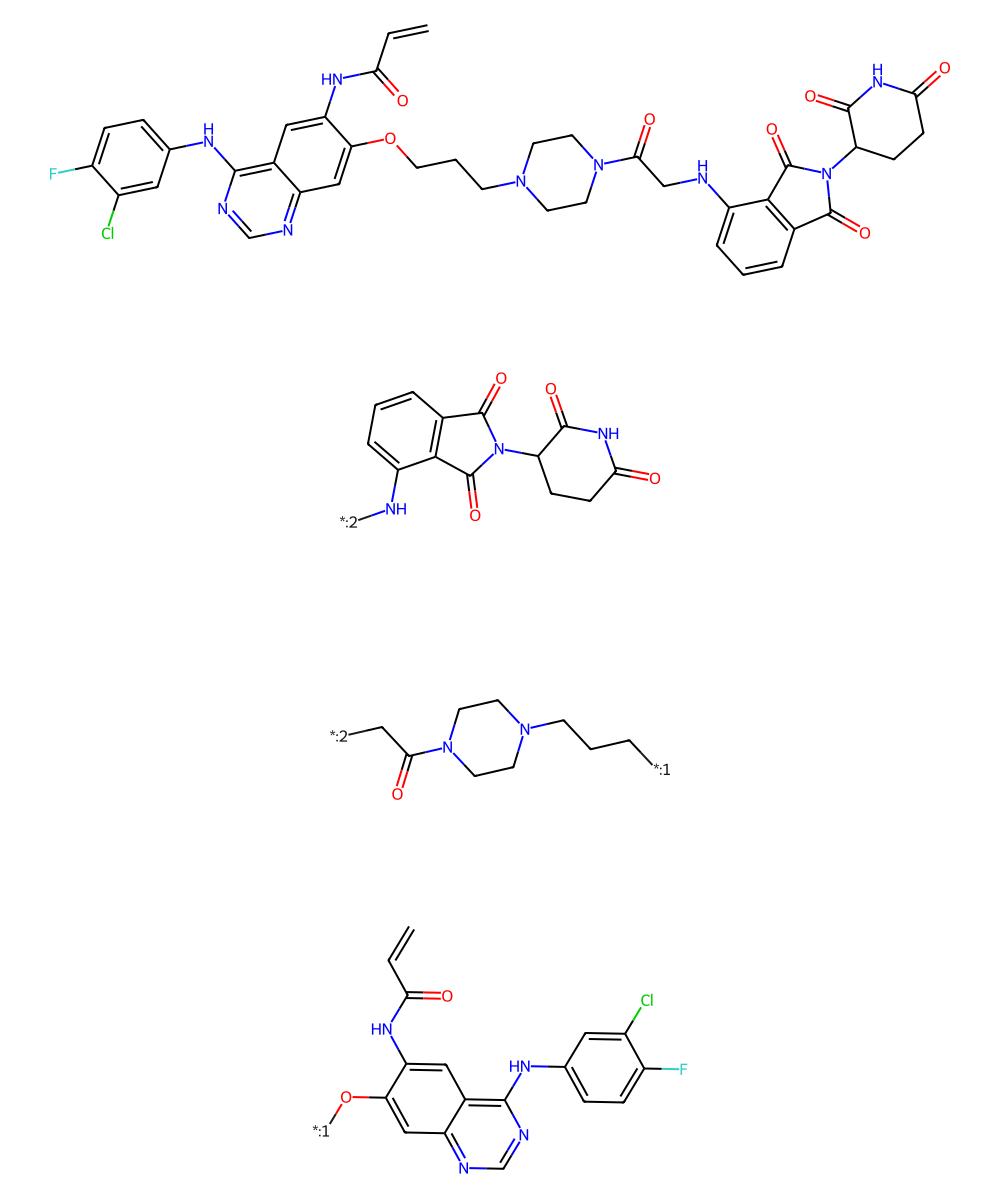

--------------------------------------------------------------------------------
PROTAC: C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCN(C(=O)CCCNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCC(=O)N1CCN(CCC[*:1])CC1
POI:    [*:1]Oc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)C=C


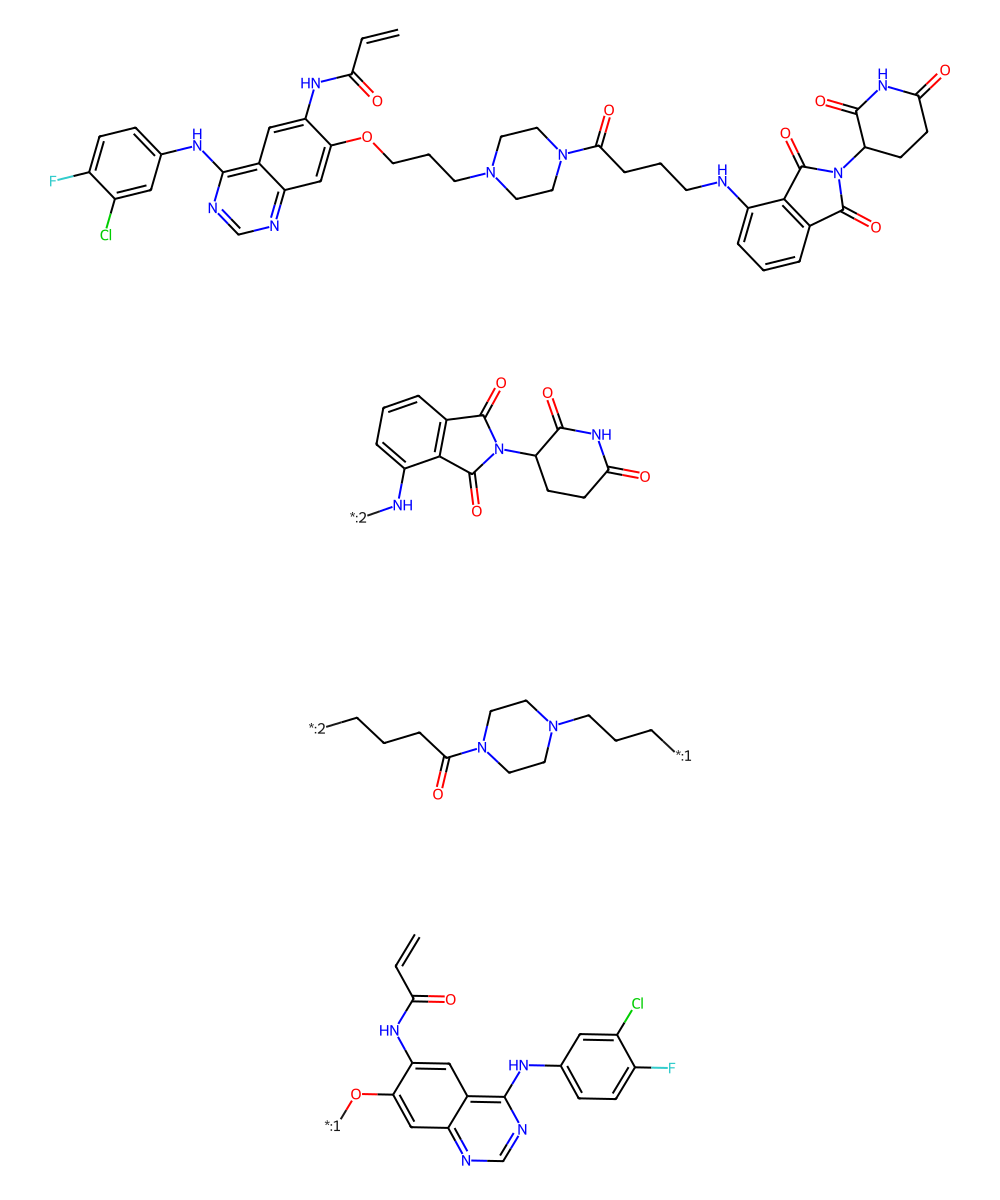

--------------------------------------------------------------------------------
PROTAC: COc1cc(Cl)c(-c2cc(Cl)ccc2Cl)cc1C(=O)N1CCN(C(=O)/C=C/C(=O)NCCNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCNC(=O)[*:1]
POI:    [*:1]/C=C/C(=O)N1CCN(C(=O)c2cc(-c3cc(Cl)ccc3Cl)c(Cl)cc2OC)CC1


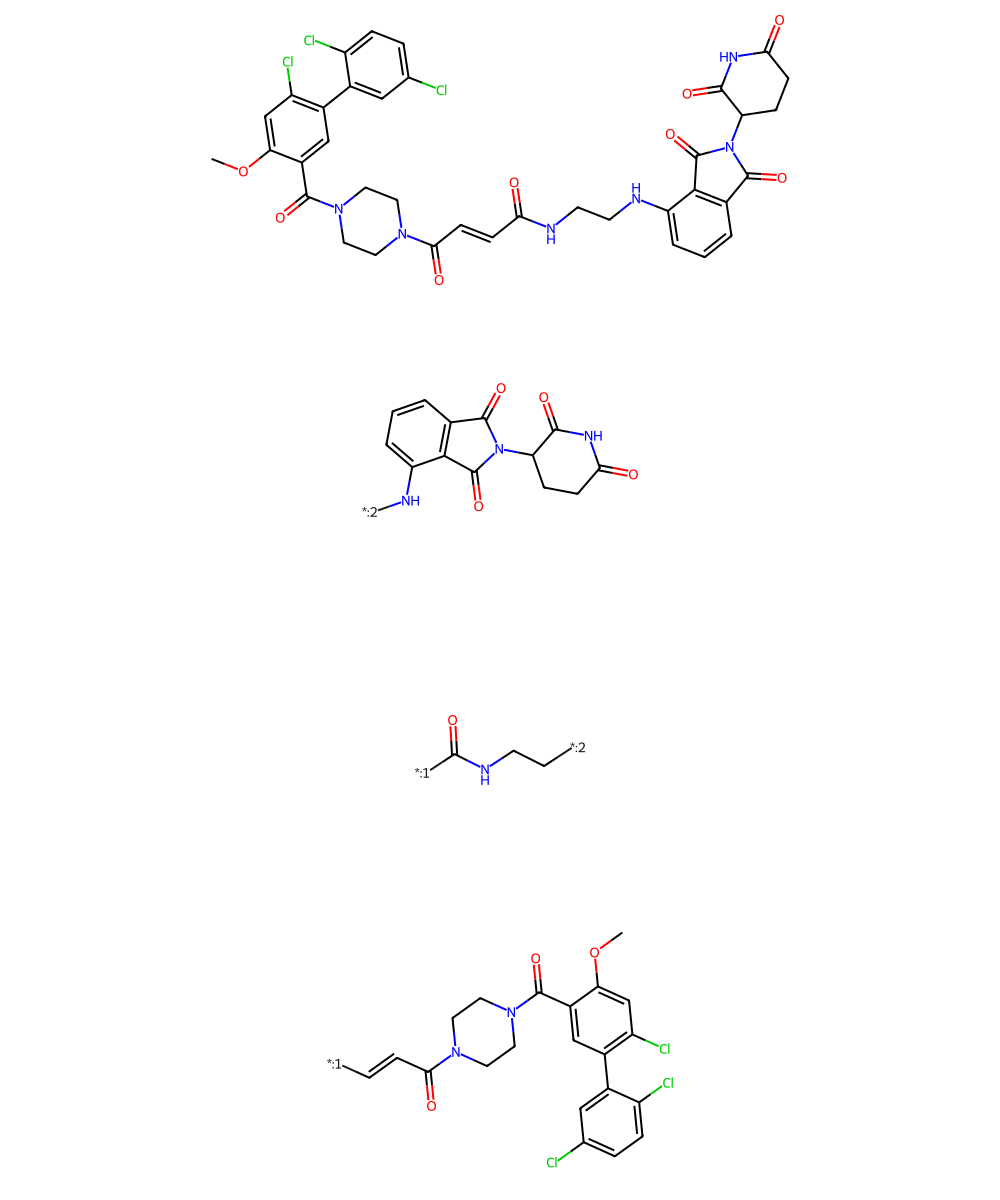

--------------------------------------------------------------------------------
PROTAC: COc1cc(Cl)c(-c2cc(Cl)ccc2Cl)cc1C(=O)N1CCN(C(=O)/C=C/C(=O)NCCCCCCNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCCCNC(=O)[*:1]
POI:    [*:1]/C=C/C(=O)N1CCN(C(=O)c2cc(-c3cc(Cl)ccc3Cl)c(Cl)cc2OC)CC1


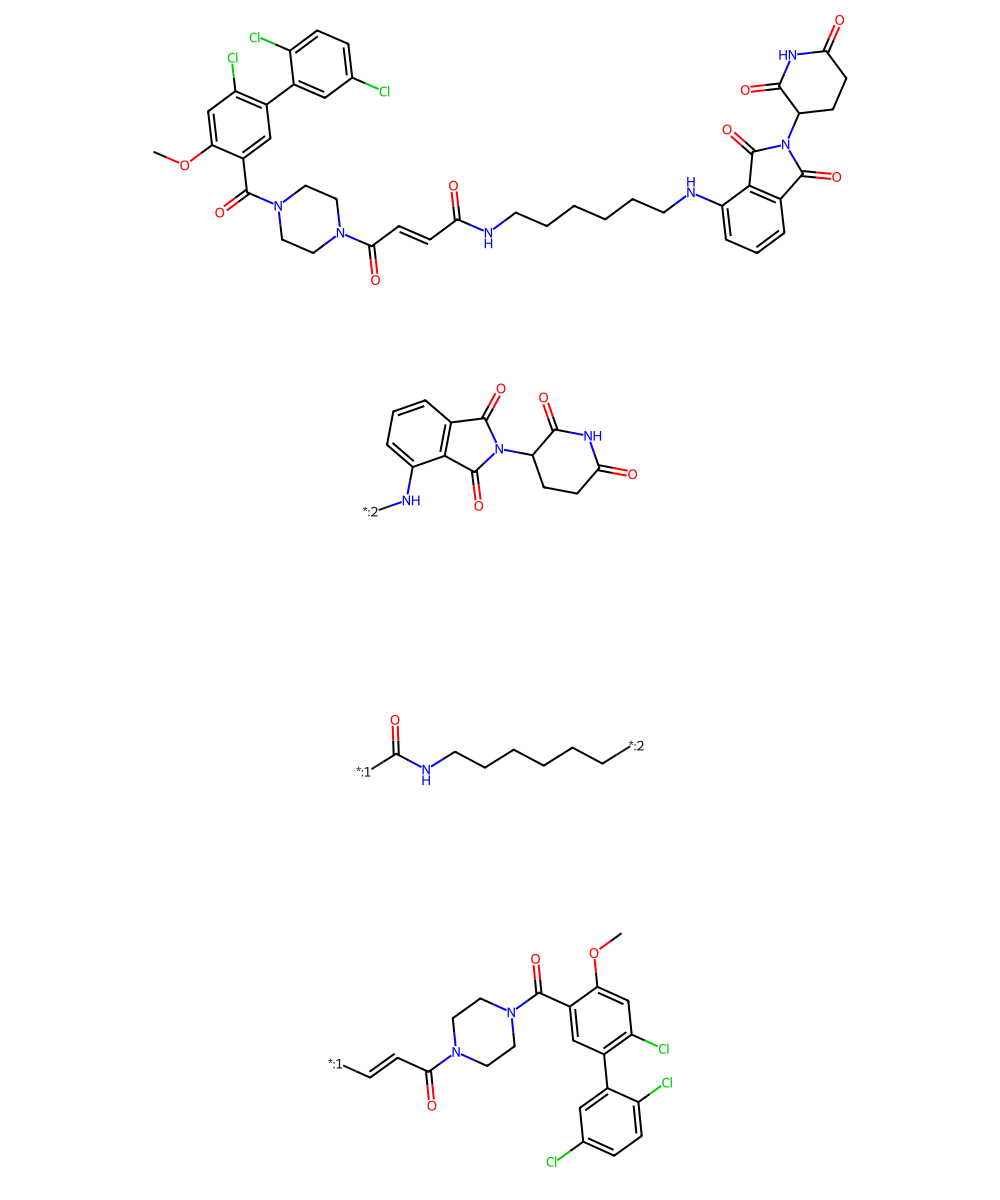

--------------------------------------------------------------------------------
PROTAC: COc1cc(Cl)c(-c2cc(Cl)ccc2Cl)cc1C(=O)N1CCN(C(=O)/C=C/C(=O)N2CCN(CC(=O)NCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)CC2)CC1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCNC(=O)CN1CCN(C(=O)[*:1])CC1
POI:    [*:1]/C=C/C(=O)N1CCN(C(=O)c2cc(-c3cc(Cl)ccc3Cl)c(Cl)cc2OC)CC1


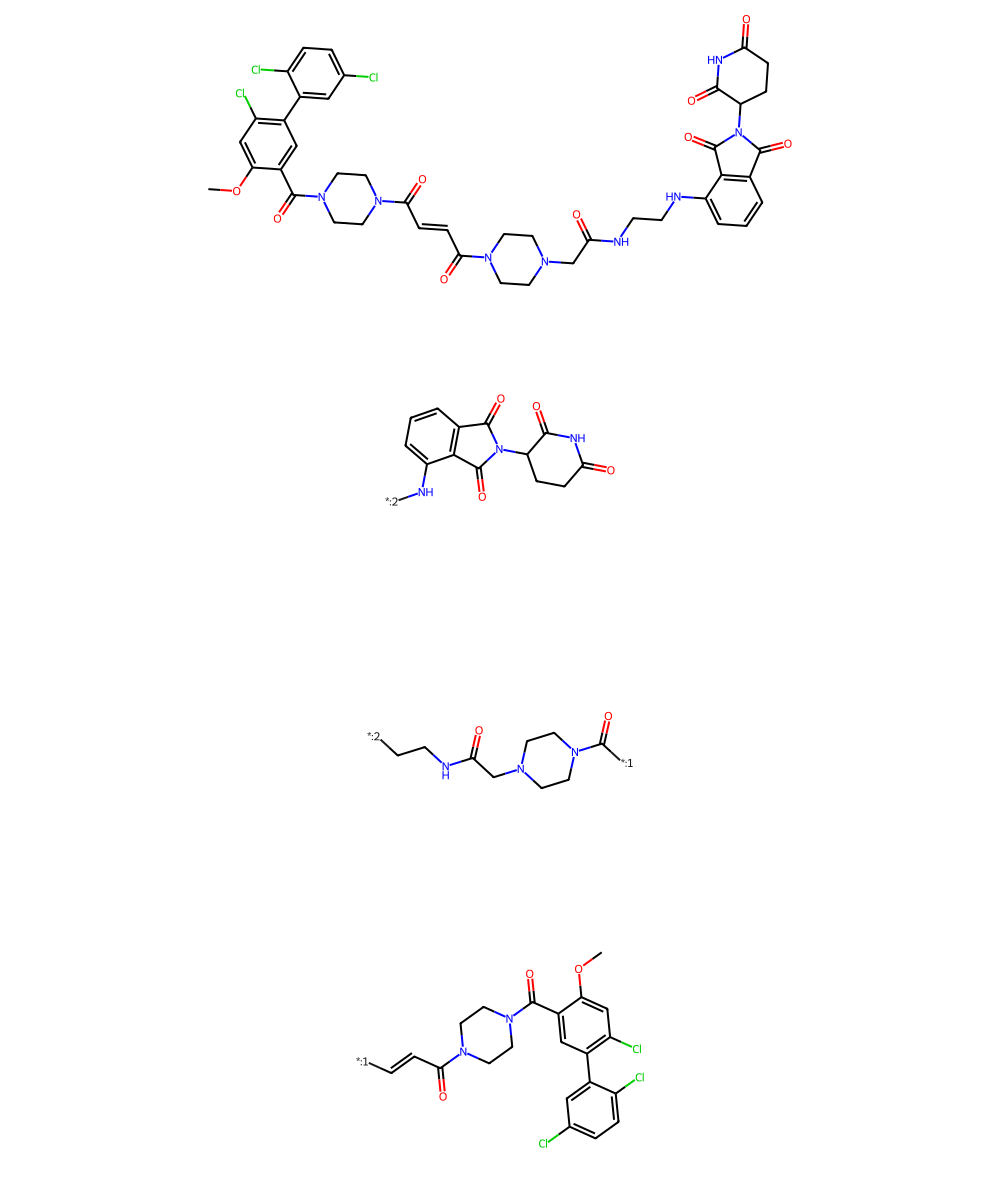

--------------------------------------------------------------------------------
PROTAC: COc1cc(Cl)c(-c2cc(Cl)ccc2Cl)cc1C(=O)N1CCN(C(=O)/C=C/C(=O)N2CCN(CC(=O)NCCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)CC2)CC1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCNC(=O)CN1CCN(C(=O)[*:1])CC1
POI:    [*:1]/C=C/C(=O)N1CCN(C(=O)c2cc(-c3cc(Cl)ccc3Cl)c(Cl)cc2OC)CC1


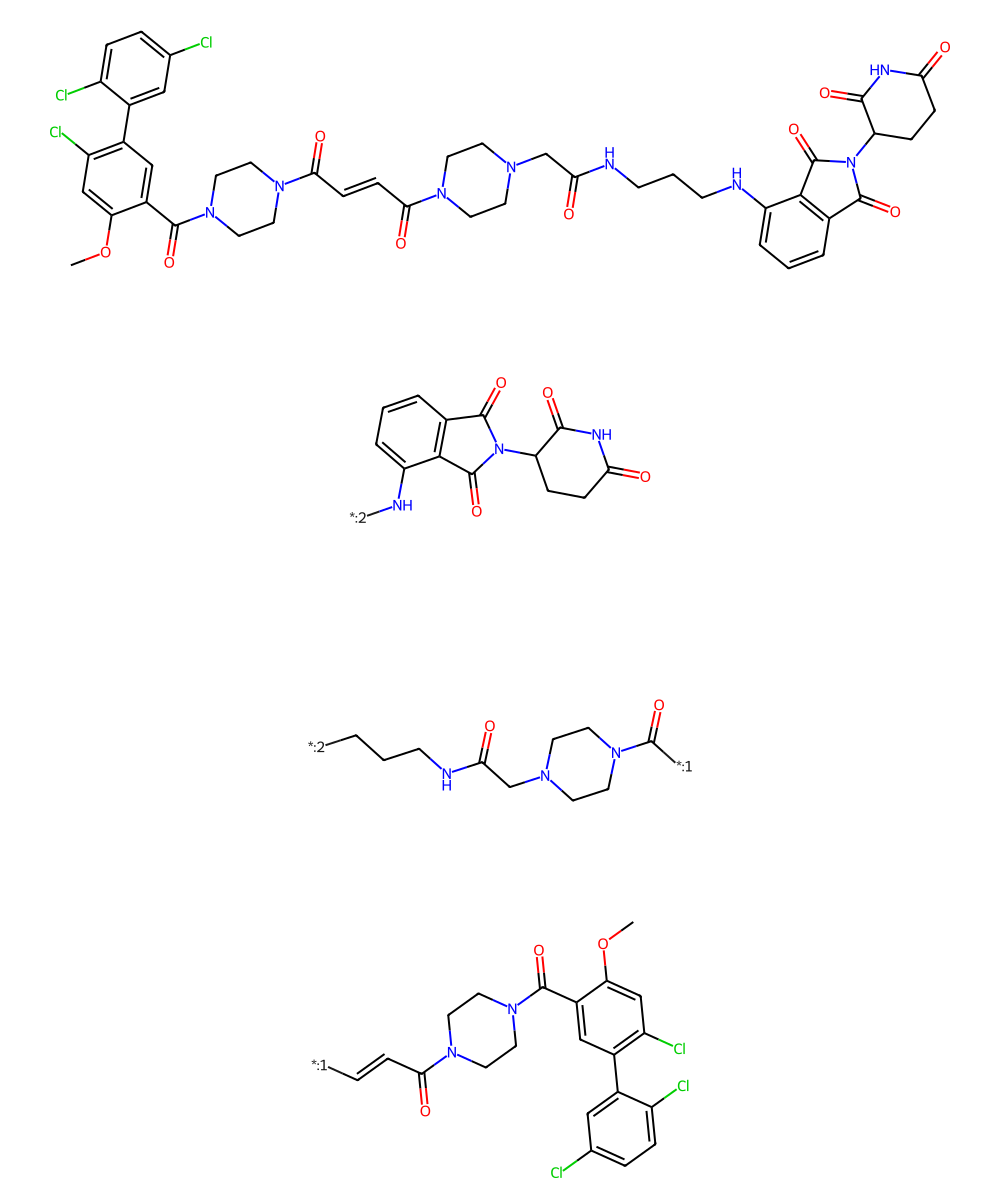

--------------------------------------------------------------------------------
PROTAC: COc1cc(Cl)c(-c2cc(Cl)ccc2Cl)cc1C(=O)N1CCN(C(=O)/C=C/C(=O)N2CCN(CC(=O)NCCCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)CC2)CC1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCNC(=O)CN1CCN(C(=O)[*:1])CC1
POI:    [*:1]/C=C/C(=O)N1CCN(C(=O)c2cc(-c3cc(Cl)ccc3Cl)c(Cl)cc2OC)CC1


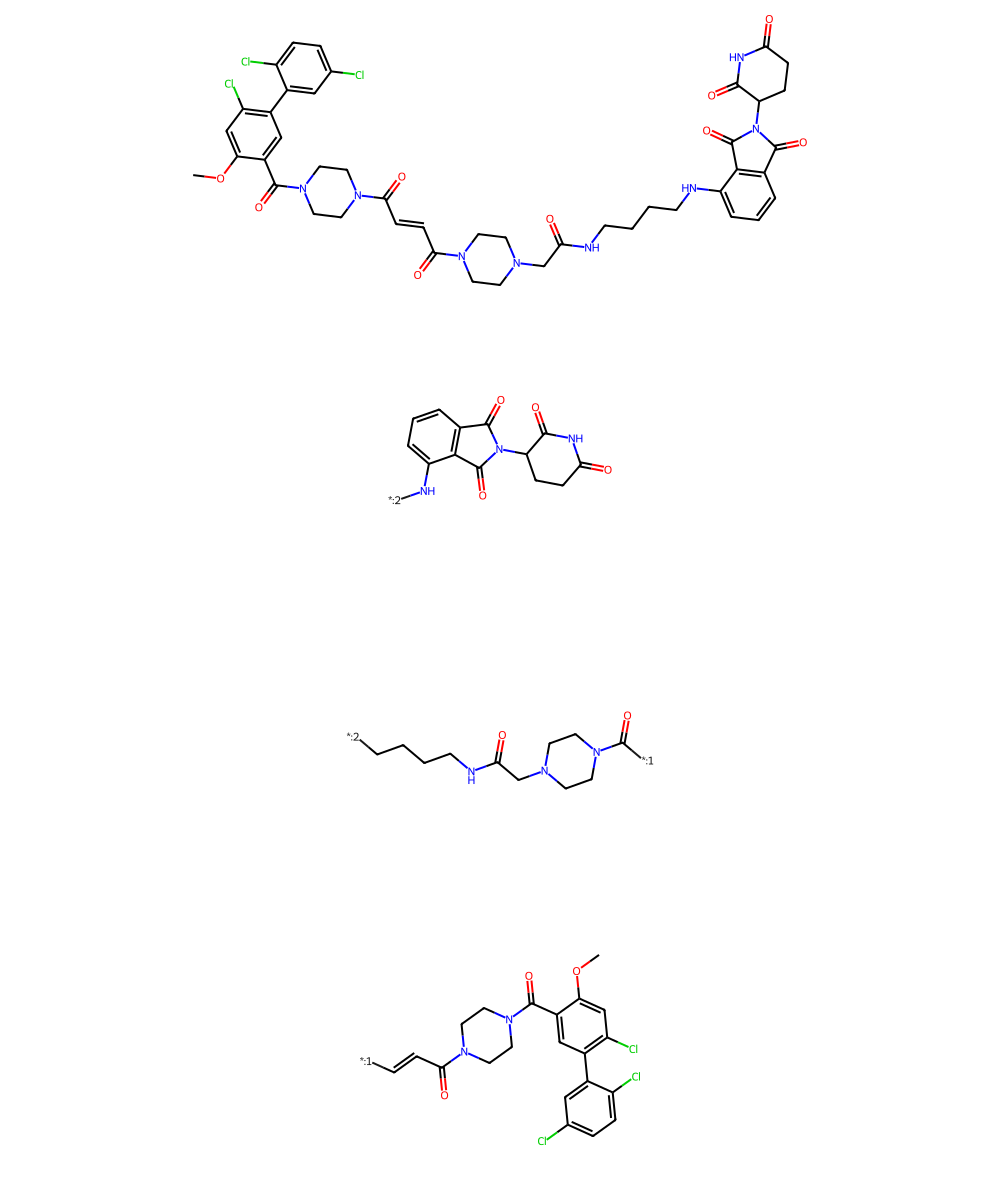

--------------------------------------------------------------------------------
PROTAC: COc1cc(Cl)c(-c2cc(Cl)ccc2Cl)cc1C(=O)N1CCN(C(=O)/C=C/C(=O)N2CCN(CC(=O)NCCCCCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)CC2)CC1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCCCNC(=O)CN1CCN(C(=O)[*:1])CC1
POI:    [*:1]/C=C/C(=O)N1CCN(C(=O)c2cc(-c3cc(Cl)ccc3Cl)c(Cl)cc2OC)CC1


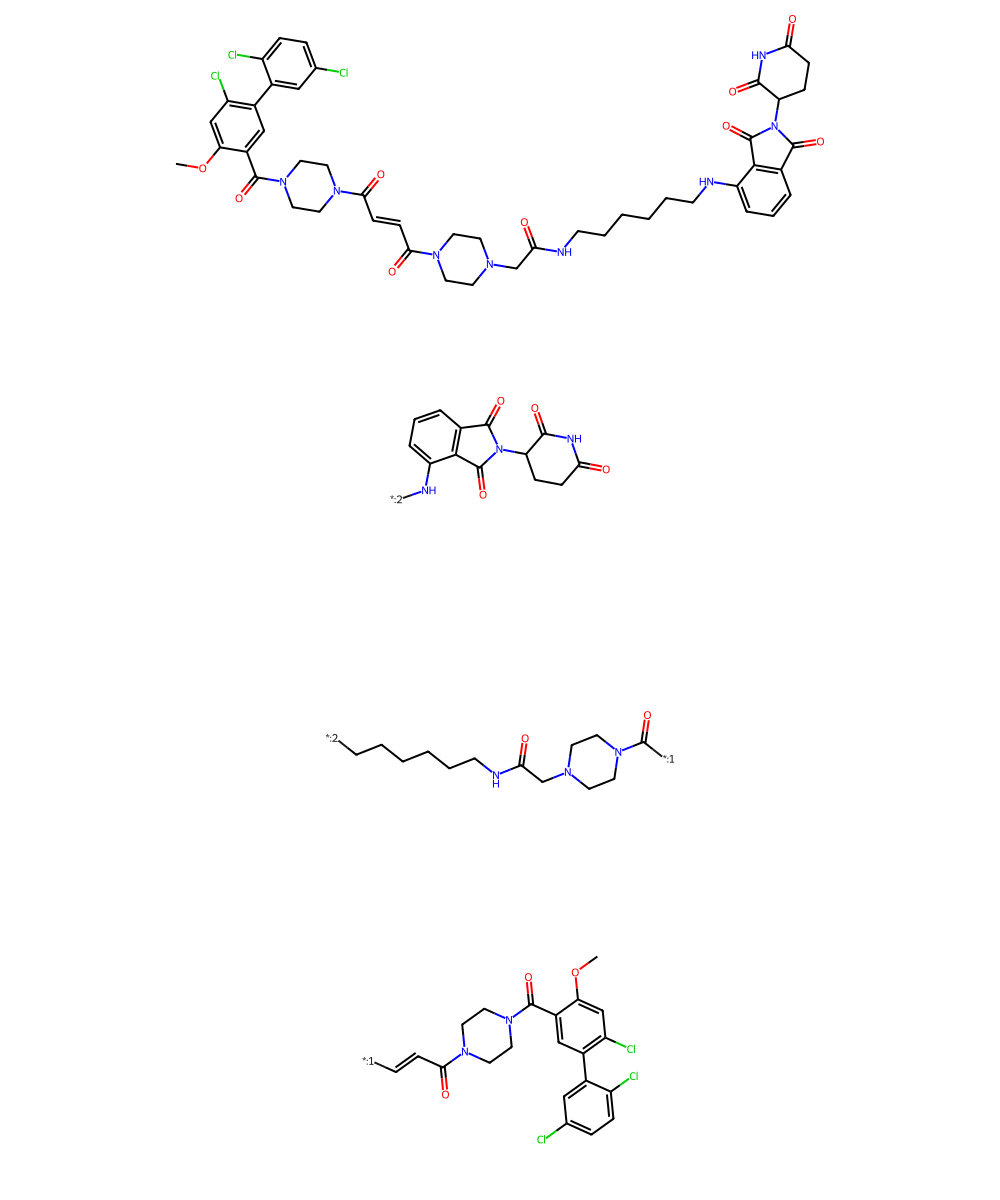

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)CCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


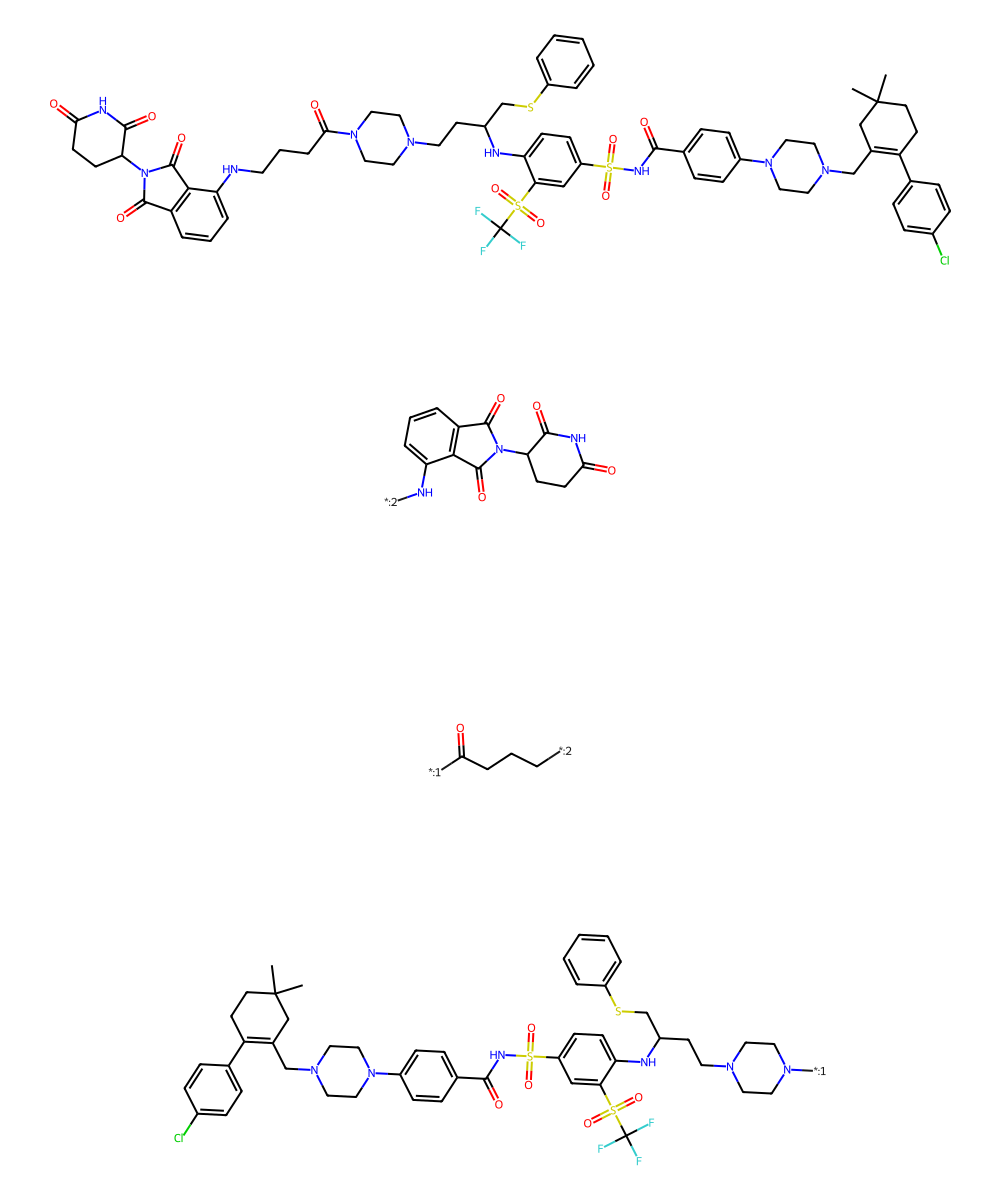

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)CCCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


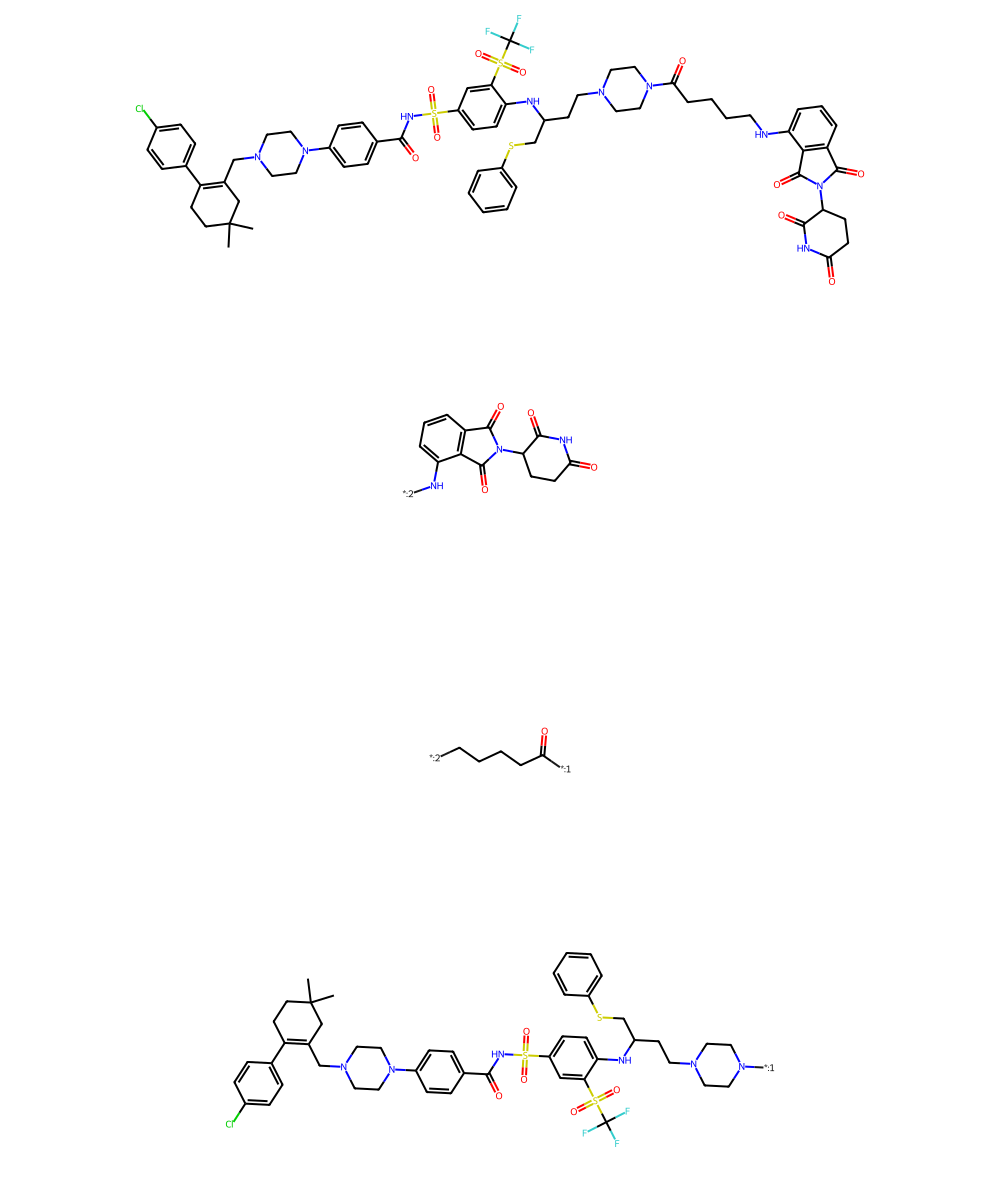

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)CCCCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCCC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


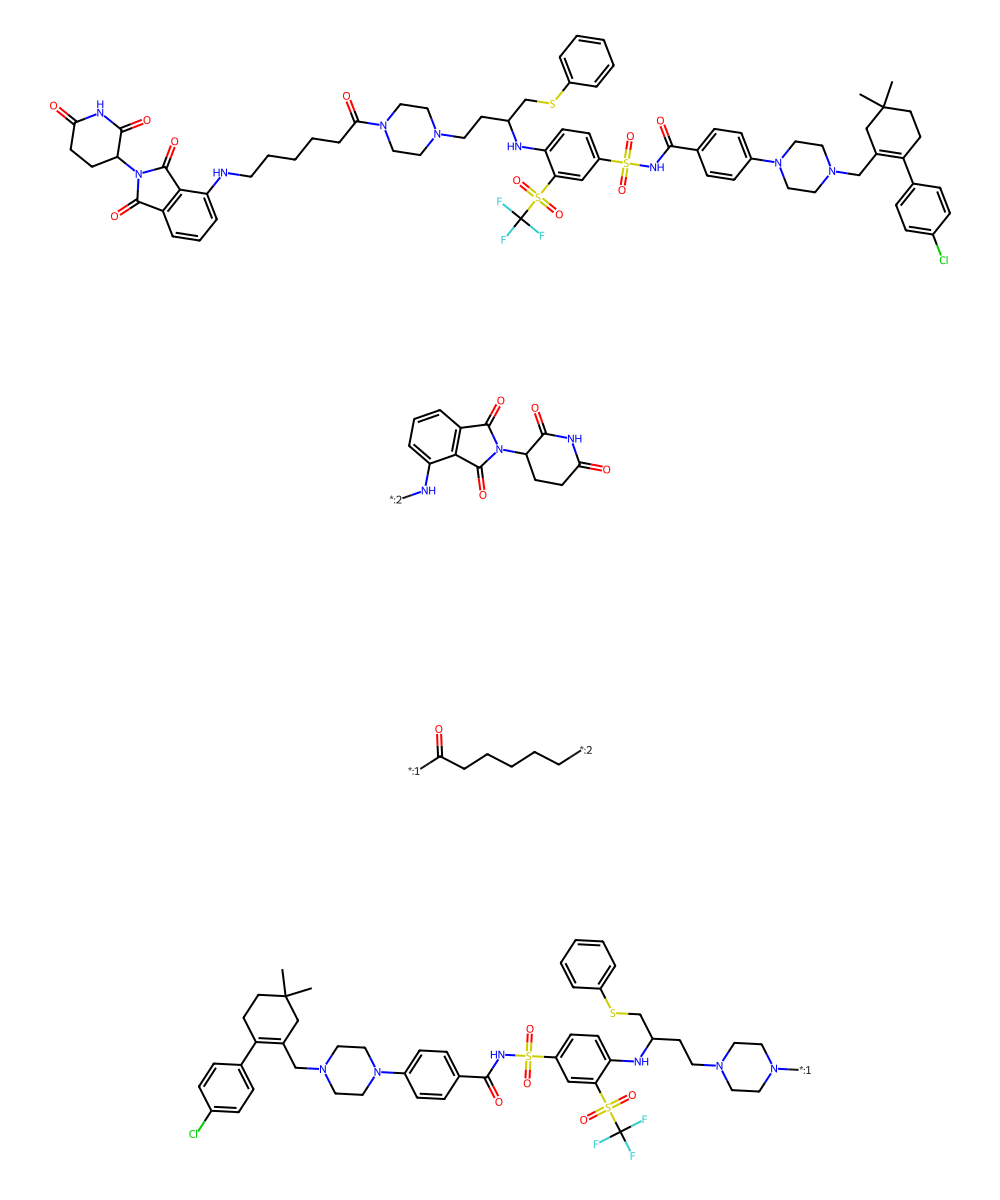

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)CCCCCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCCCC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


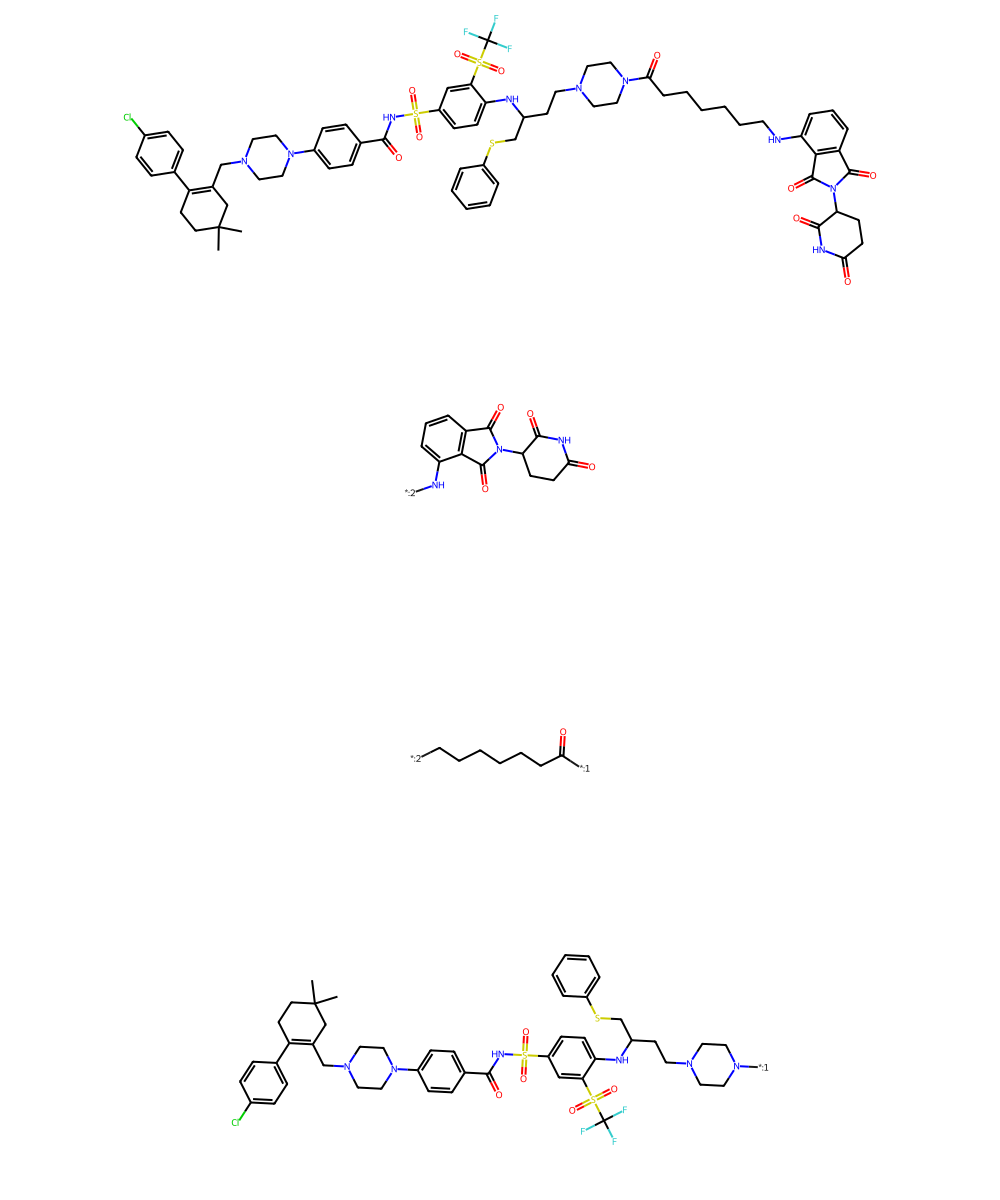

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)CCCCCCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCCCCC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


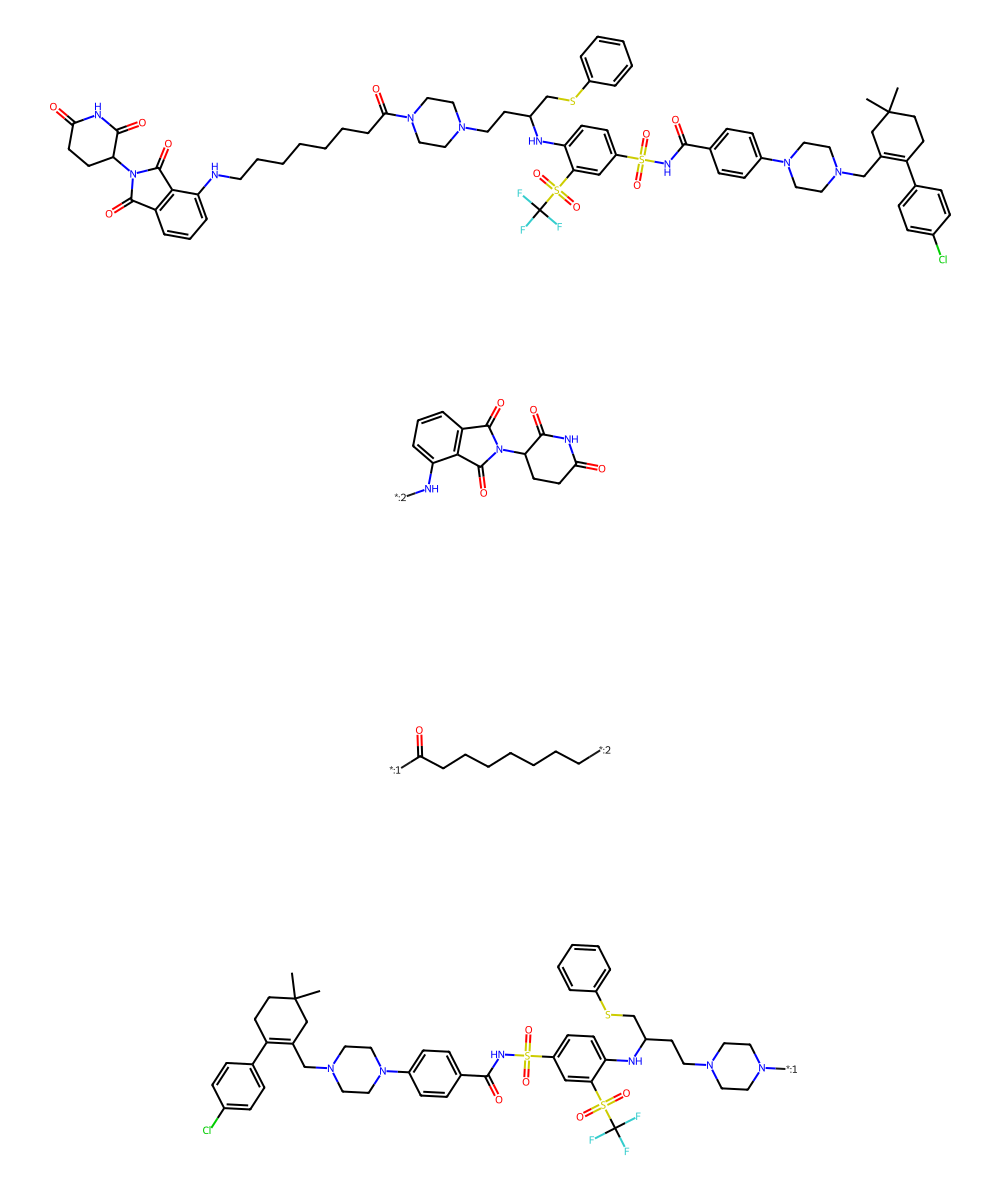

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(CCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCC[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


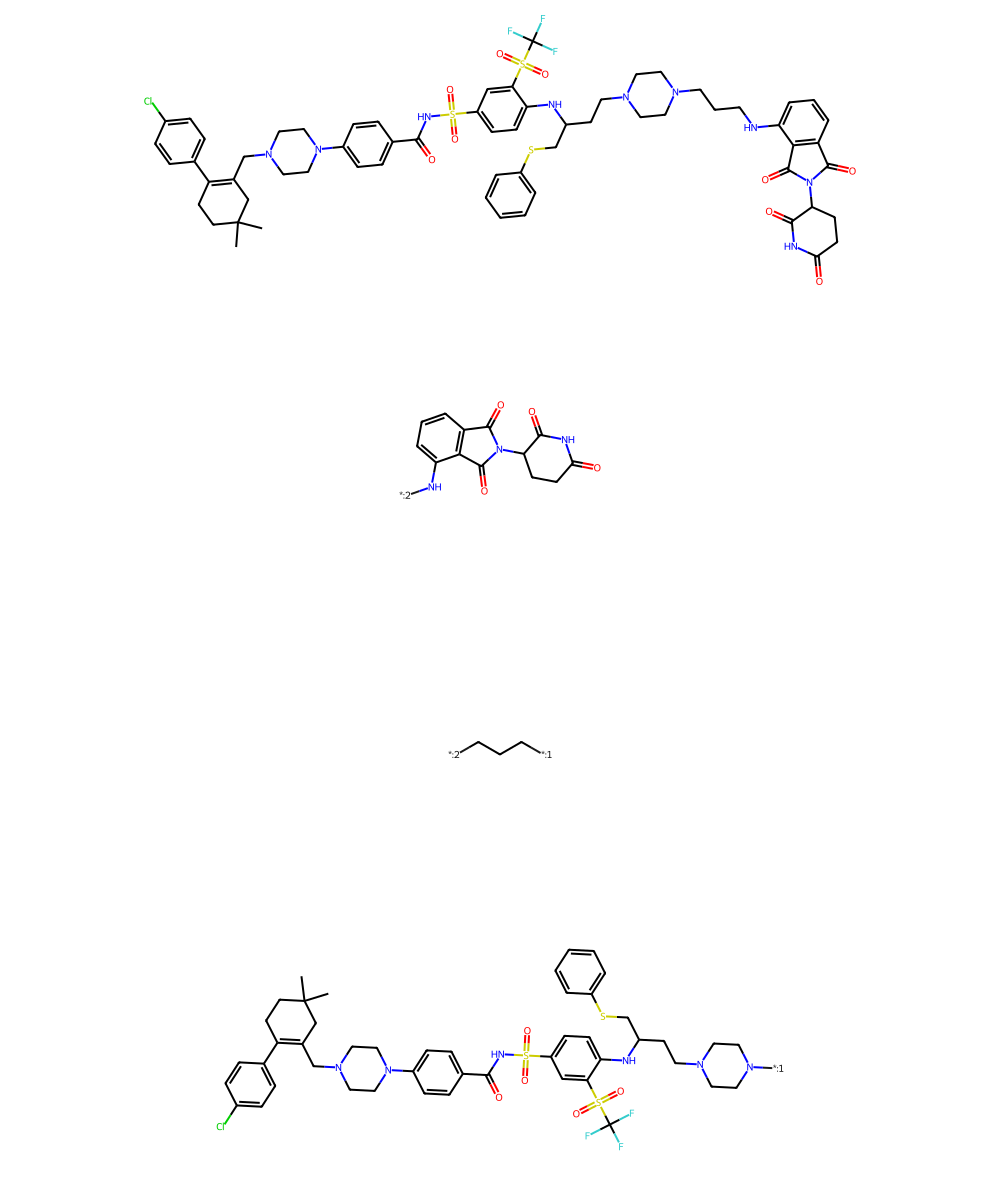

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(CCCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCC[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


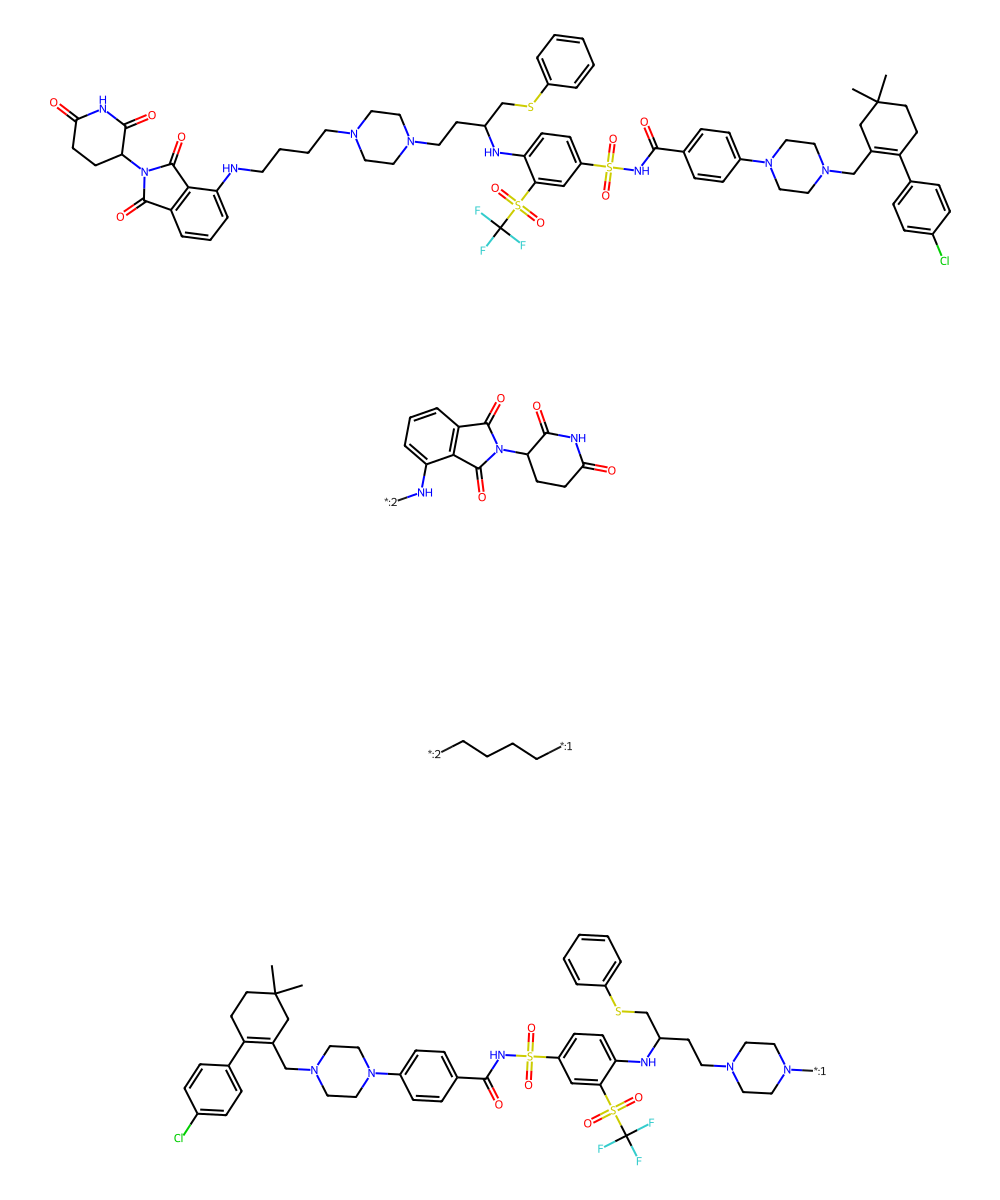

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(CCCCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCC[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


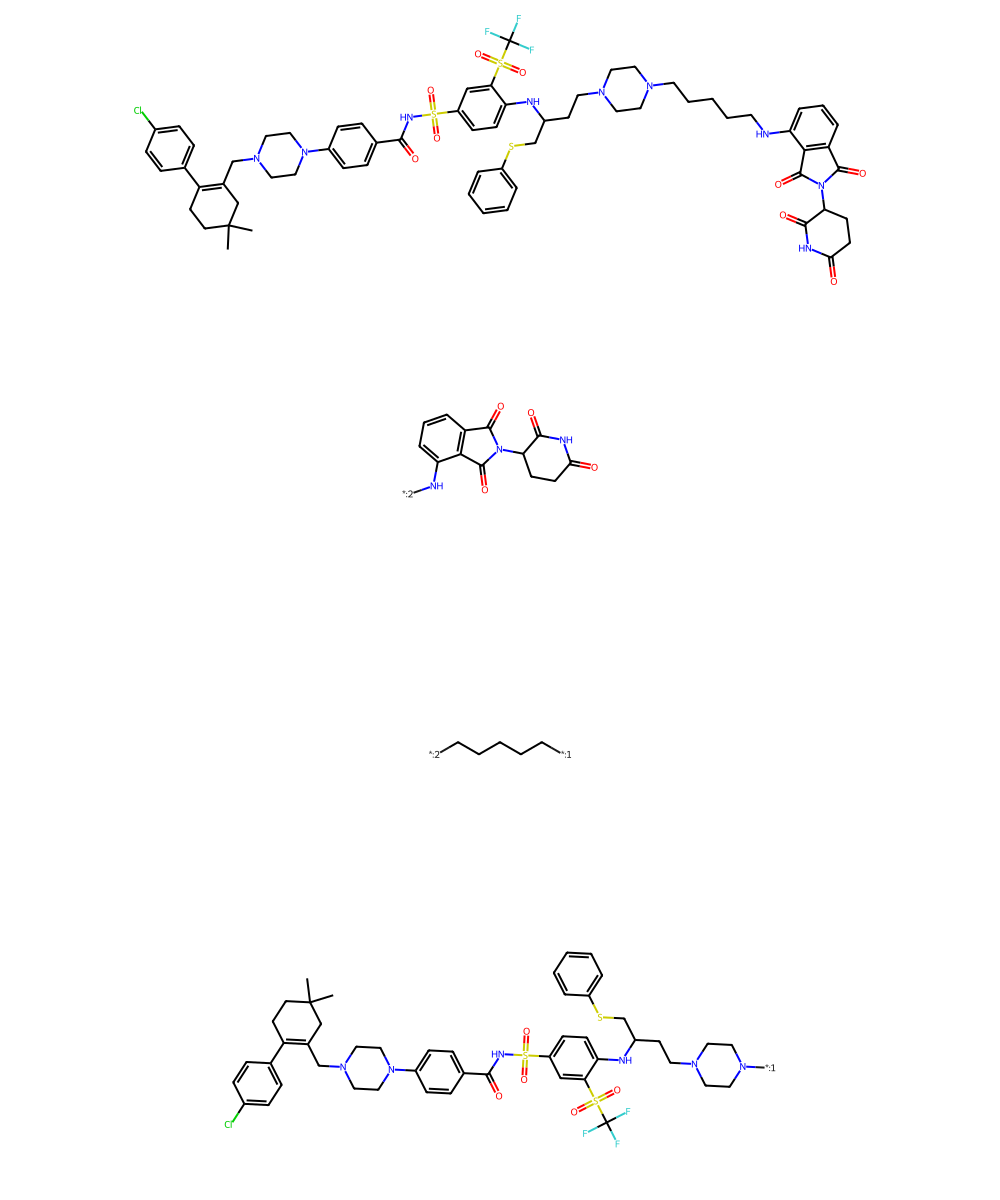

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)COCCOCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


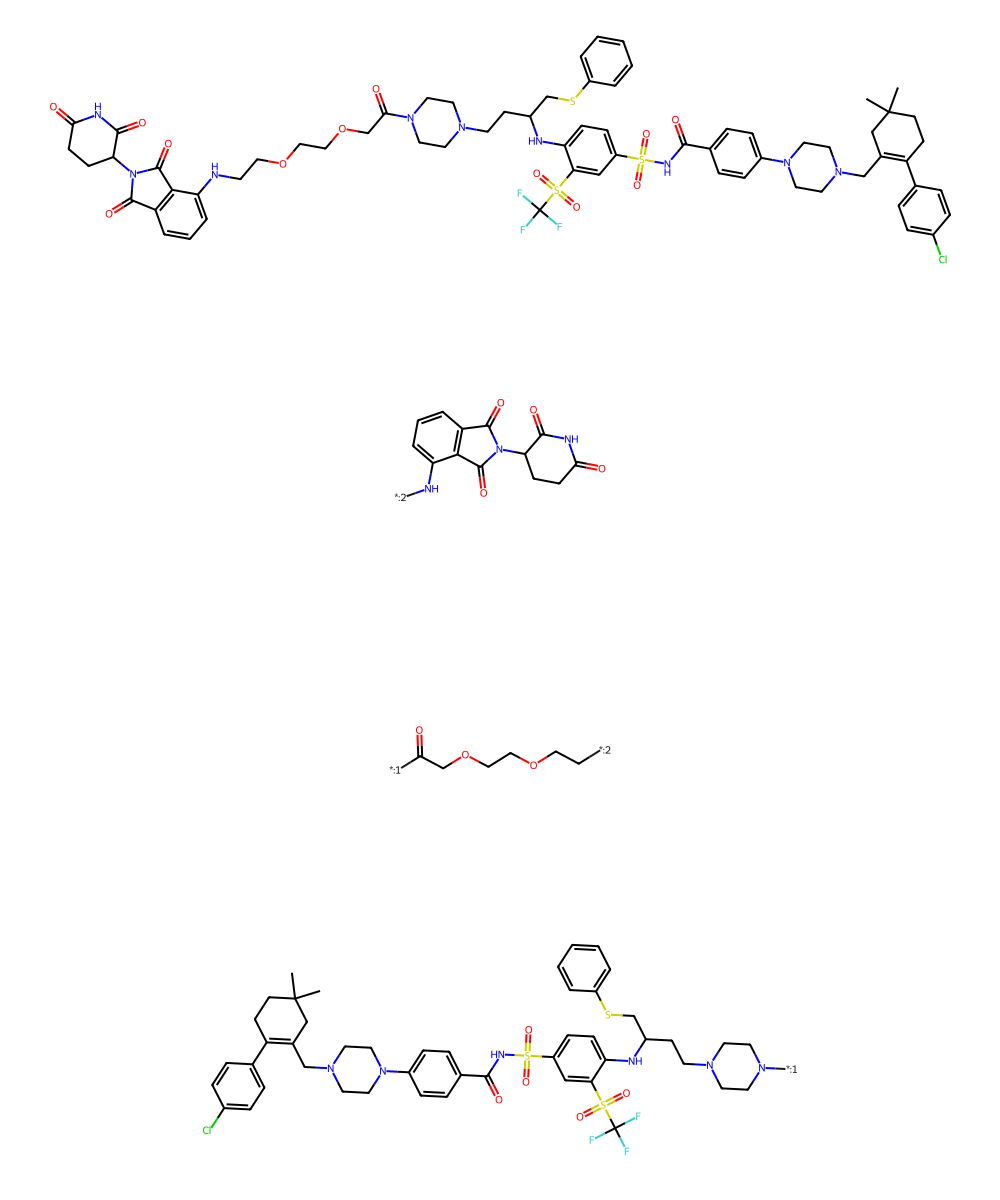

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)COCCOCCOCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCCOCC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


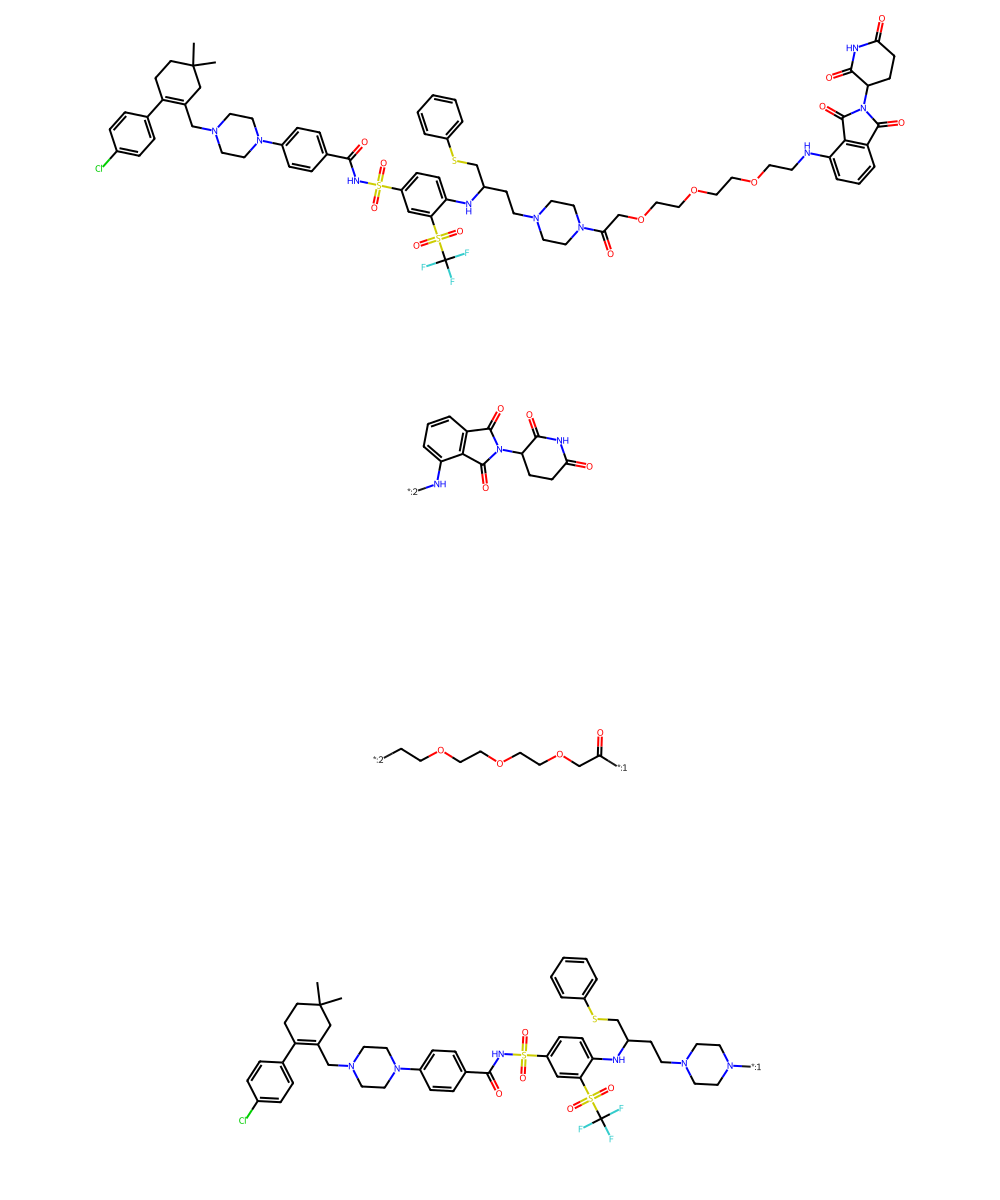

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)COCCOCCOCCOCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCCOCCOCC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


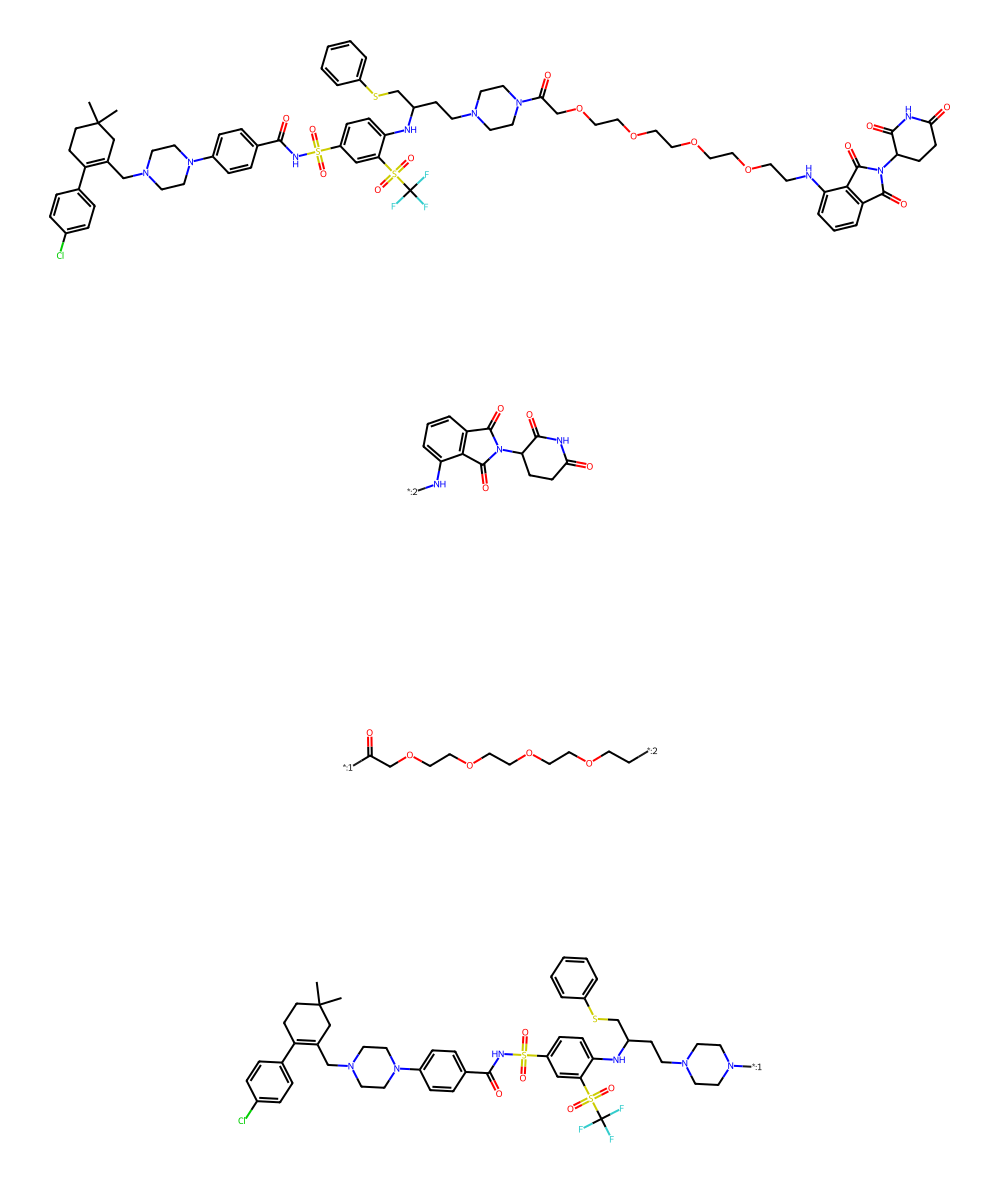

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)NCCOCCOCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCCNC(=O)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


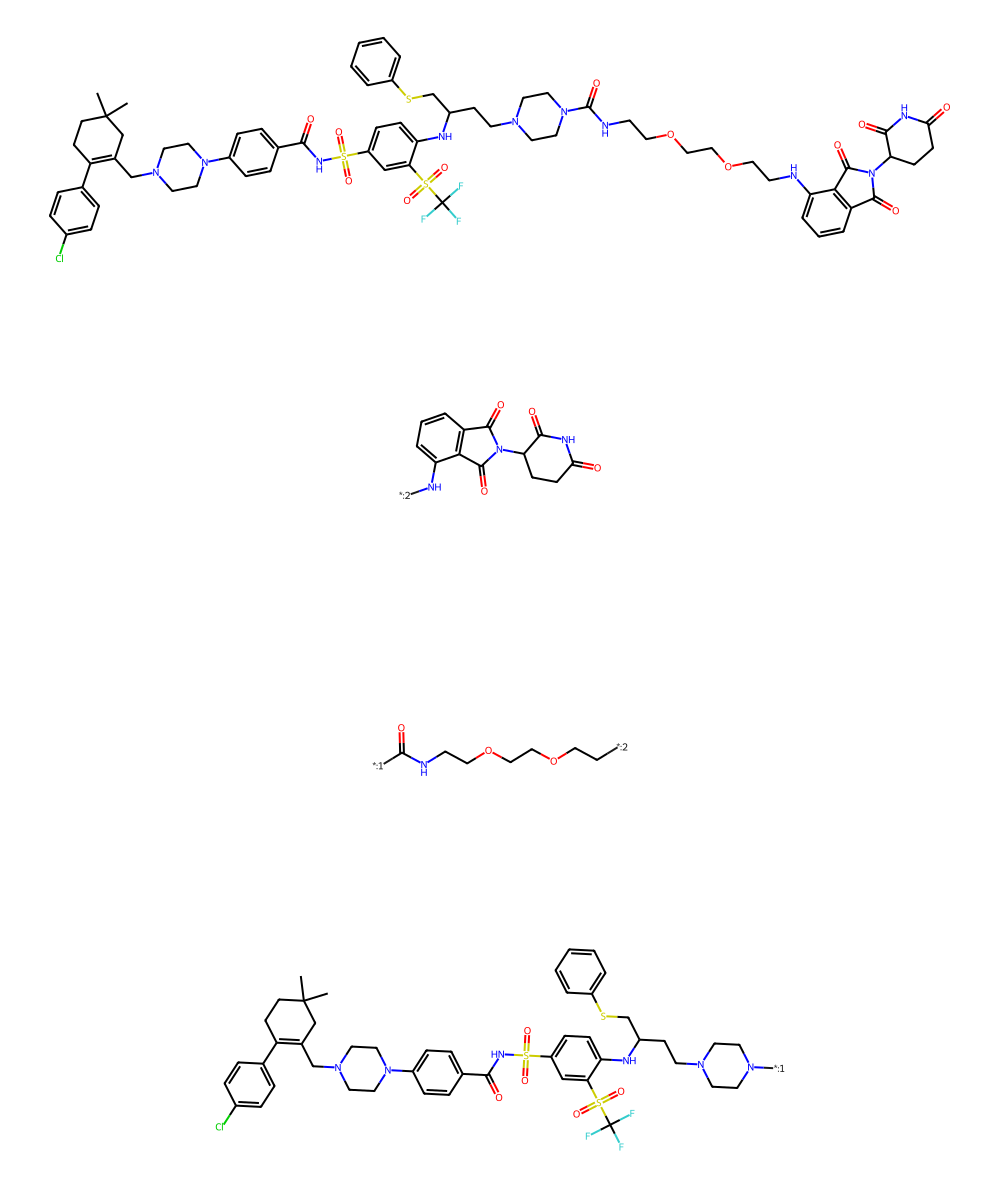

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=S)NCCOCCOCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCCNC(=S)[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


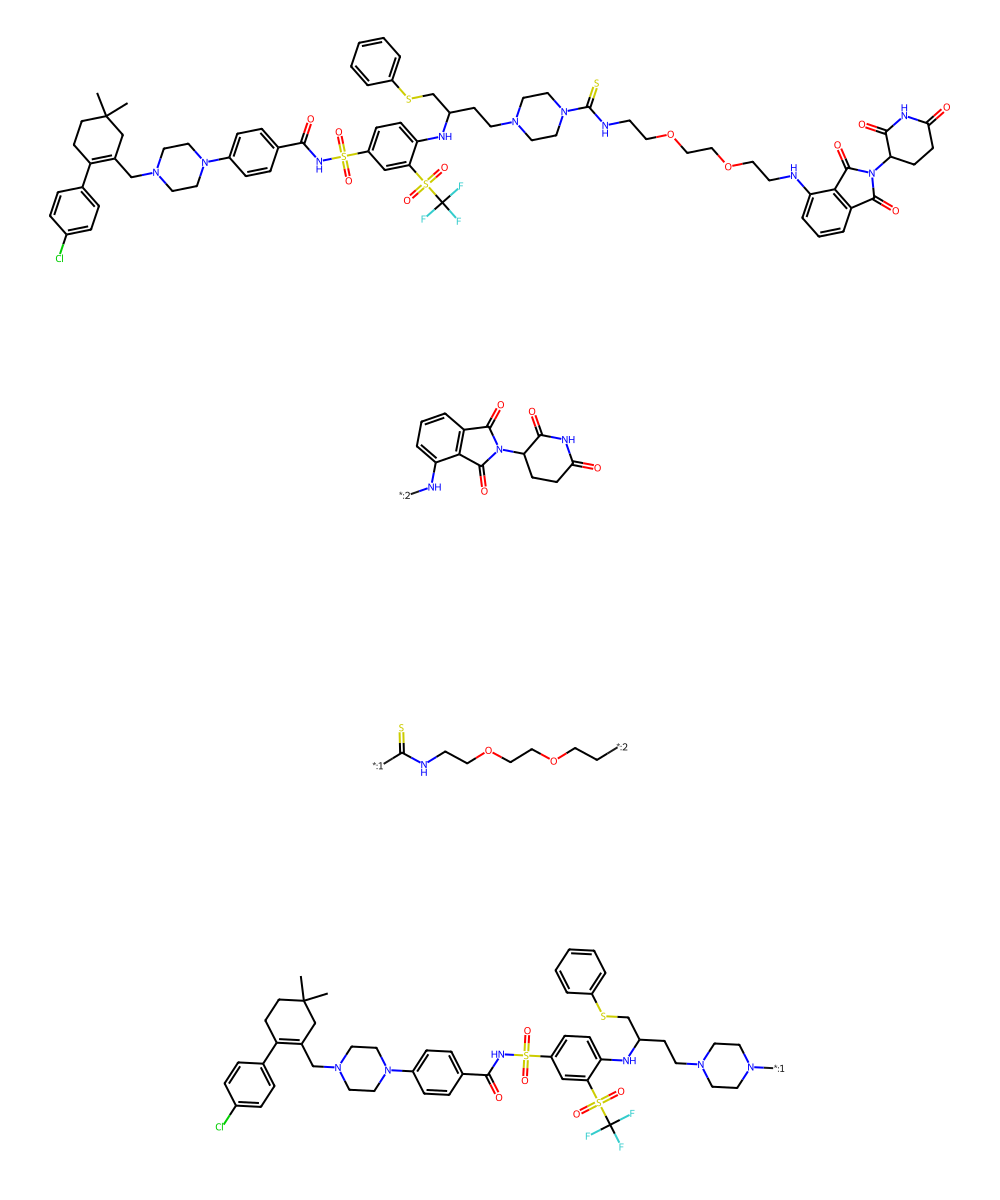

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(CCOCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCC[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


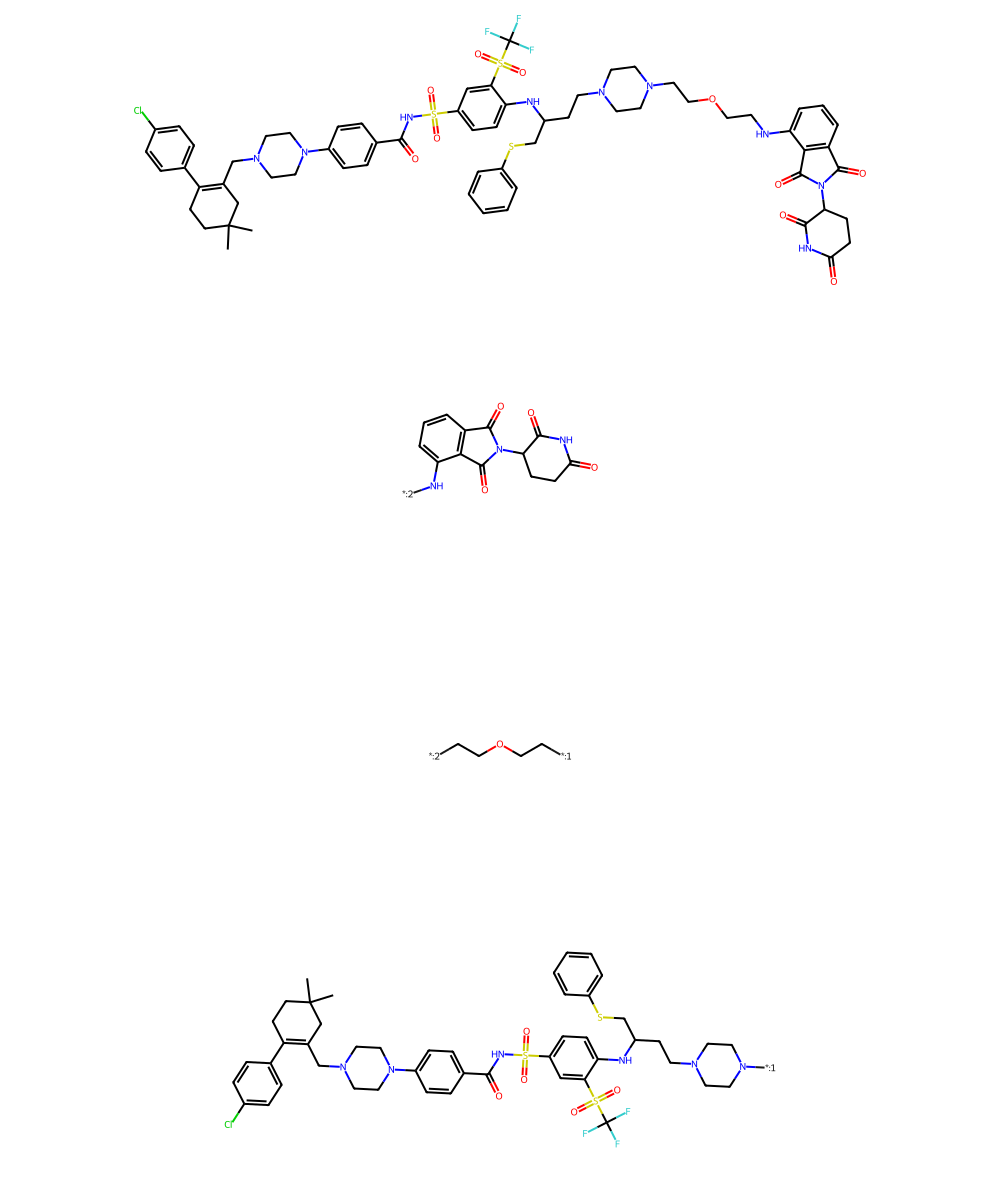

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(CCOCCOCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCC[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


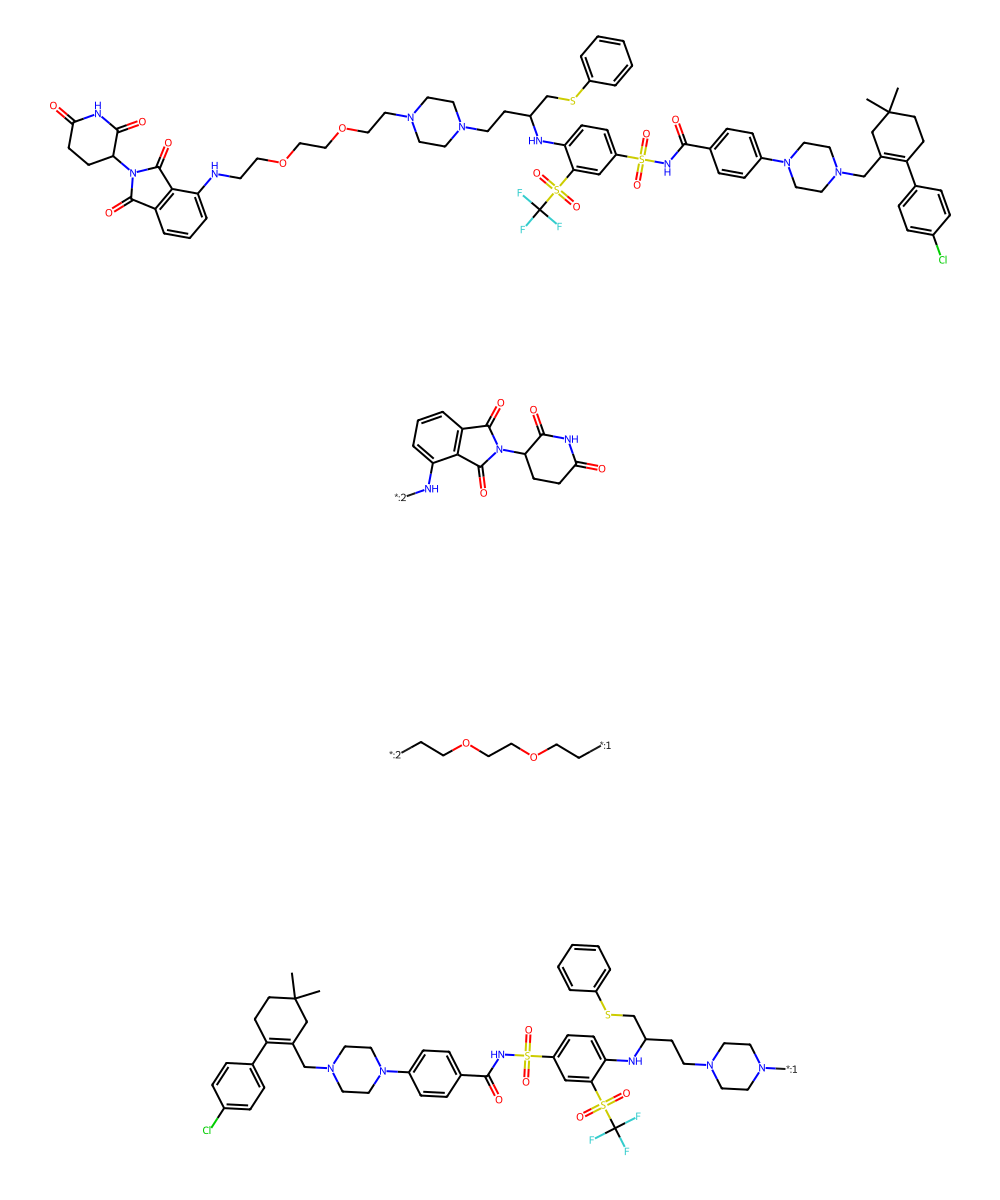

--------------------------------------------------------------------------------
PROTAC: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(CCOCCOCCOCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCCOCC[*:1]
POI:    [*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)CC1


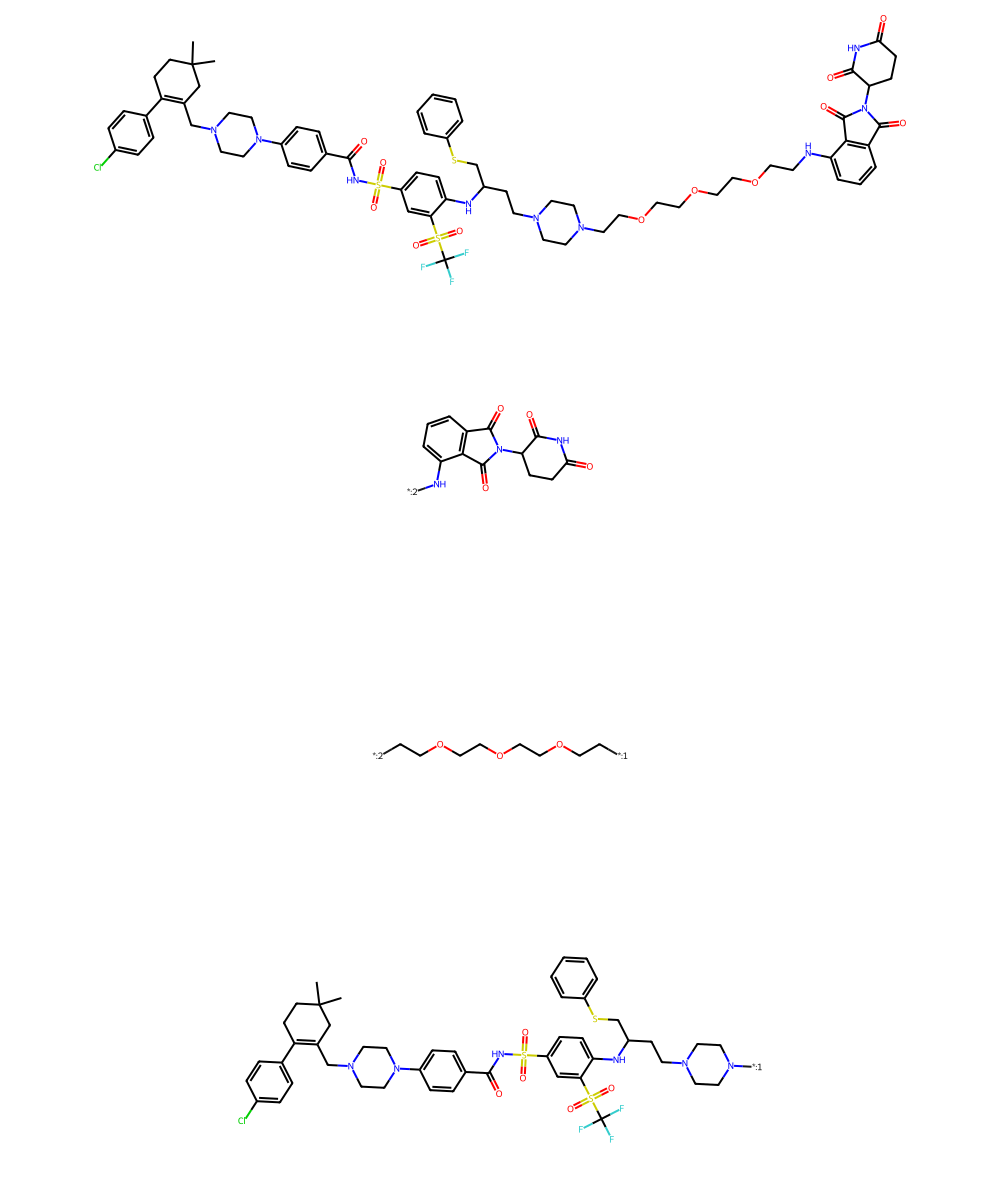

--------------------------------------------------------------------------------
PROTAC: CN(CCCCCCCn1cc(COCCOCCNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)nn1)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCc1cn(CCCCCC[*:1])nn1
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


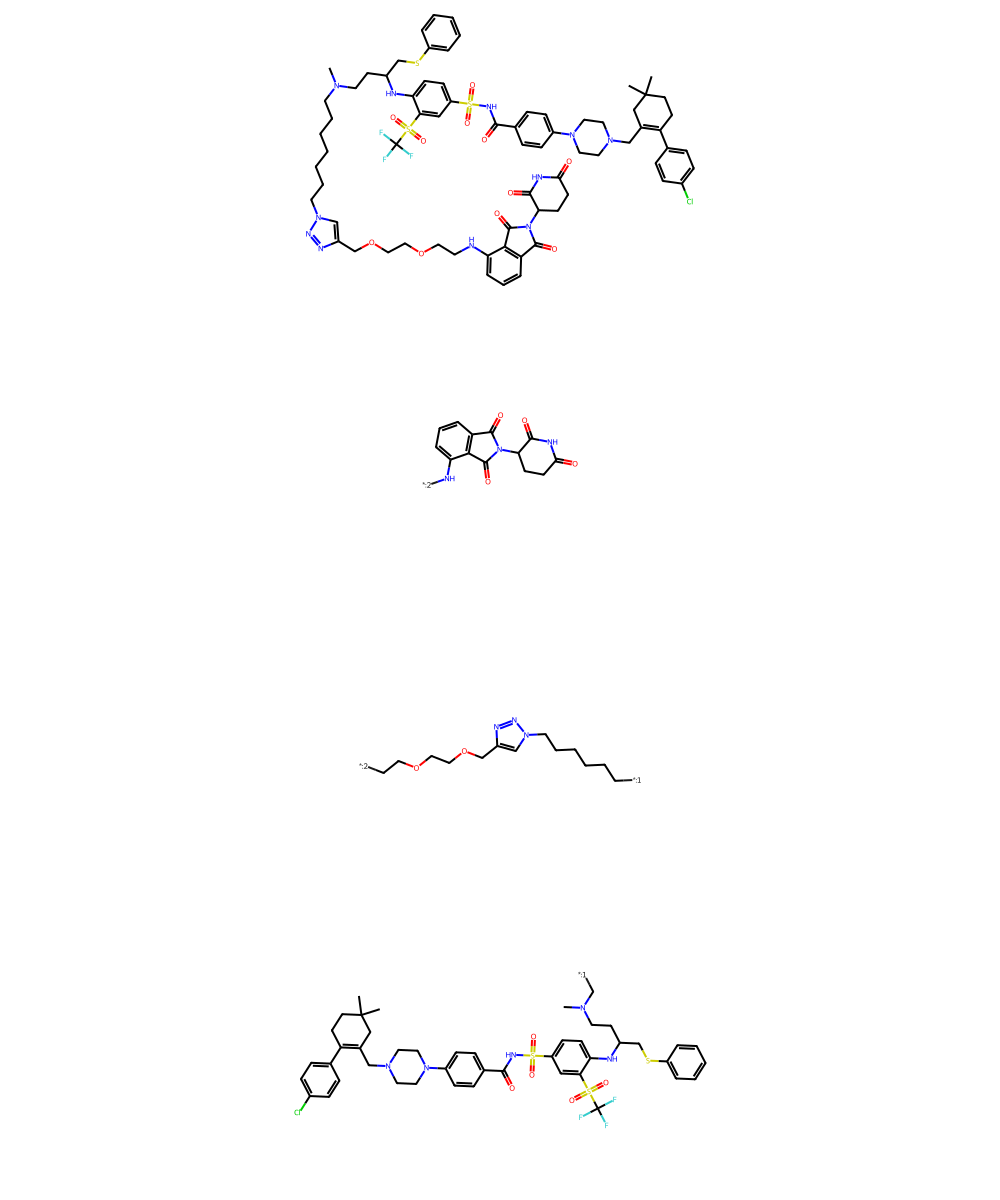

--------------------------------------------------------------------------------
PROTAC: CN(CCCCCCCn1cc(COCCOCCOCCNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)nn1)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCCOCc1cn(CCCCCC[*:1])nn1
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


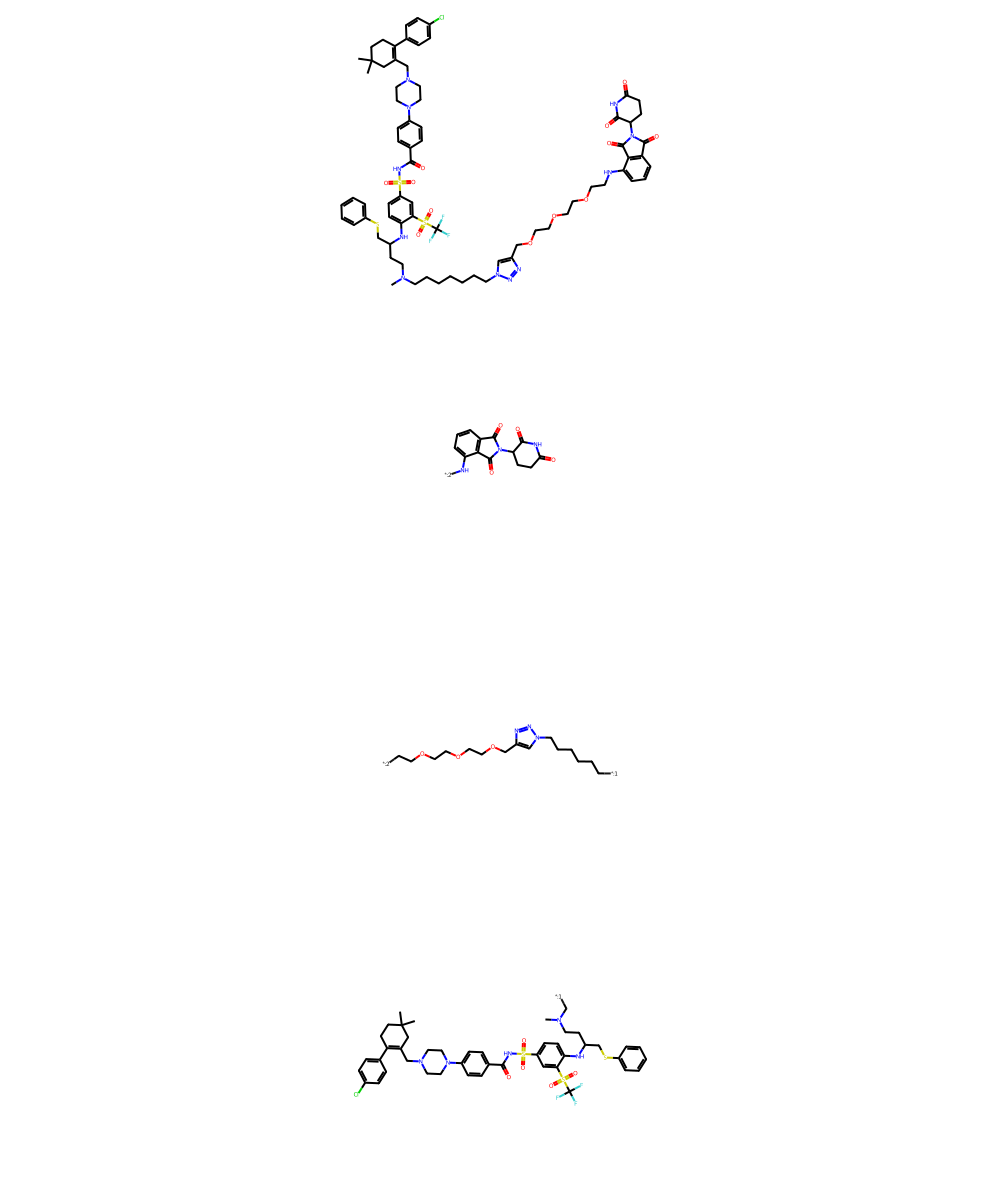

--------------------------------------------------------------------------------
PROTAC: CN(CCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CC[*:1]
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


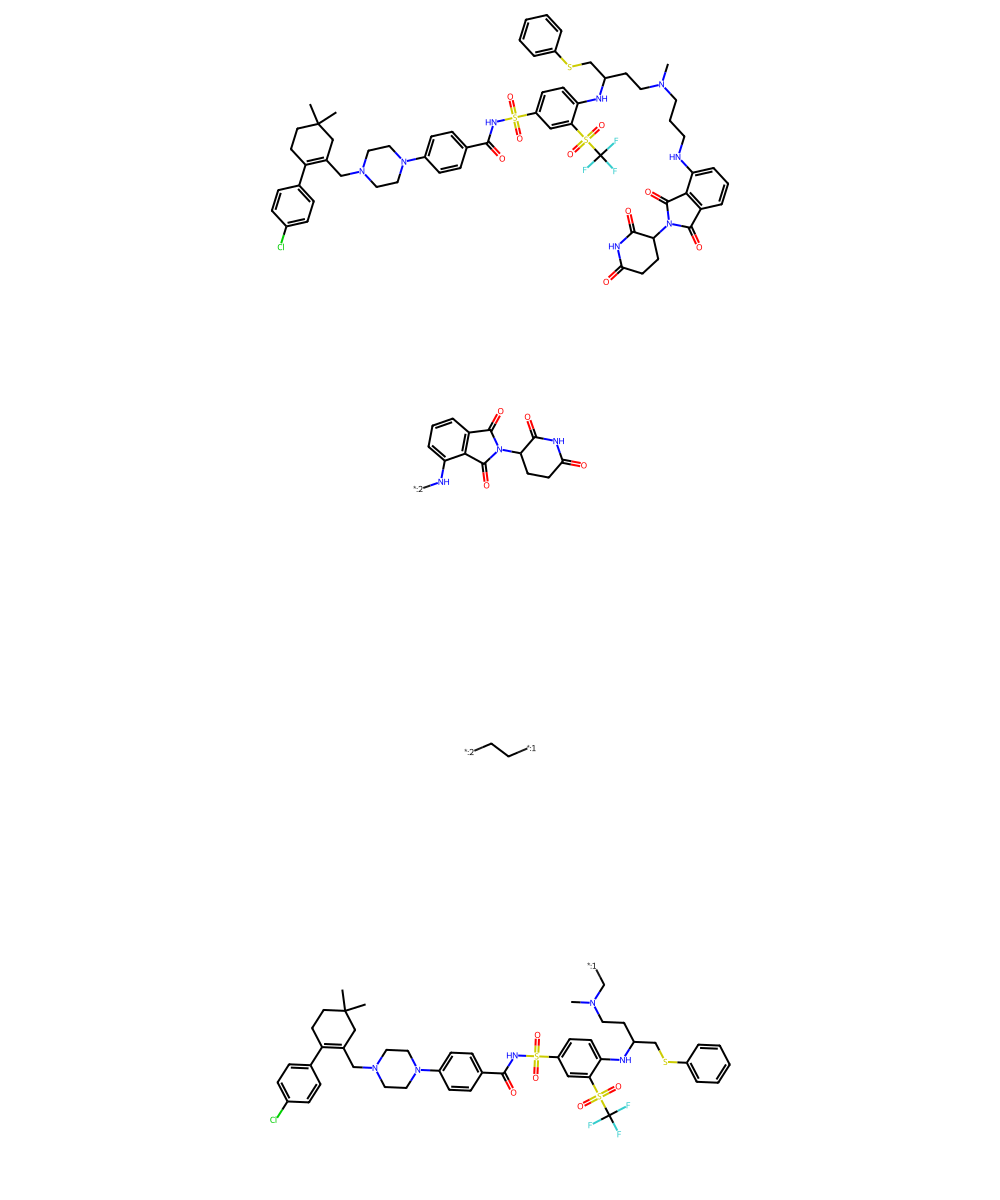

--------------------------------------------------------------------------------
PROTAC: CN(CCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCC[*:1]
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


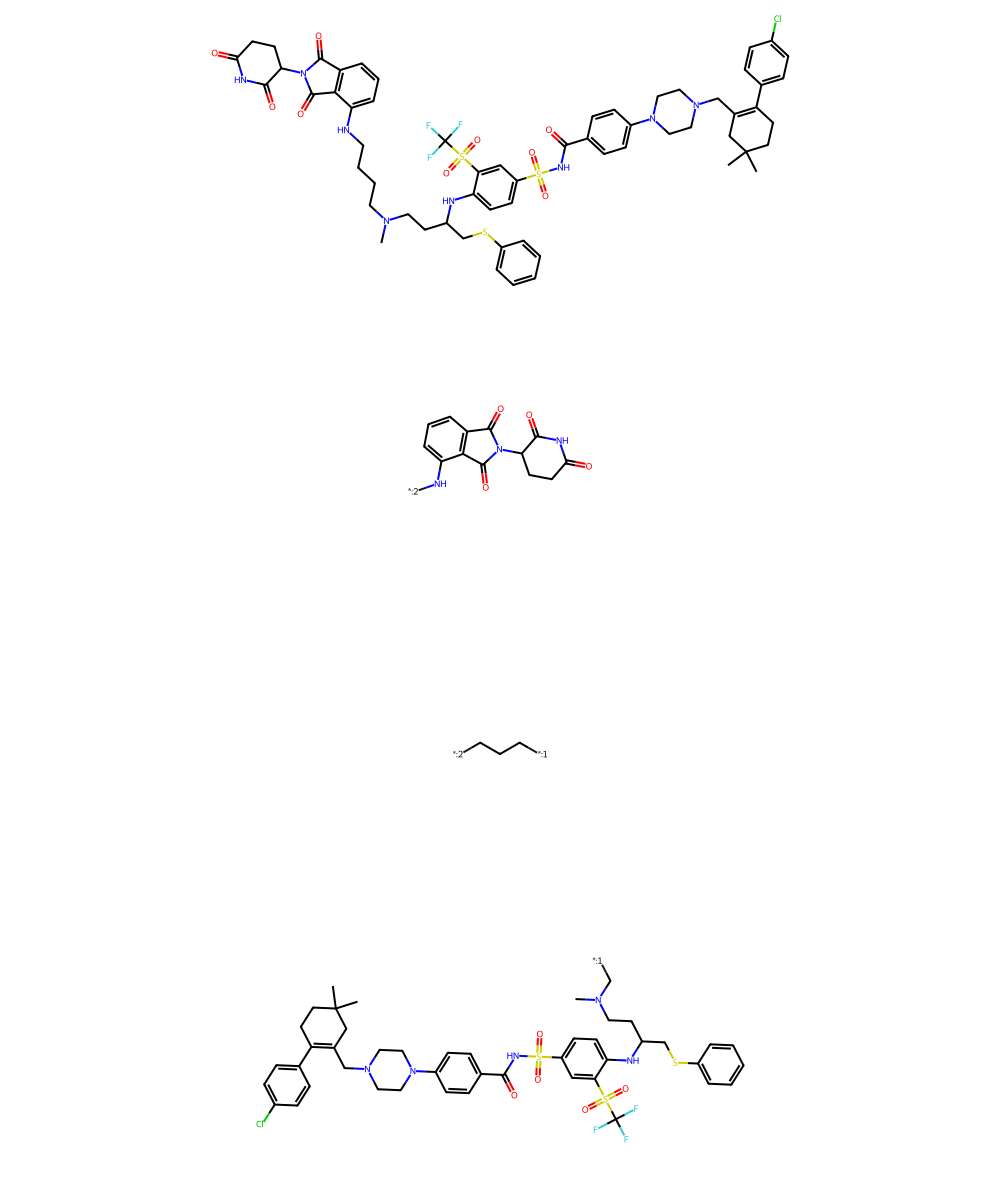

--------------------------------------------------------------------------------
PROTAC: CN(CCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCC[*:1]
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


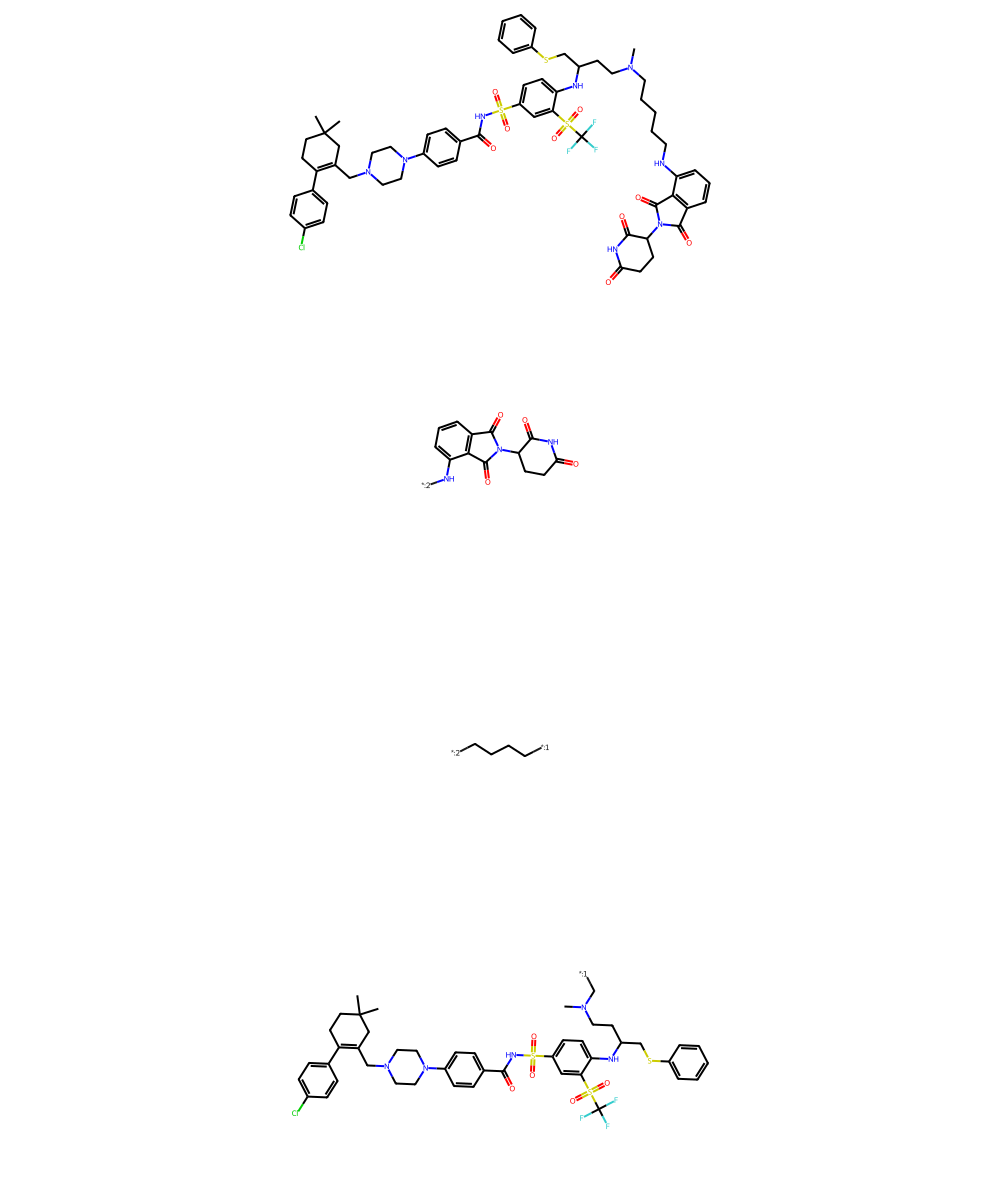

--------------------------------------------------------------------------------
PROTAC: CN(CCCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCC[*:1]
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


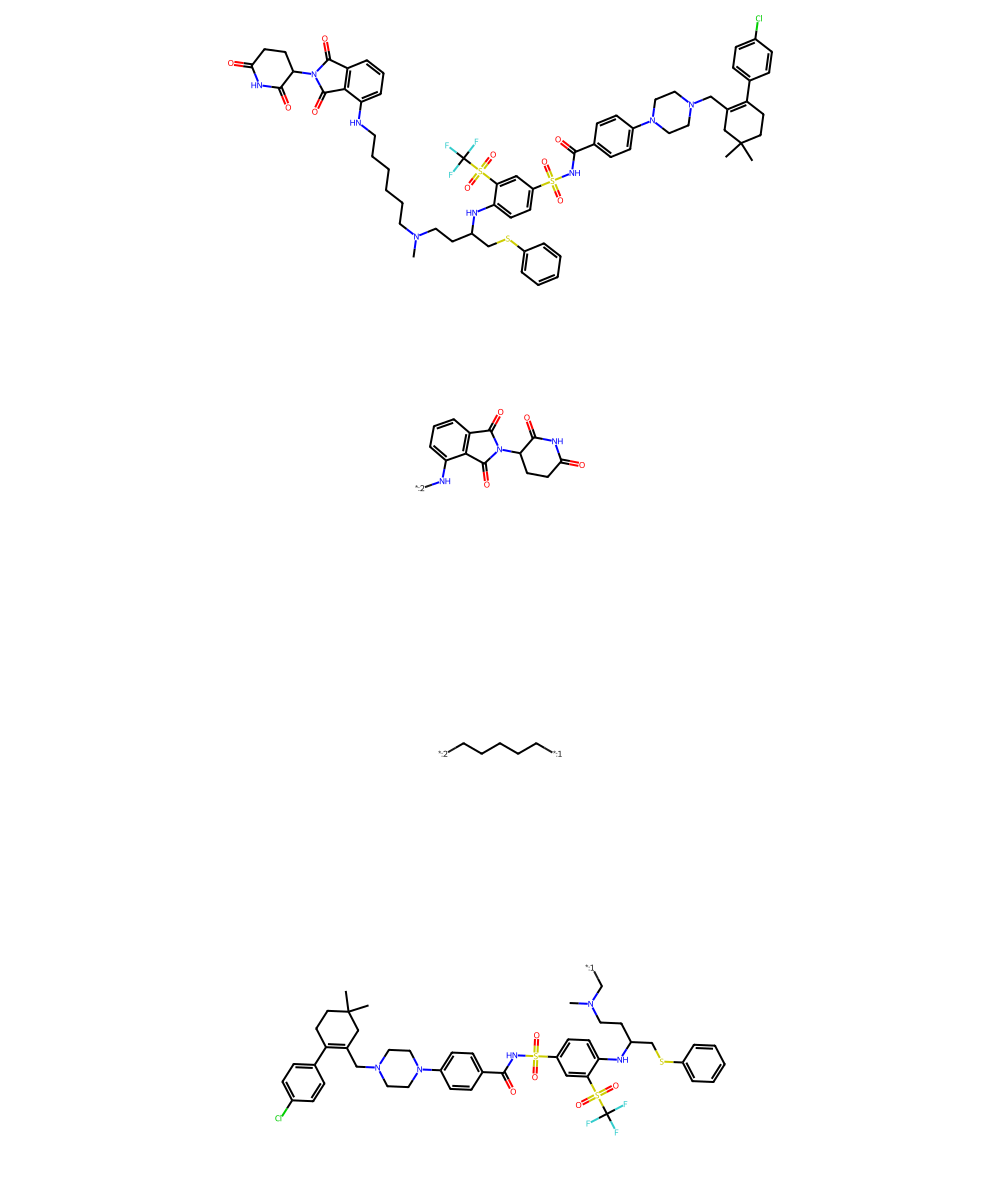

--------------------------------------------------------------------------------
PROTAC: CN(CCCCCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCCCCCC[*:1]
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


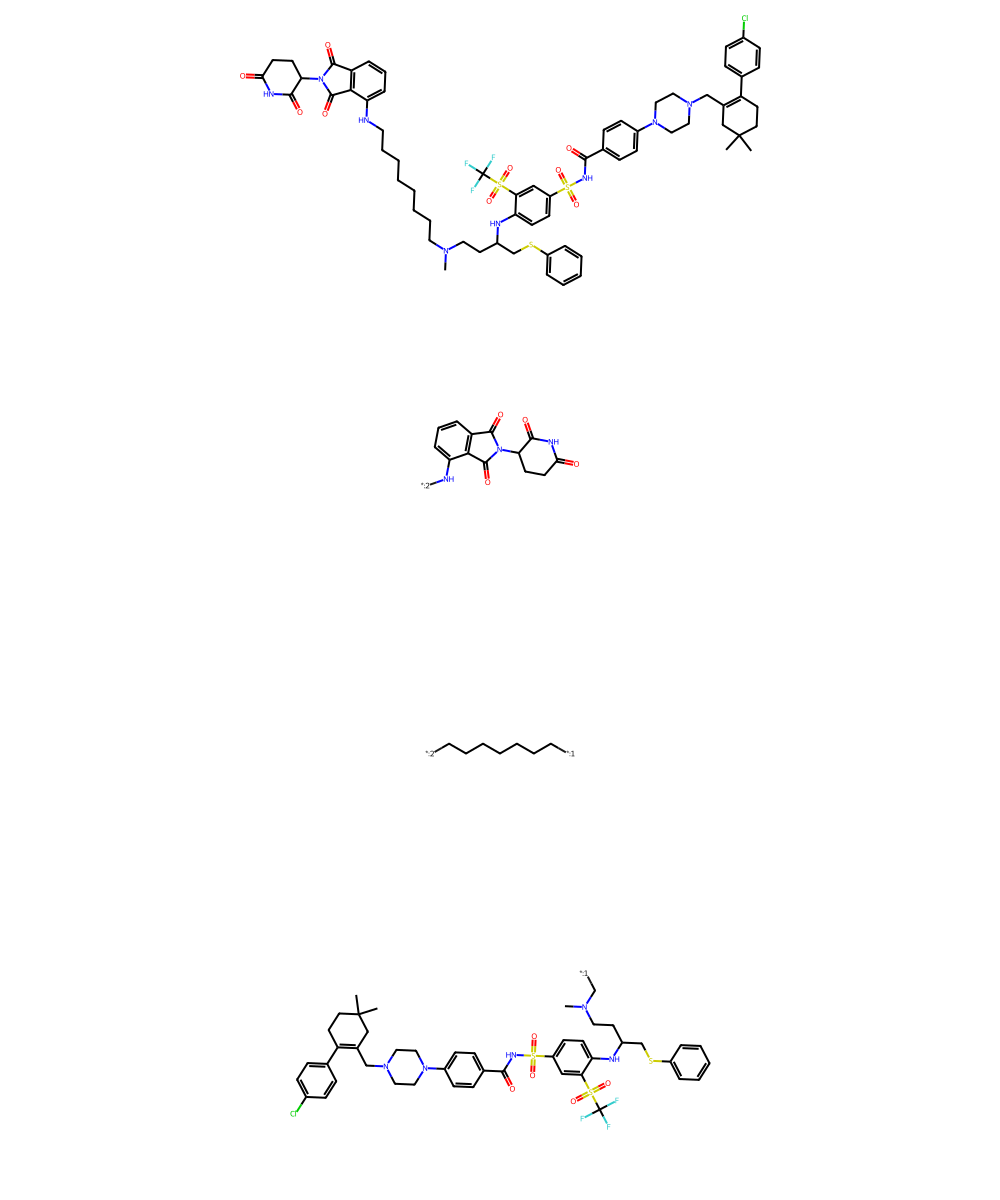

--------------------------------------------------------------------------------
PROTAC: CN(CCOCCOCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOC[*:1]
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


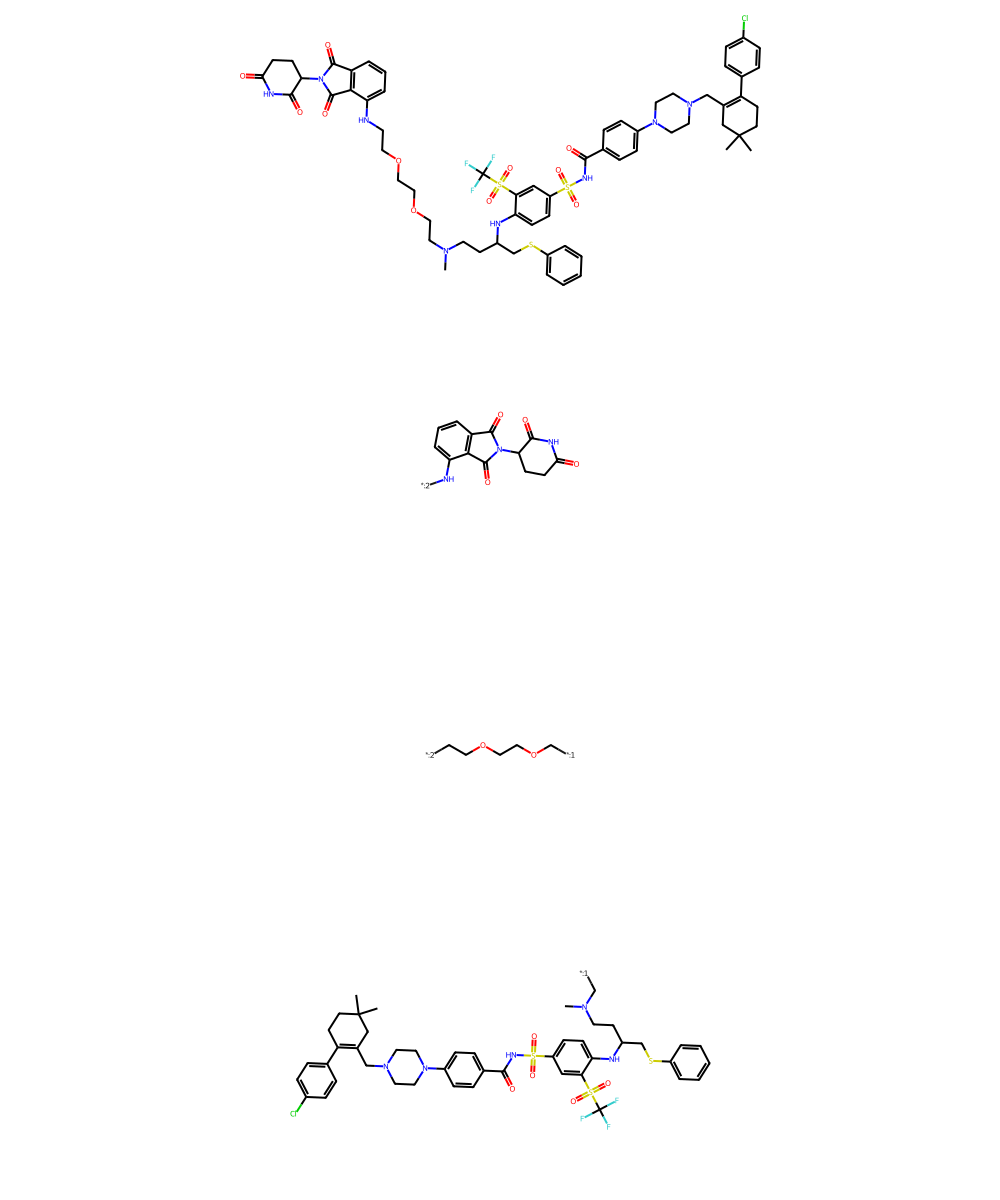

--------------------------------------------------------------------------------
PROTAC: CN(CCOCCOCCOCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCCOC[*:1]
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


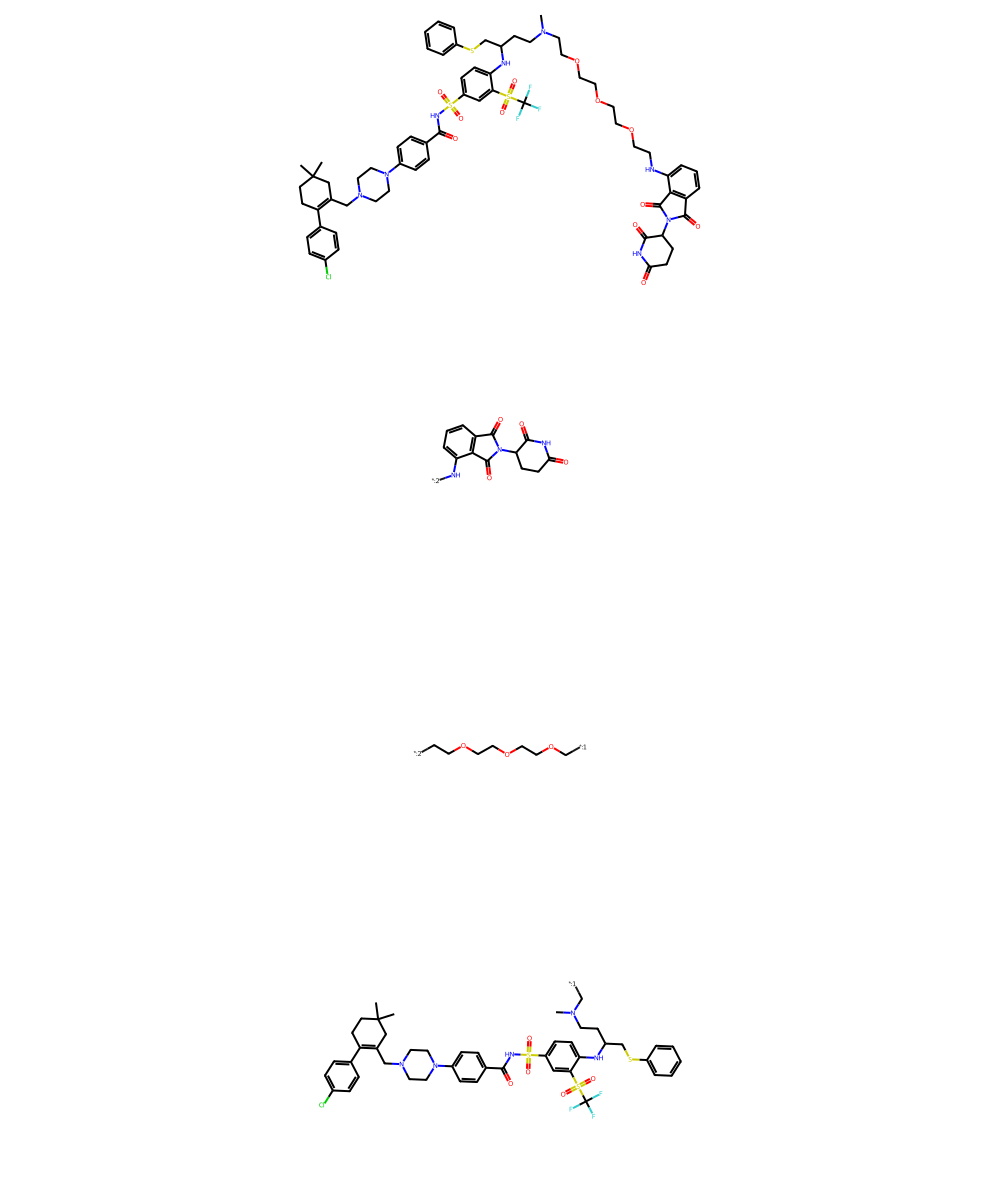

--------------------------------------------------------------------------------
PROTAC: CN(CCOCCOCCOCCOCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]CCOCCOCCOCCOC[*:1]
POI:    [*:1]CN(C)CCC(CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc(Cl)cc5)CCC(C)(C)C4)CC3)cc2)cc1S(=O)(=O)C(F)(F)F


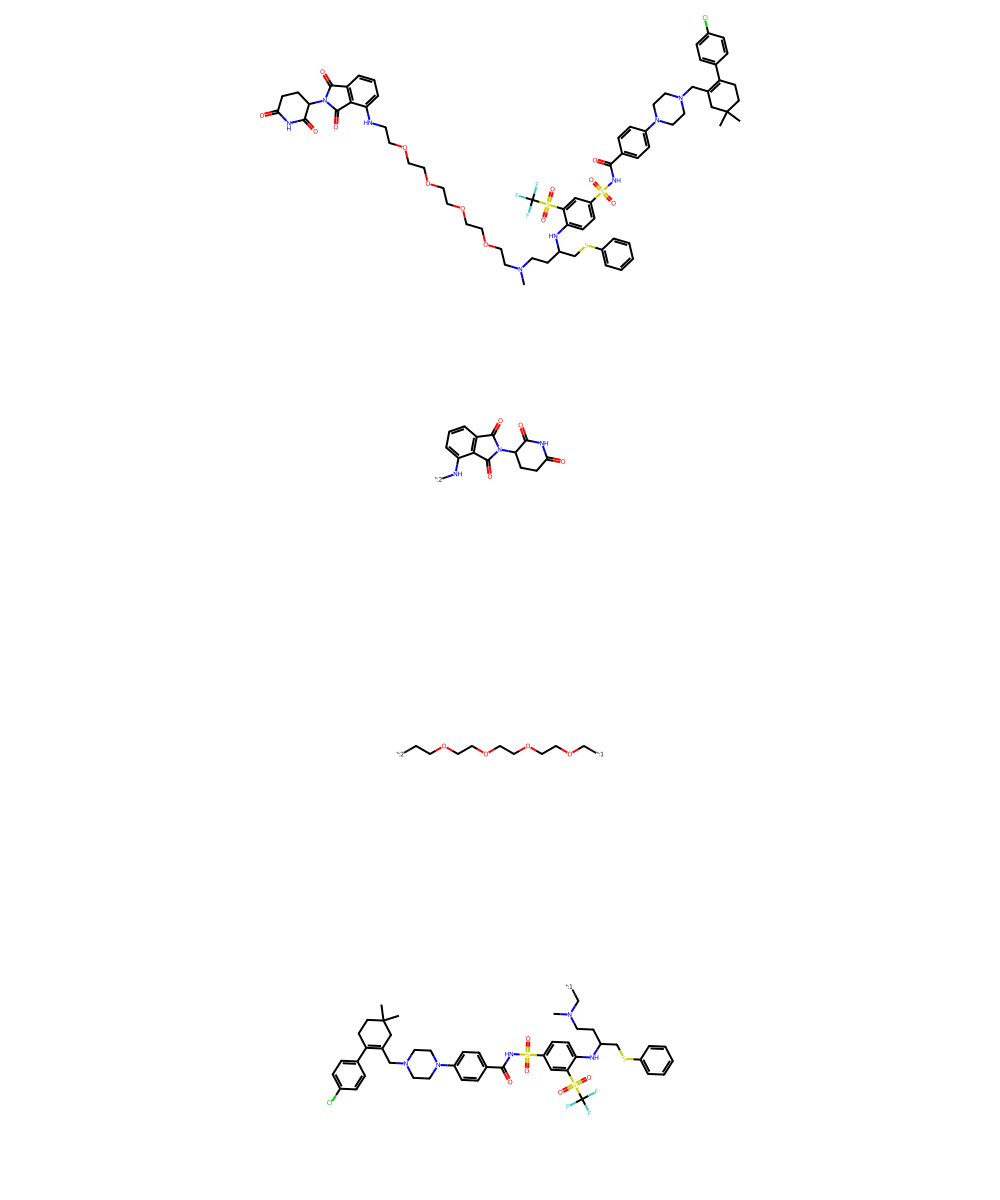

--------------------------------------------------------------------------------
PROTAC: C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCCCCCC[*:1]
POI:    [*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1


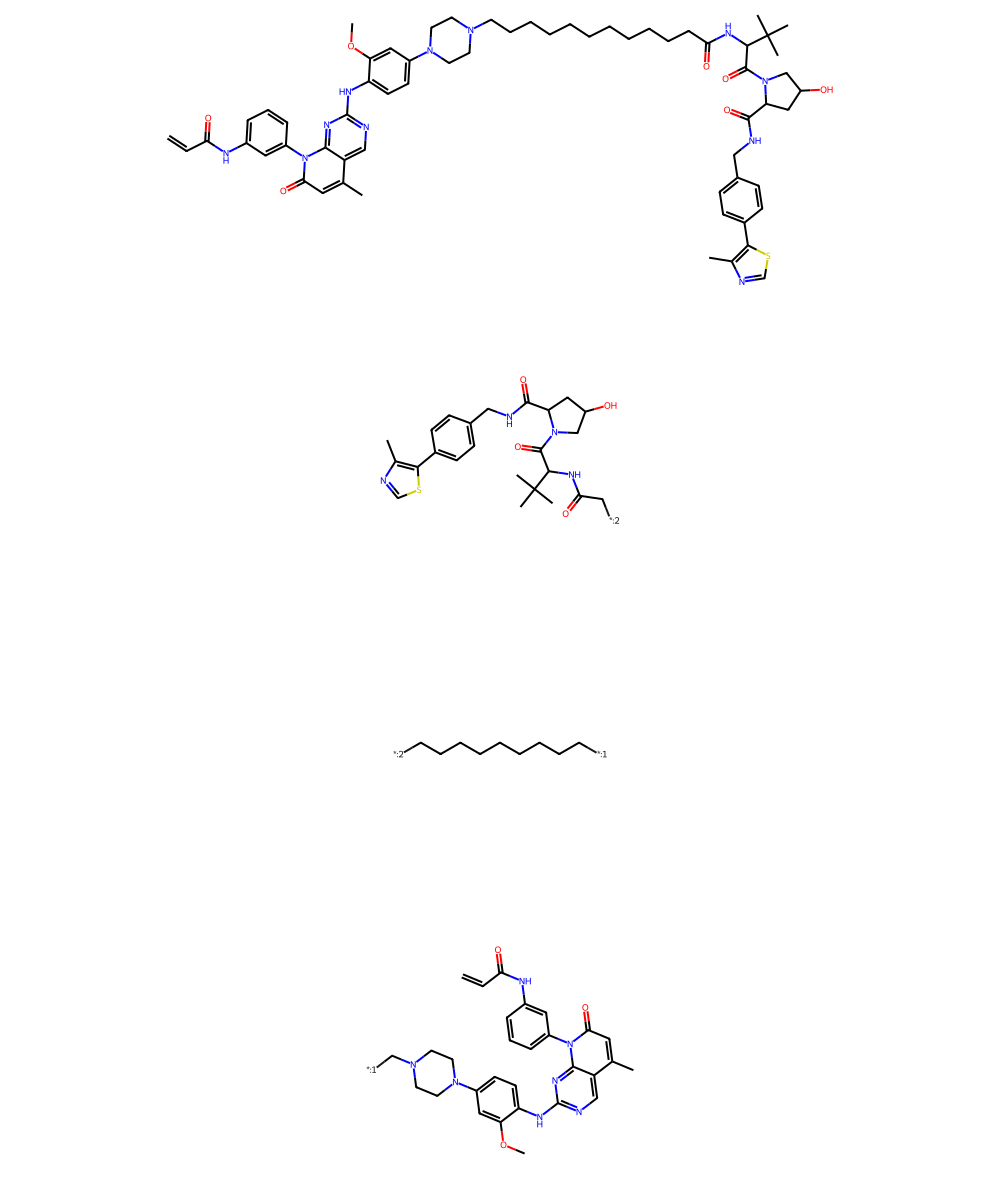

--------------------------------------------------------------------------------
PROTAC: C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCCCC[*:1]
POI:    [*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1


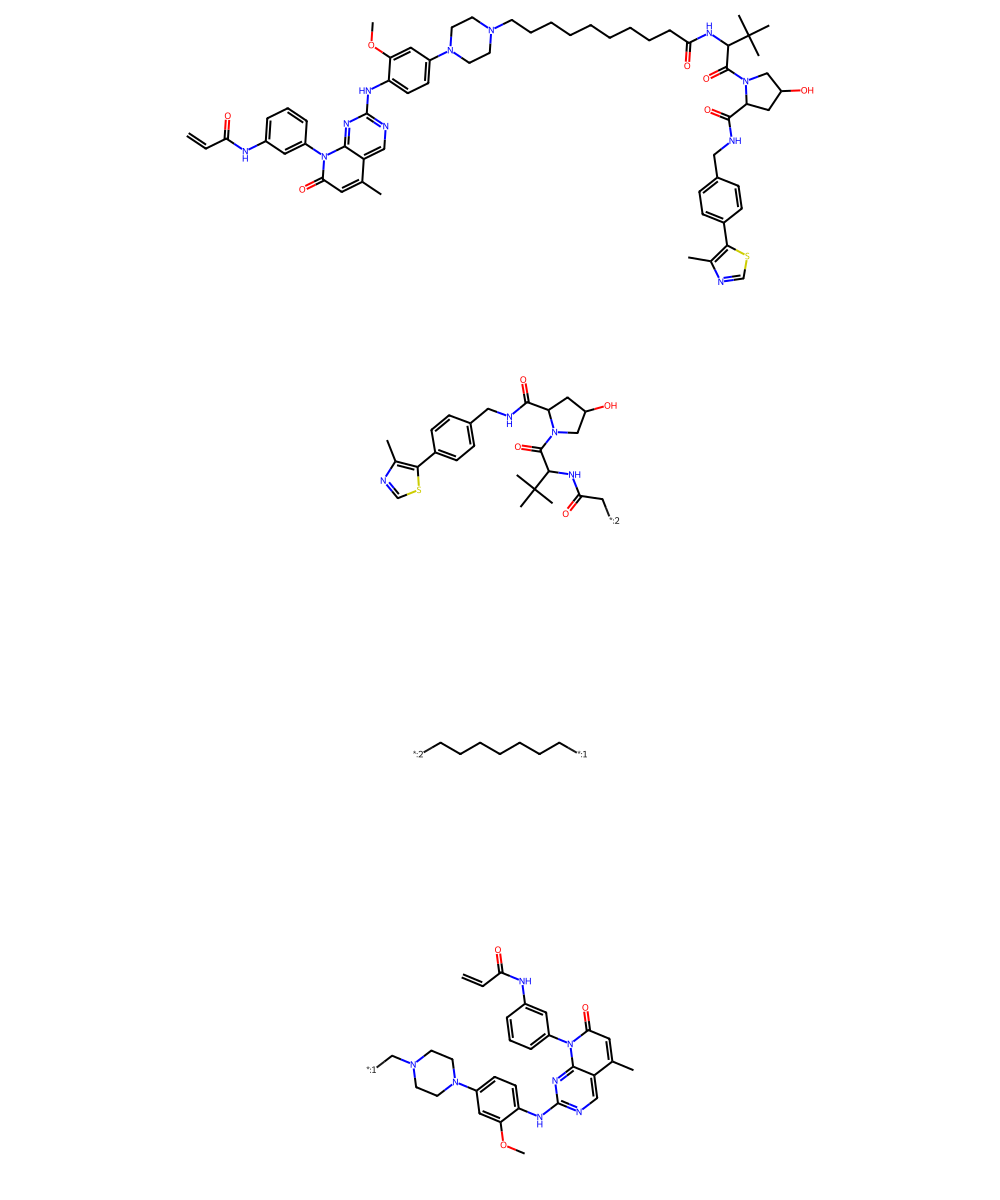

--------------------------------------------------------------------------------
PROTAC: C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCC[*:1]
POI:    [*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1


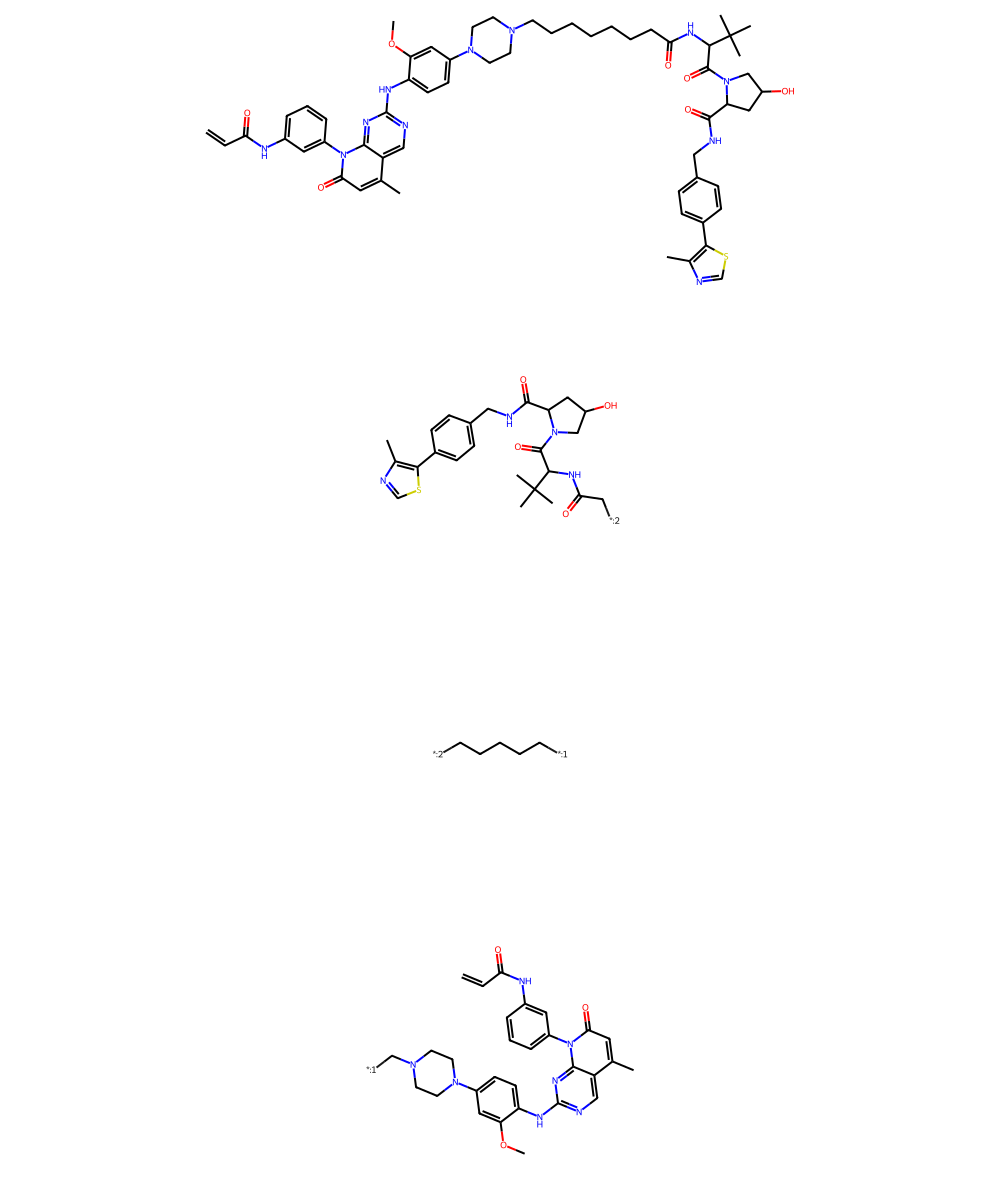

--------------------------------------------------------------------------------
PROTAC: C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCC[*:1]
POI:    [*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1


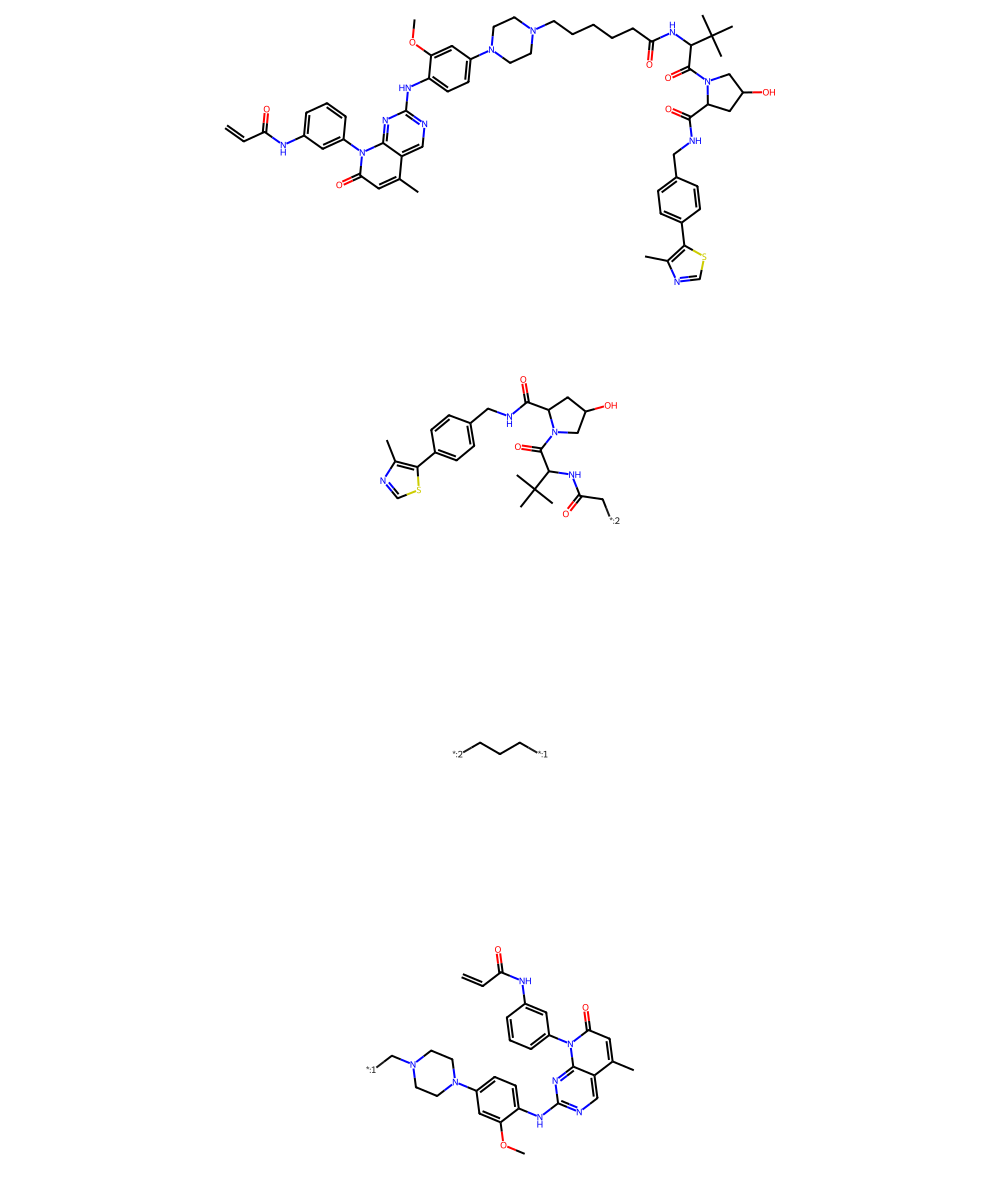

--------------------------------------------------------------------------------
PROTAC: C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]C[*:1]
POI:    [*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1


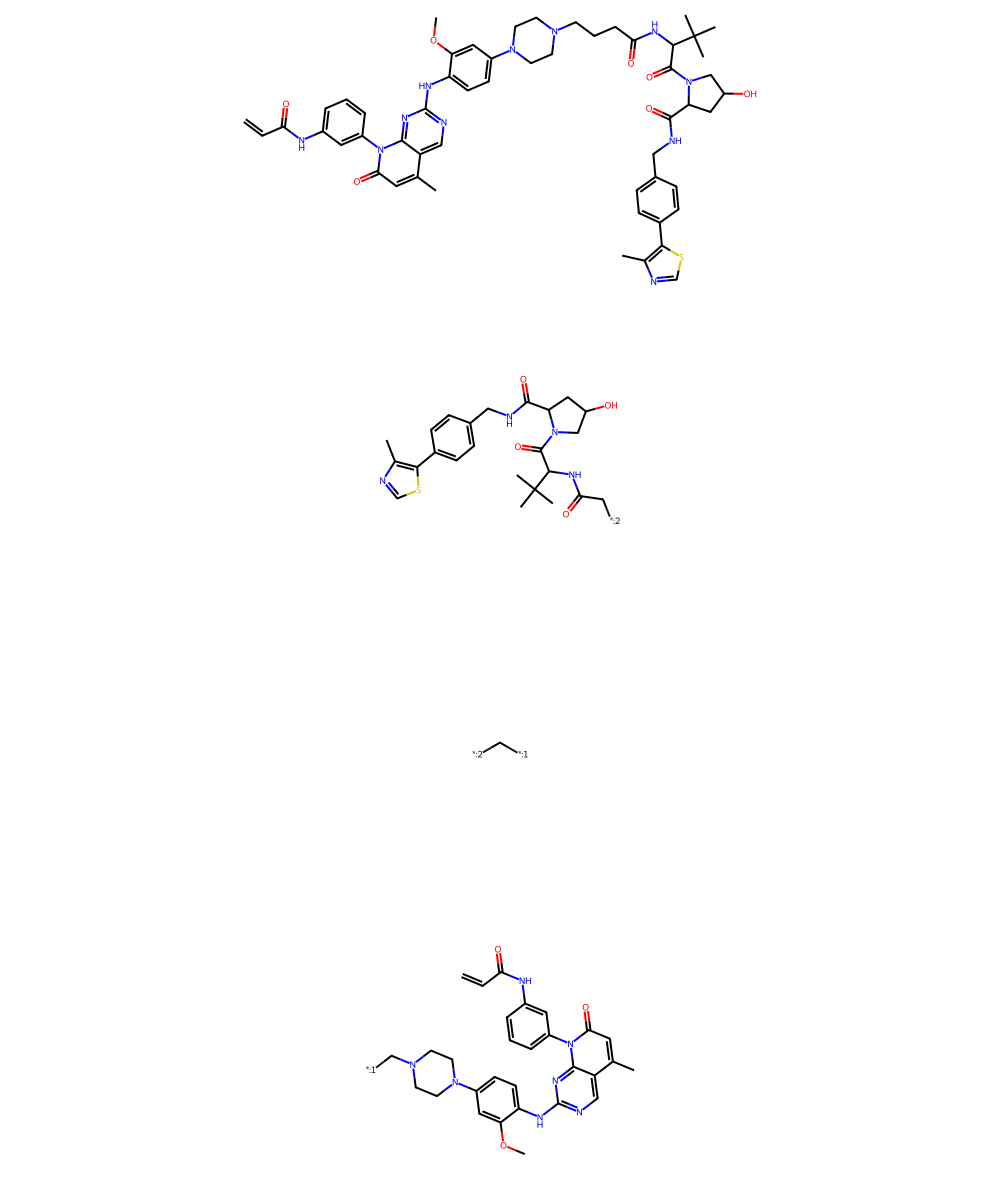

--------------------------------------------------------------------------------
PROTAC: CCC(C)C(N)c1cn(C(Cc2ccc(O)cc2)C(=O)N2CCN(c3nc(NCCOCCOCCOCc4cn(CCCCCC(=O)Nc5cccc6c5C(=O)N(C5CCC(=O)NC5=O)C6=O)nn4)nc(N4CCN(C(=O)C(Cc5ccc(O)cc5)n5cc(C(N)C(C)CC)nn5)CC4)n3)CC2)nn1
E3:     [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]C(=O)CCCCCn1cc(COCCOCCOCC[*:1])nn1
POI:    [*:1]Nc1nc(N2CCN(C(=O)C(Cc3ccc(O)cc3)n3cc(C(N)C(C)CC)nn3)CC2)nc(N2CCN(C(=O)C(Cc3ccc(O)cc3)n3cc(C(N)C(C)CC)nn3)CC2)n1


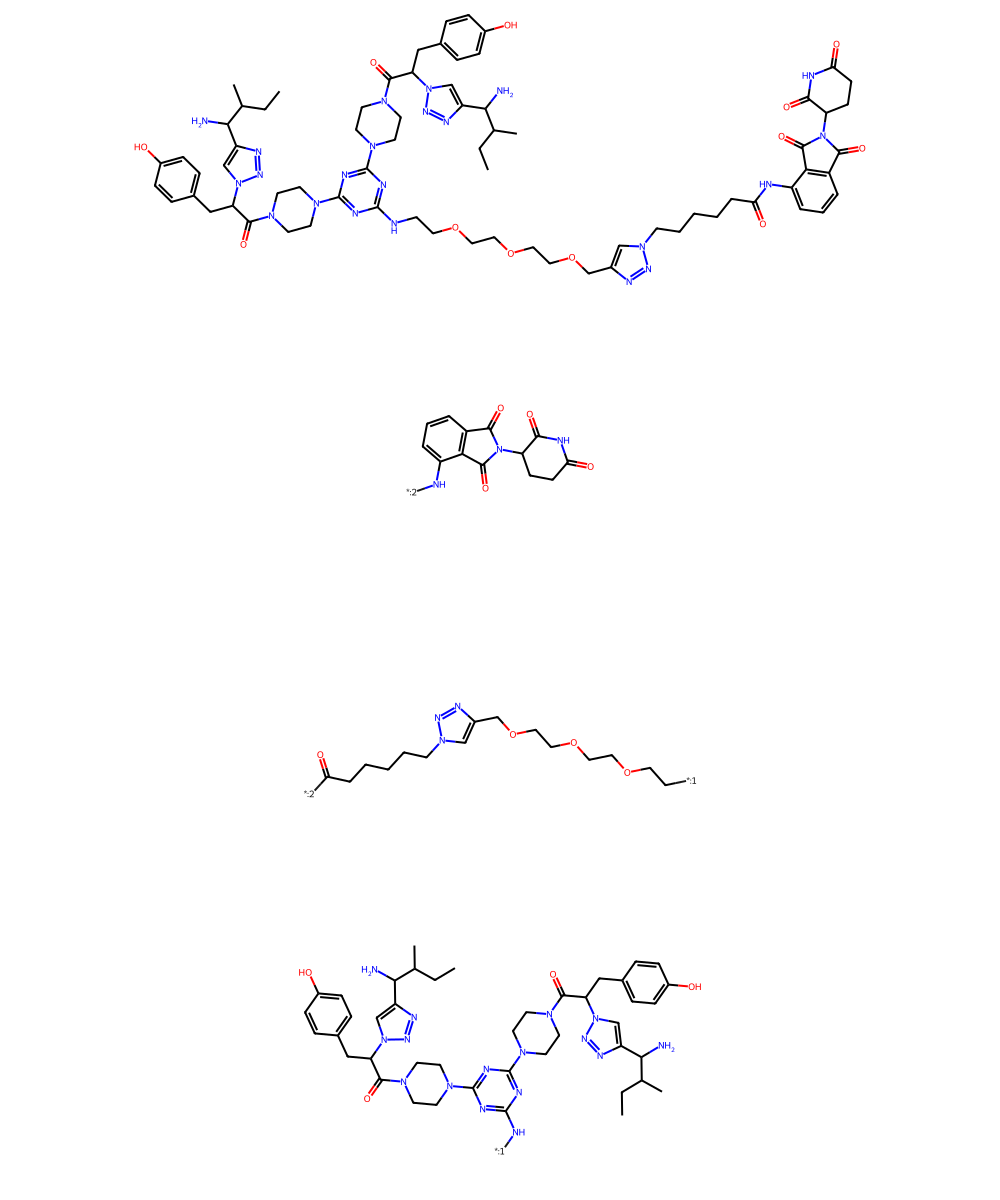

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CCCCCCCCCn2cc(Nc3ncc(Cl)c(NCc4cc(F)ccc4F)n3)cn2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCCCC[*:1]
POI:    [*:1]Cn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1


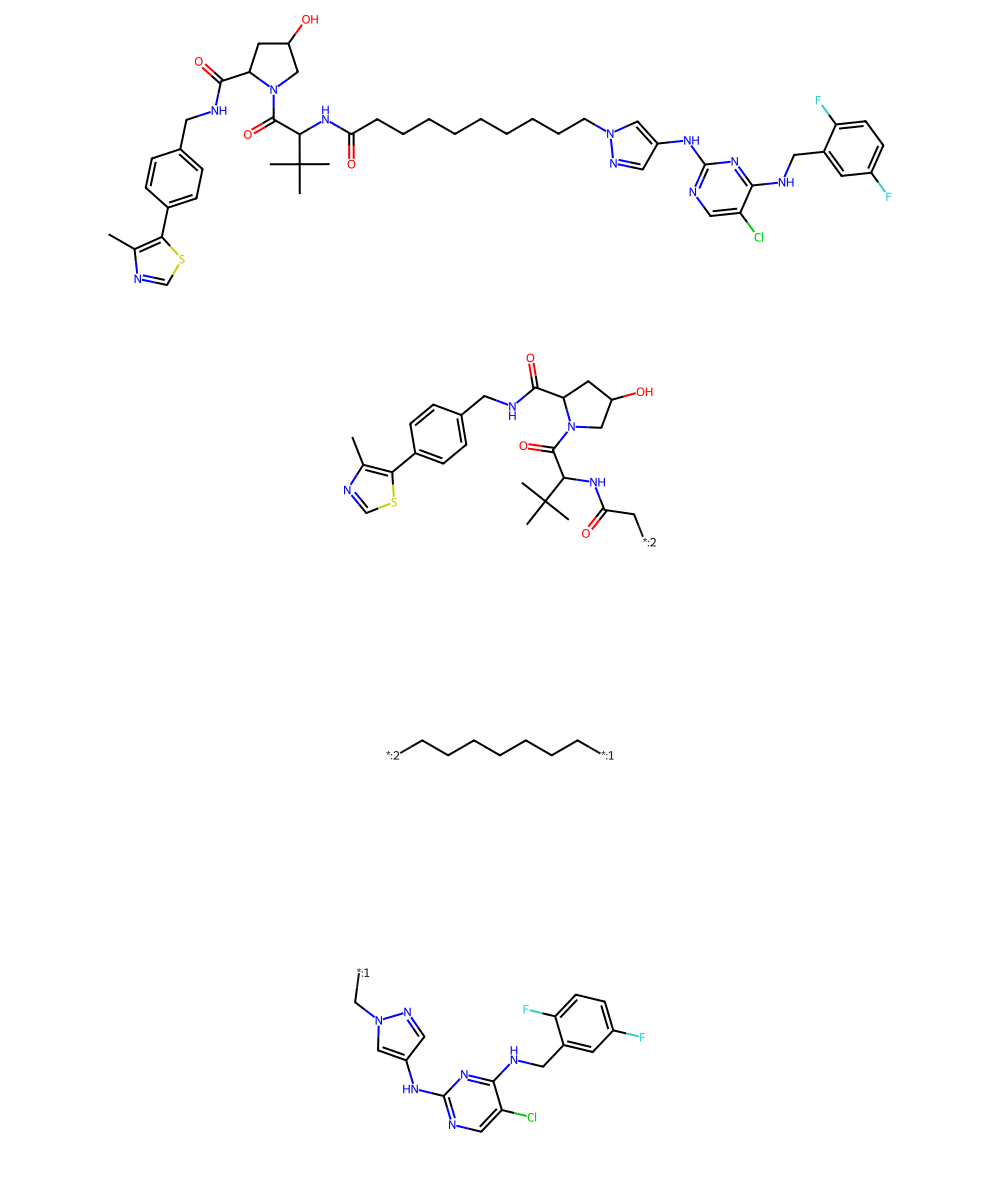

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCn2cc(Nc3ncc(Cl)c(NCc4cc(F)ccc4F)n3)cn2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCC[*:1]
POI:    [*:1]OCCn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1


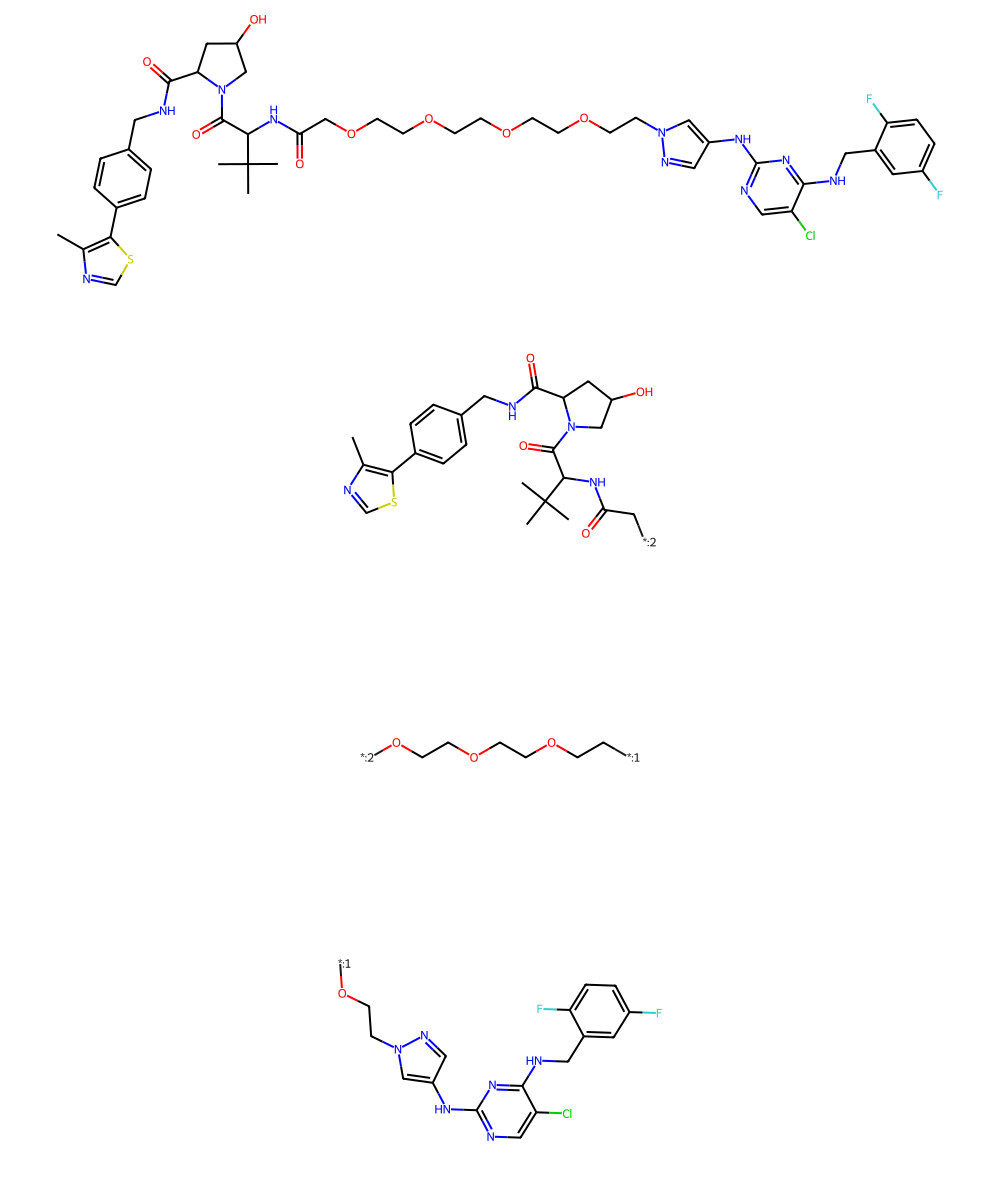

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CCCCCCCCCOc2cc(F)cc(CNc3nc(Nc4cnn(C)c4)ncc3Cl)c2F)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCCCCCO[*:1]
POI:    [*:1]c1cc(F)cc(CNc2nc(Nc3cnn(C)c3)ncc2Cl)c1F


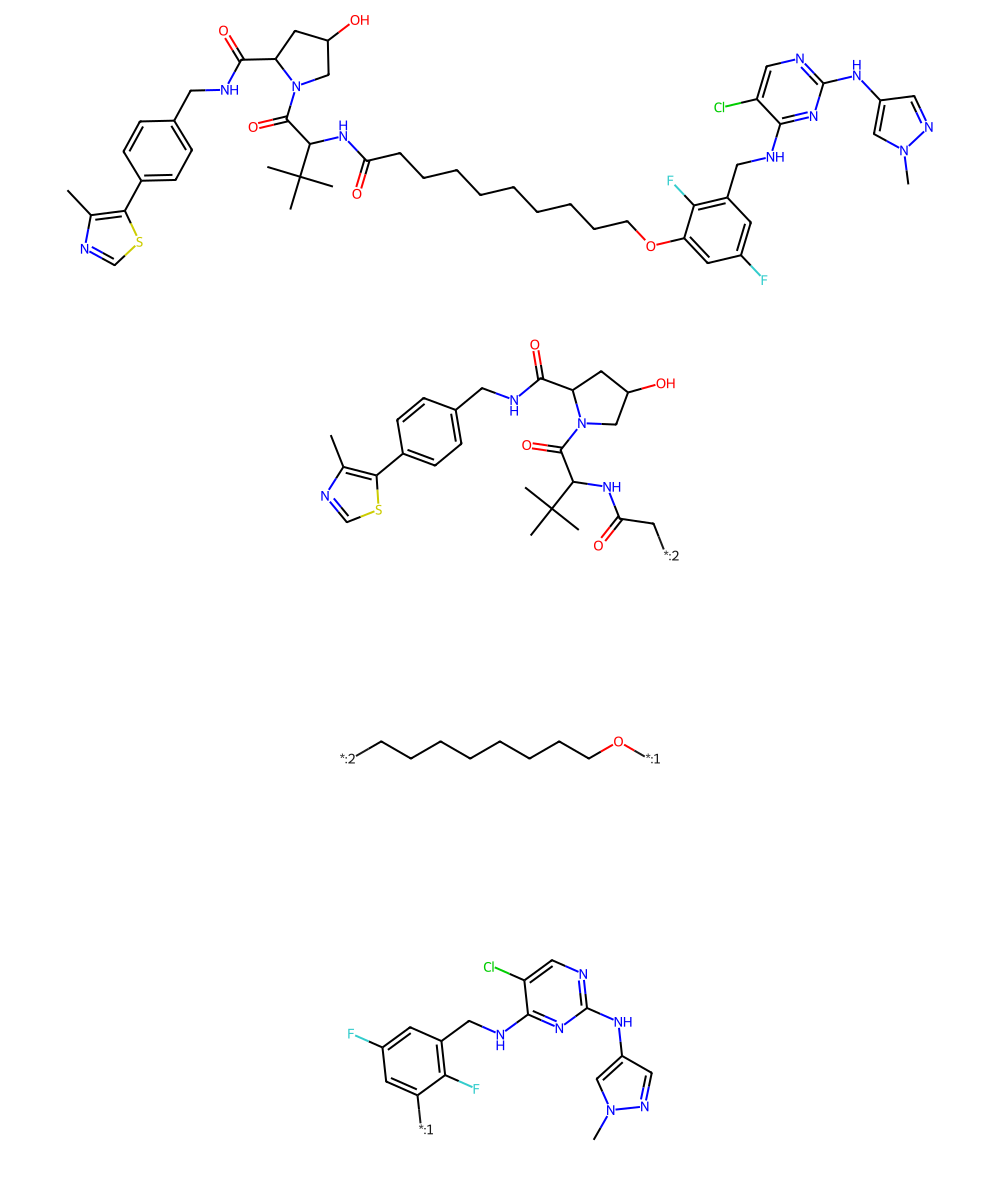

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCOc2cc(F)cc(CNc3nc(Nc4cnn(C)c4)ncc3Cl)c2F)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCOCCO[*:1]
POI:    [*:1]c1cc(F)cc(CNc2nc(Nc3cnn(C)c3)ncc2Cl)c1F


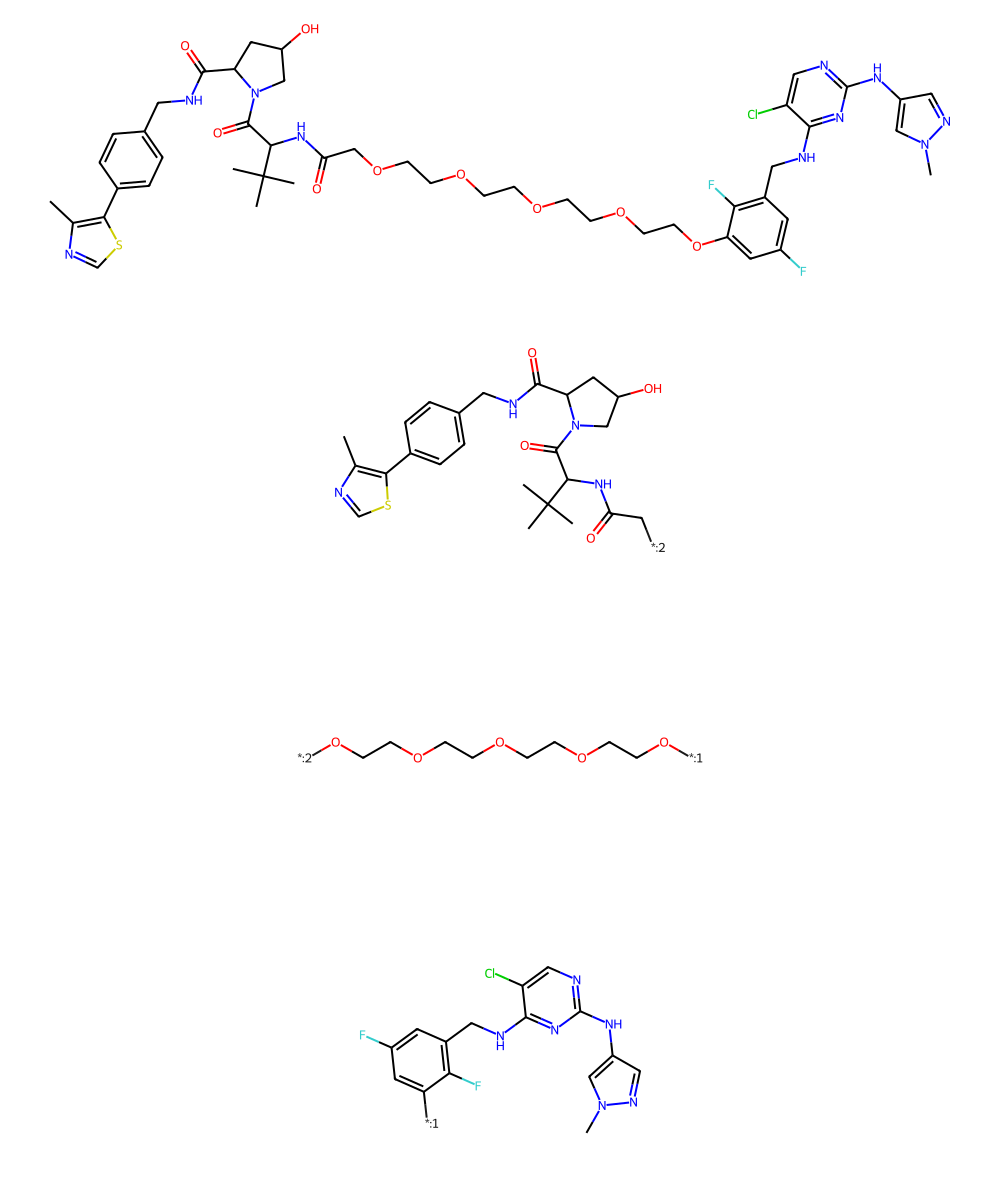

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCOCCOCCOc2cc(F)cc(CNc3nc(Nc4cnn(C)c4)ncc3Cl)c2F)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCOCCOCCOCCO[*:1]
POI:    [*:1]c1cc(F)cc(CNc2nc(Nc3cnn(C)c3)ncc2Cl)c1F


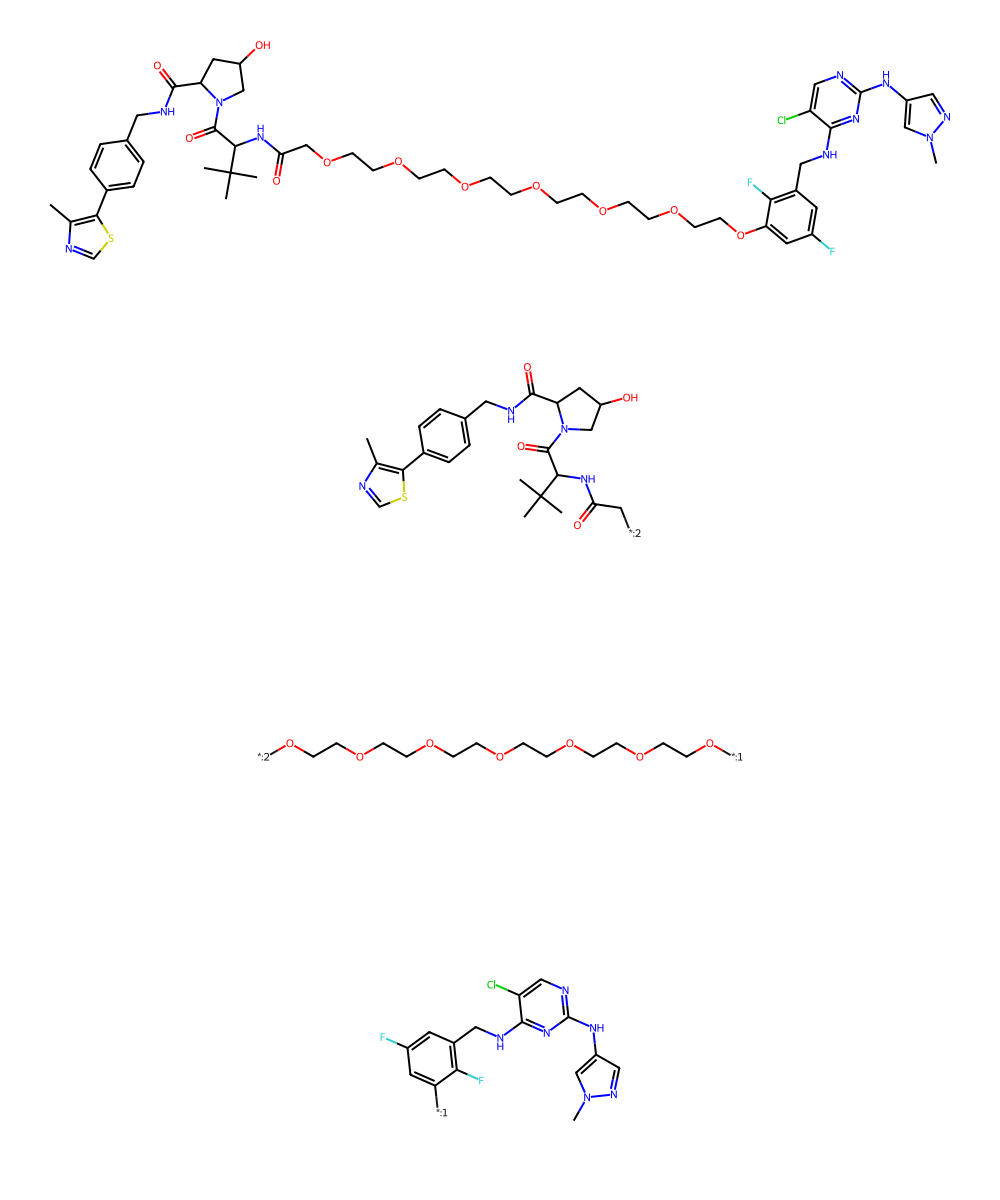

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


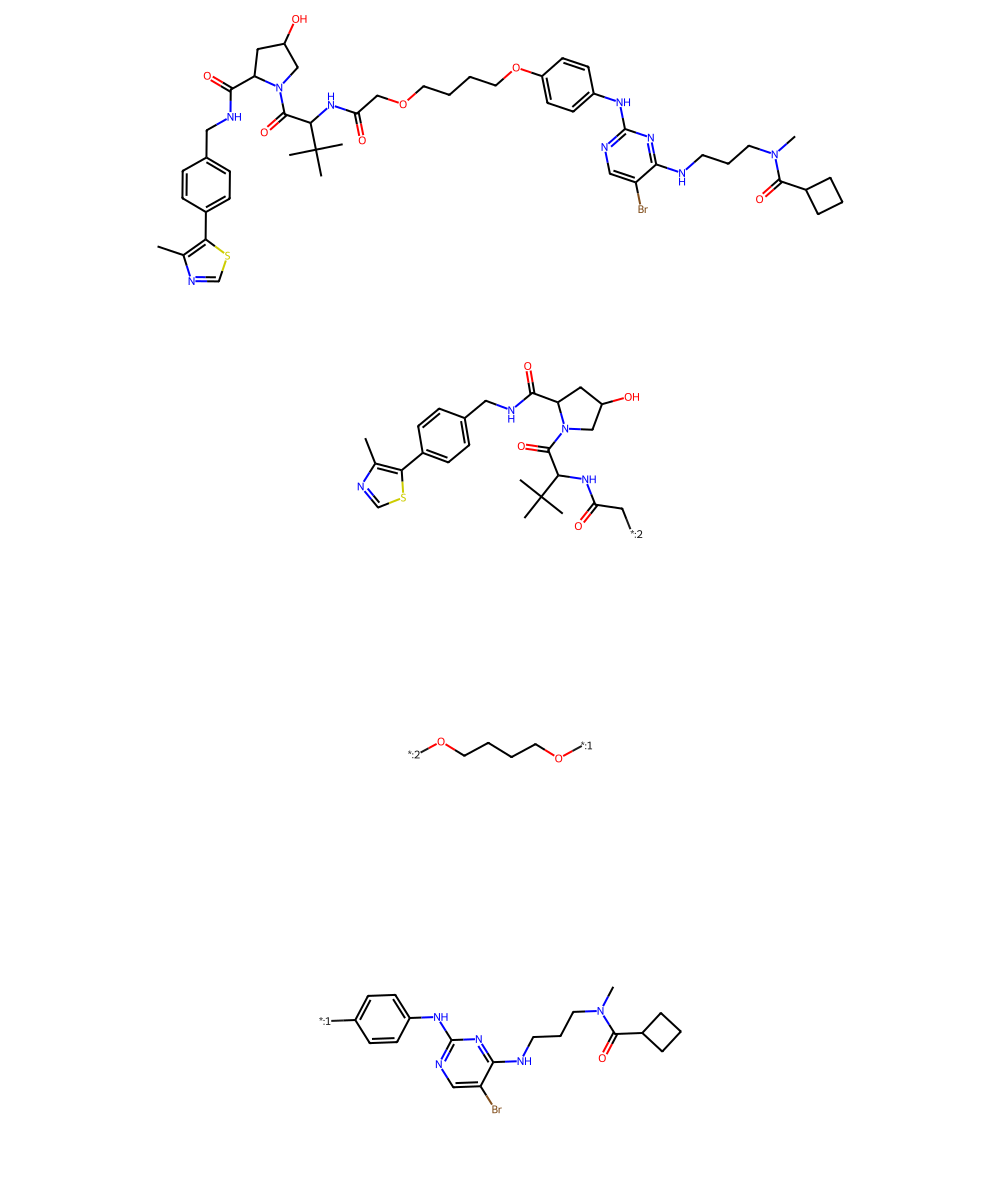

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


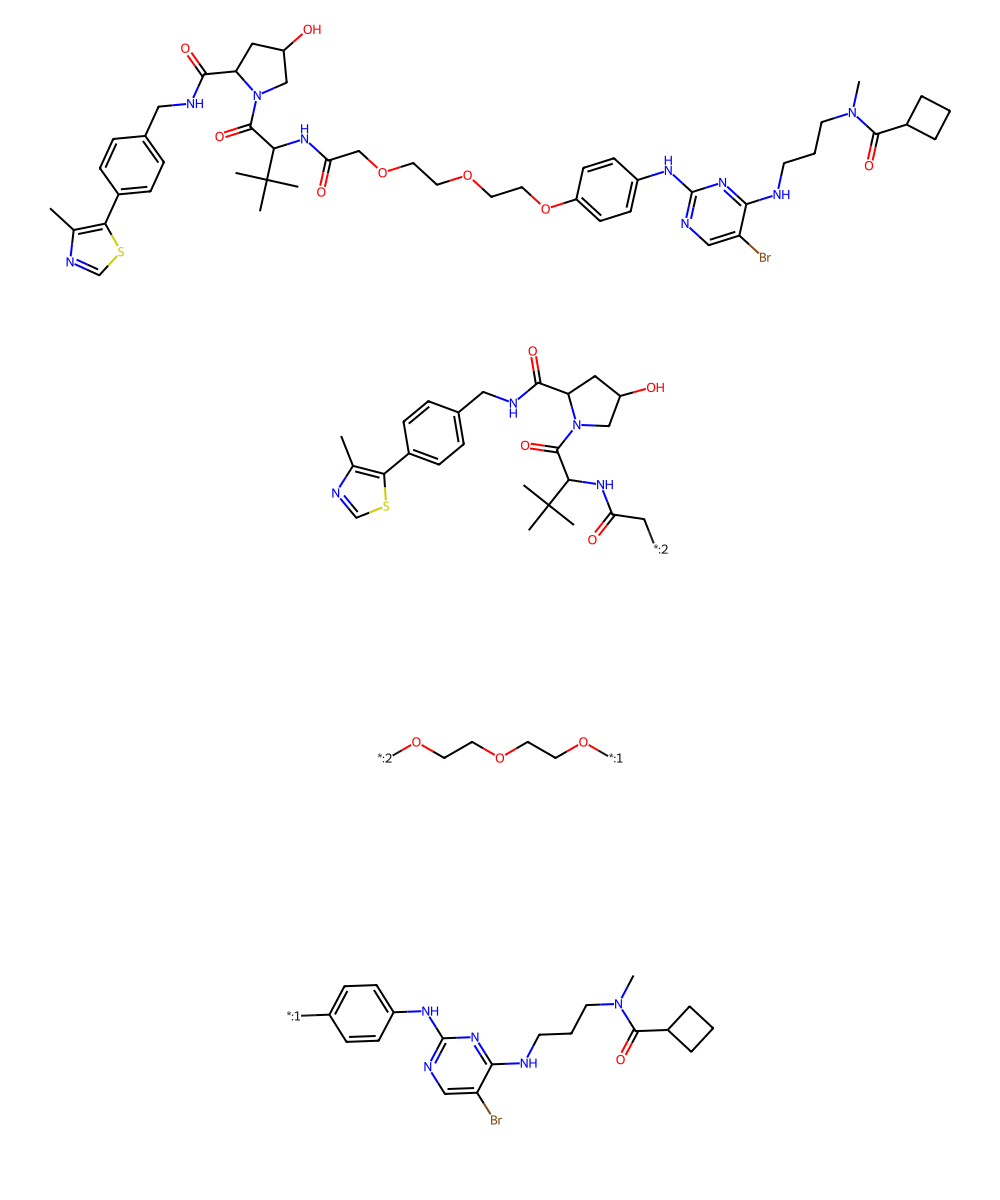

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CCCCCOCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCOCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


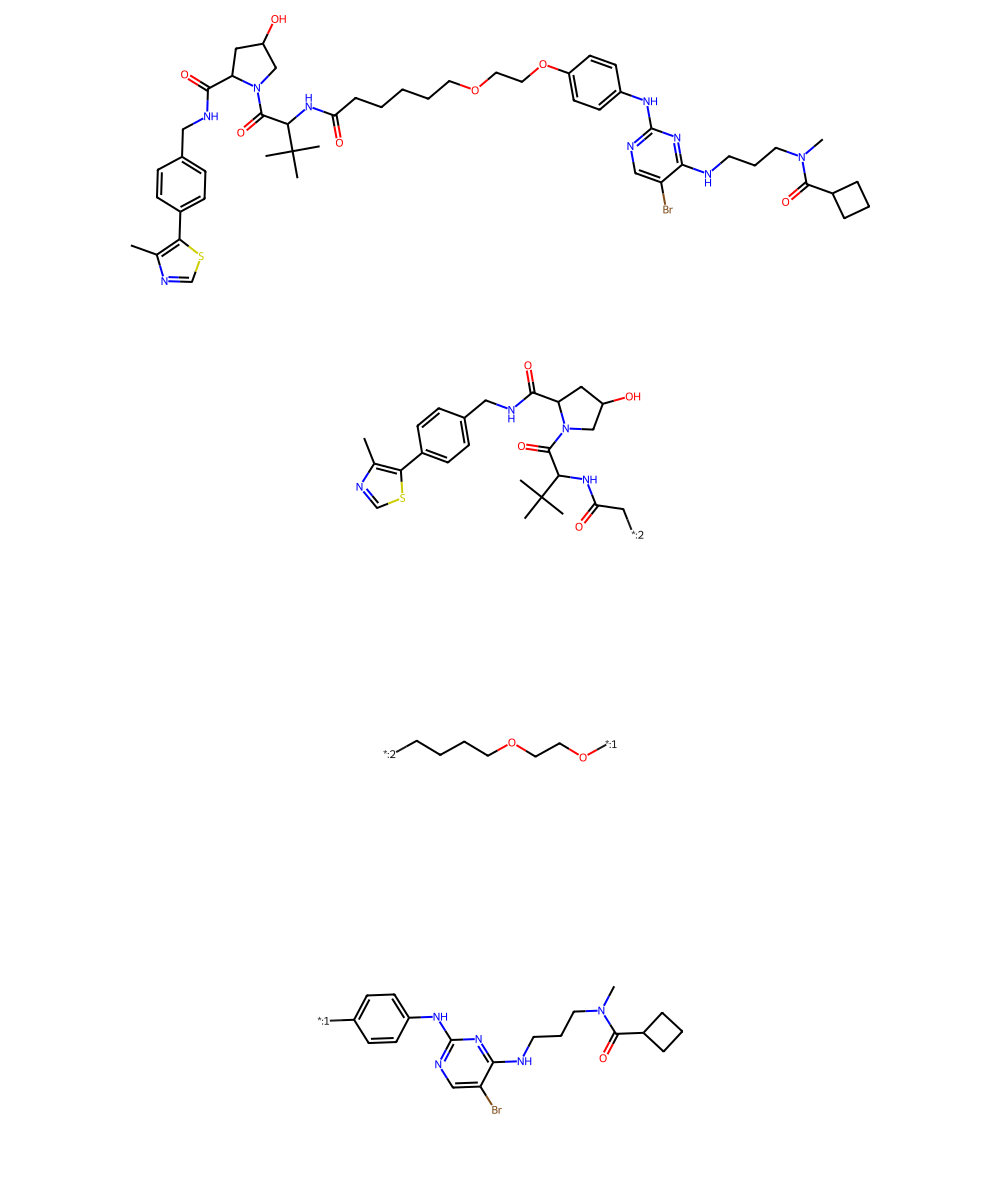

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


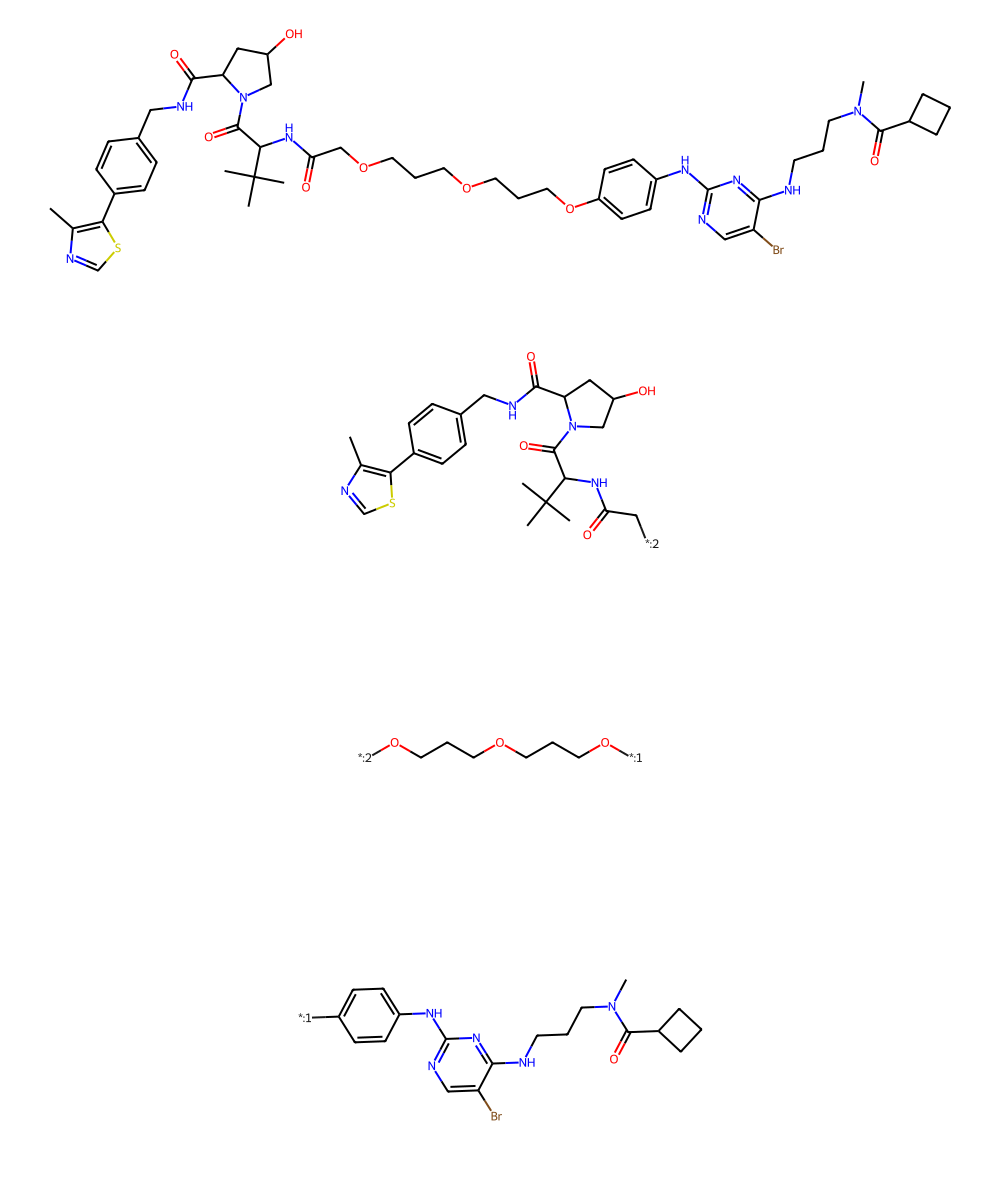

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


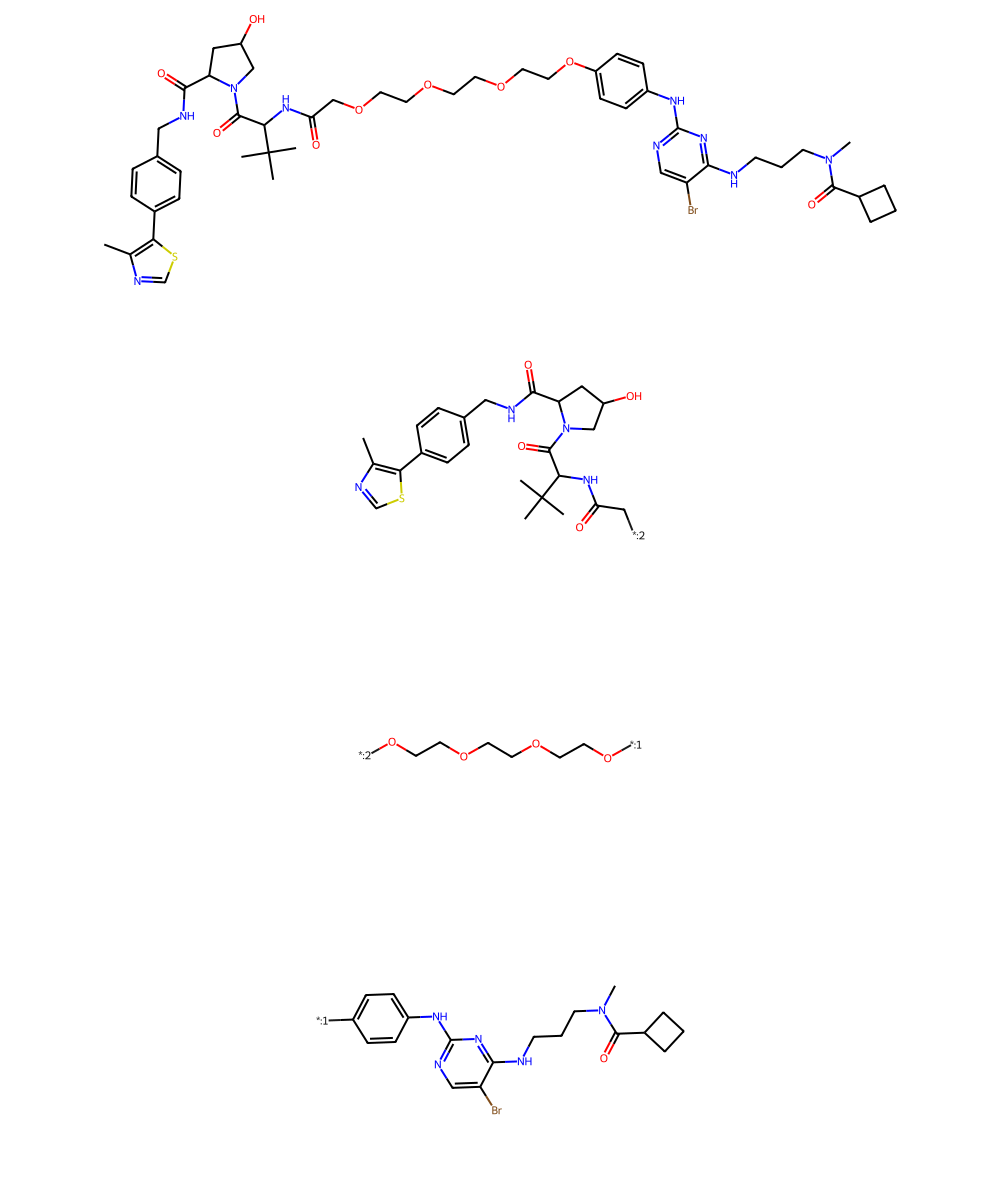

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


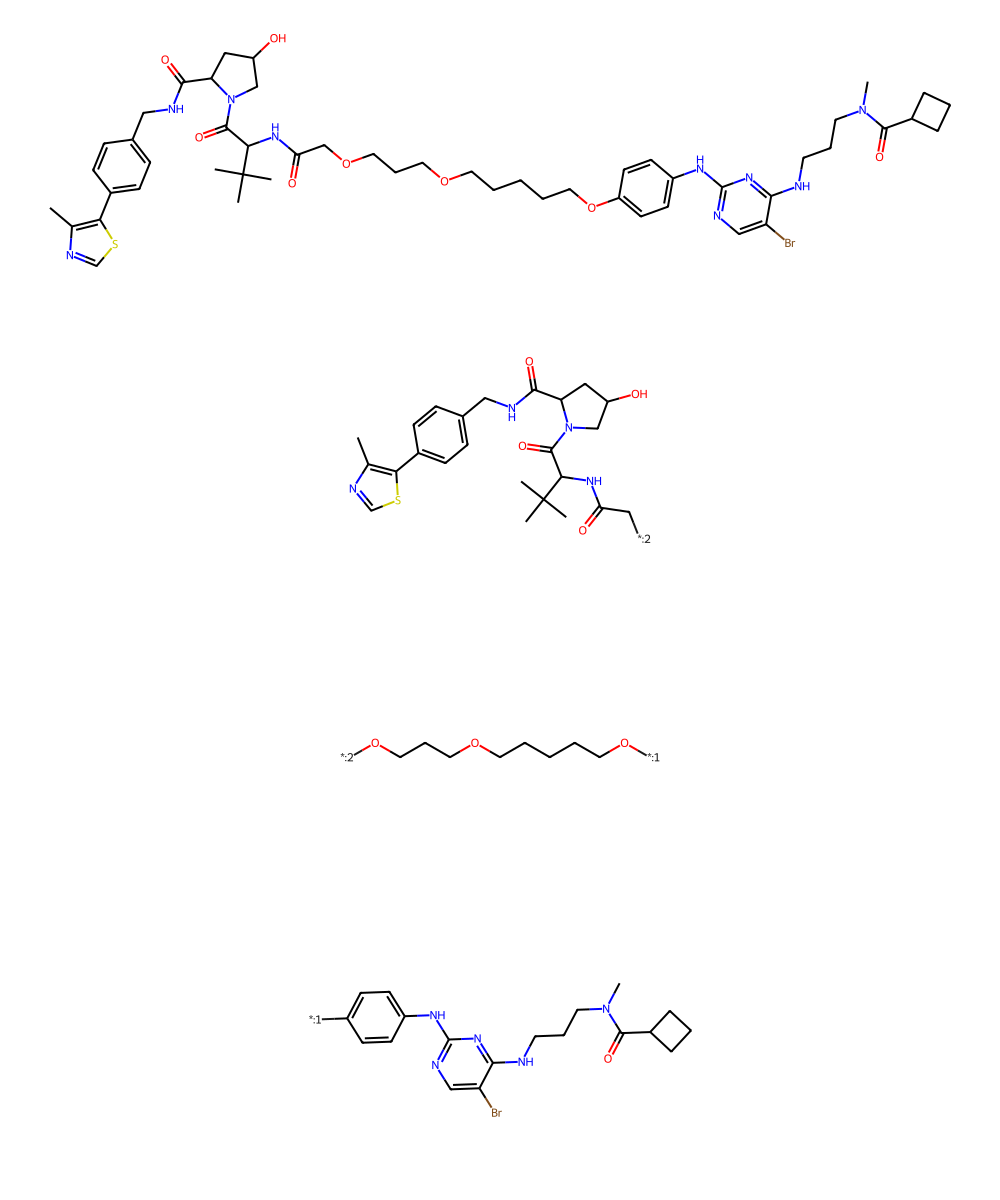

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


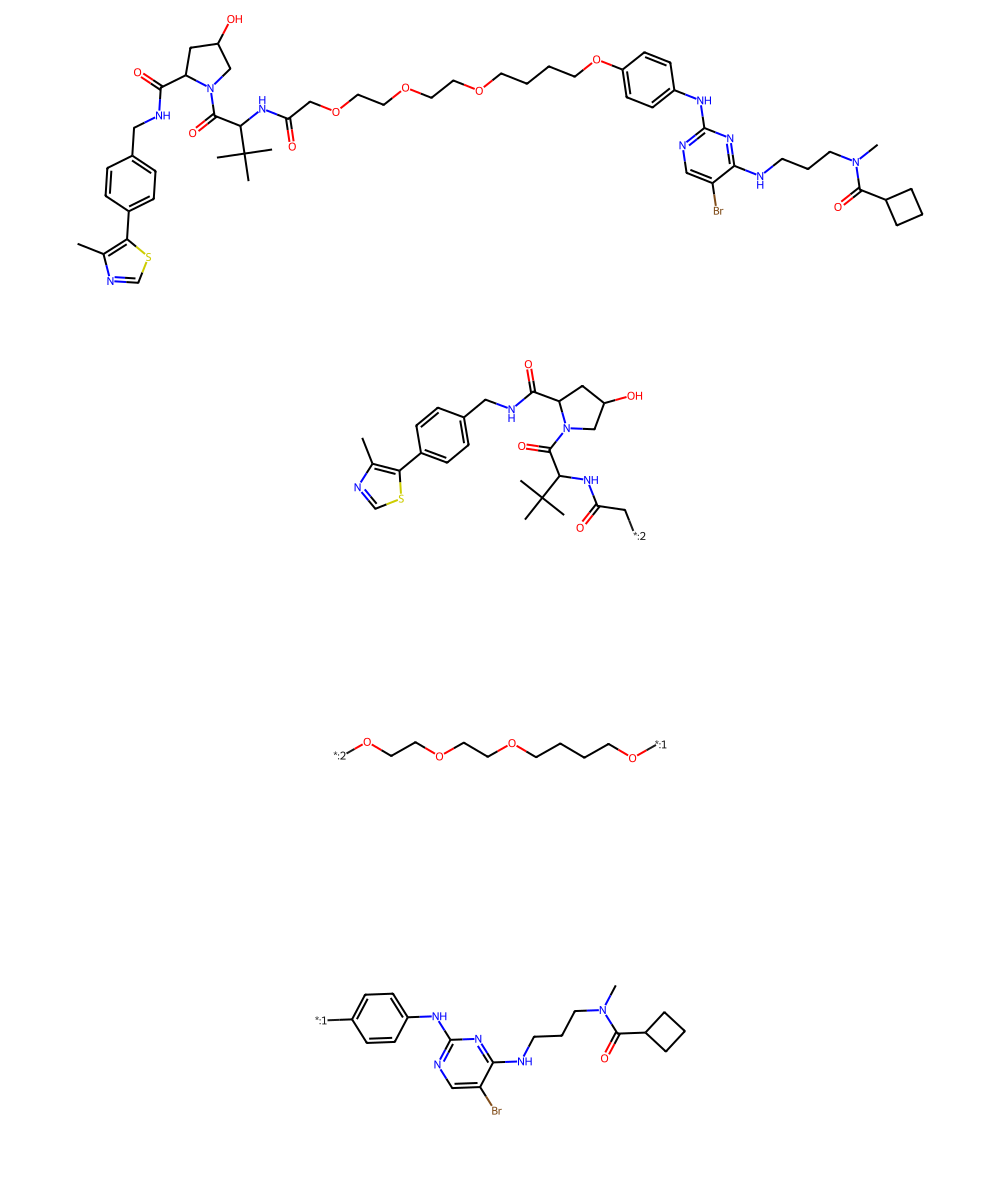

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCOCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


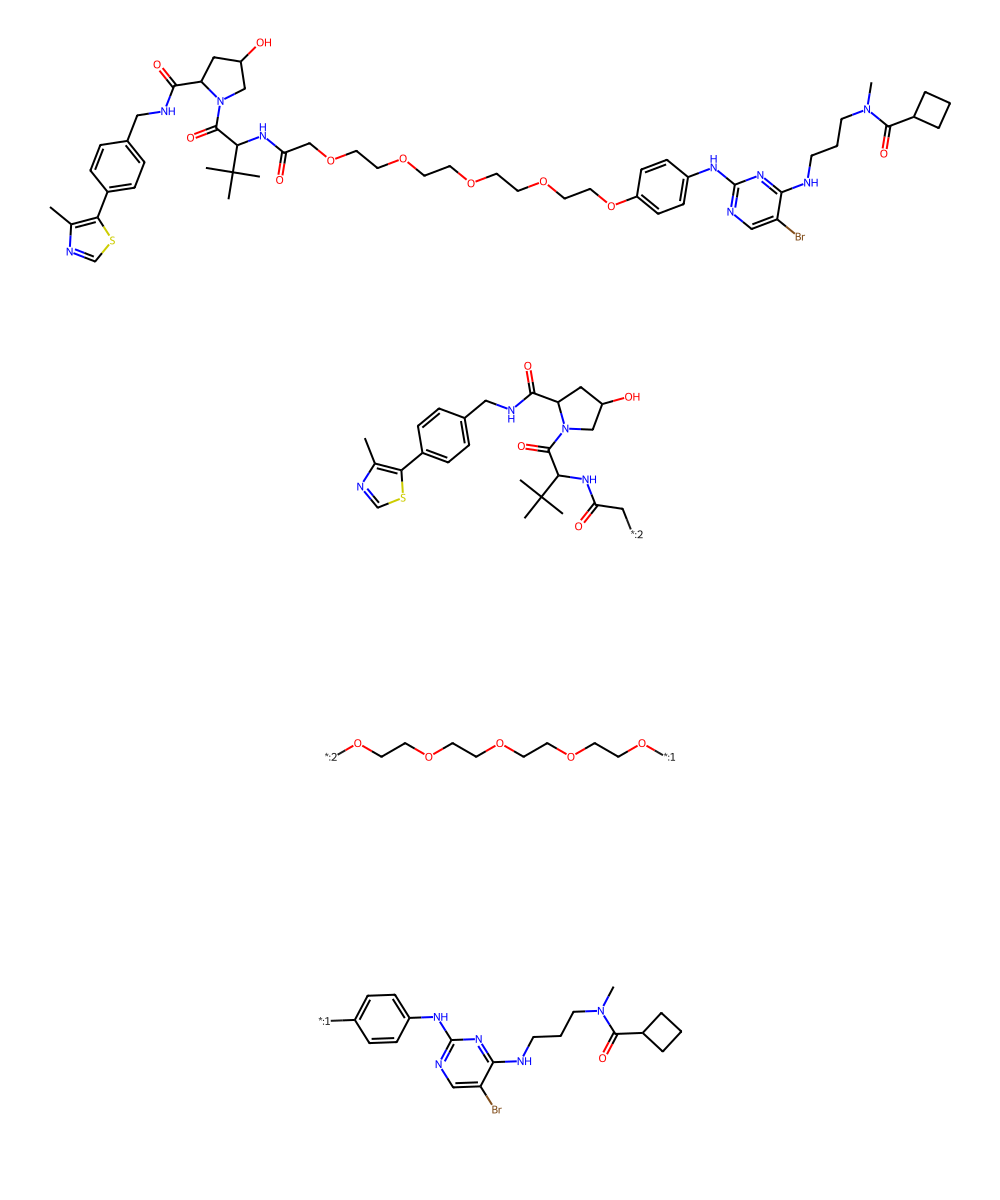

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCCOCCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


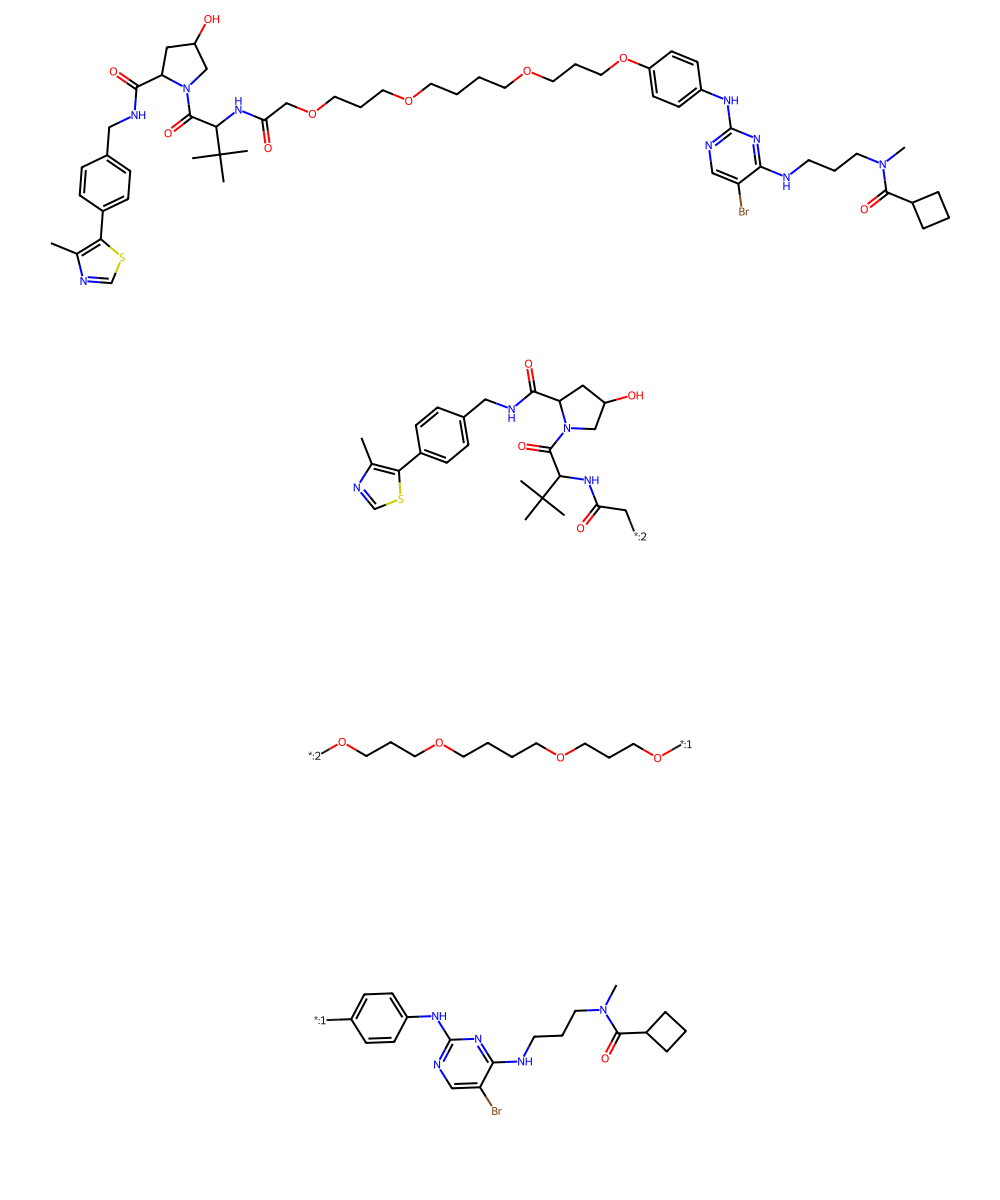

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CCCCCOCCCCOCCCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCOCCCCOCCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


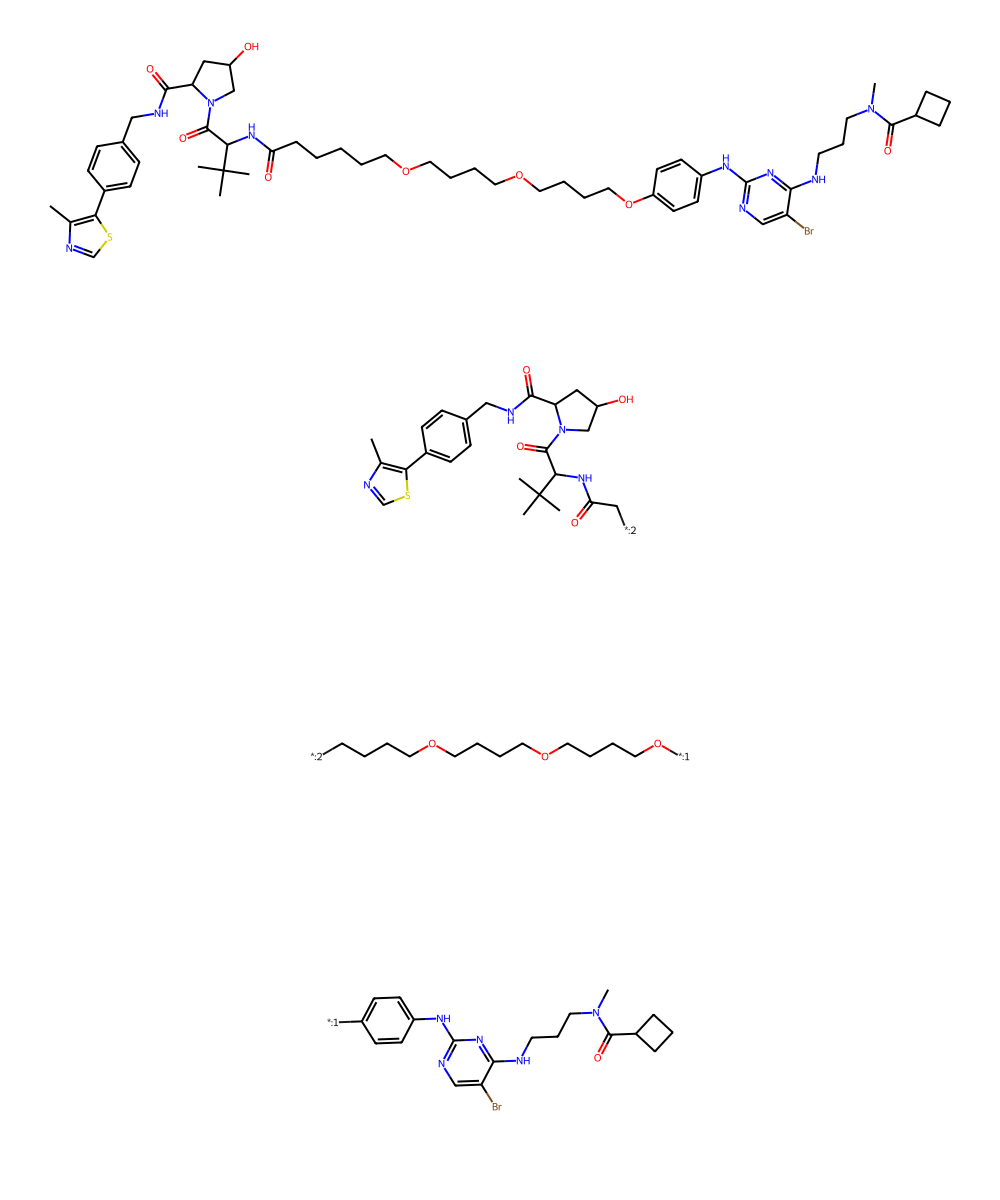

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCOCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCOCCOCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


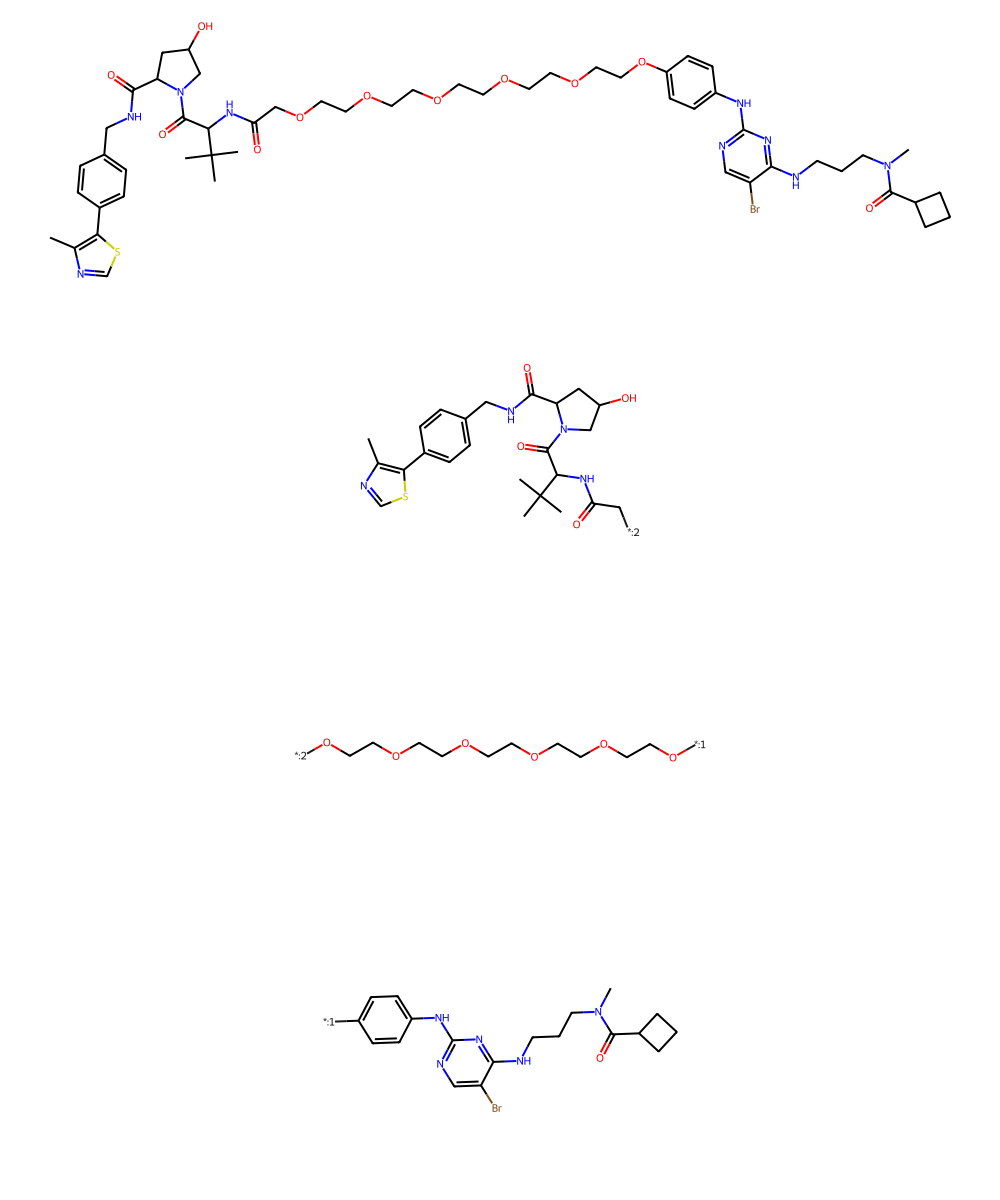

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCCCOCCCCOCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCCCOCCCCOCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


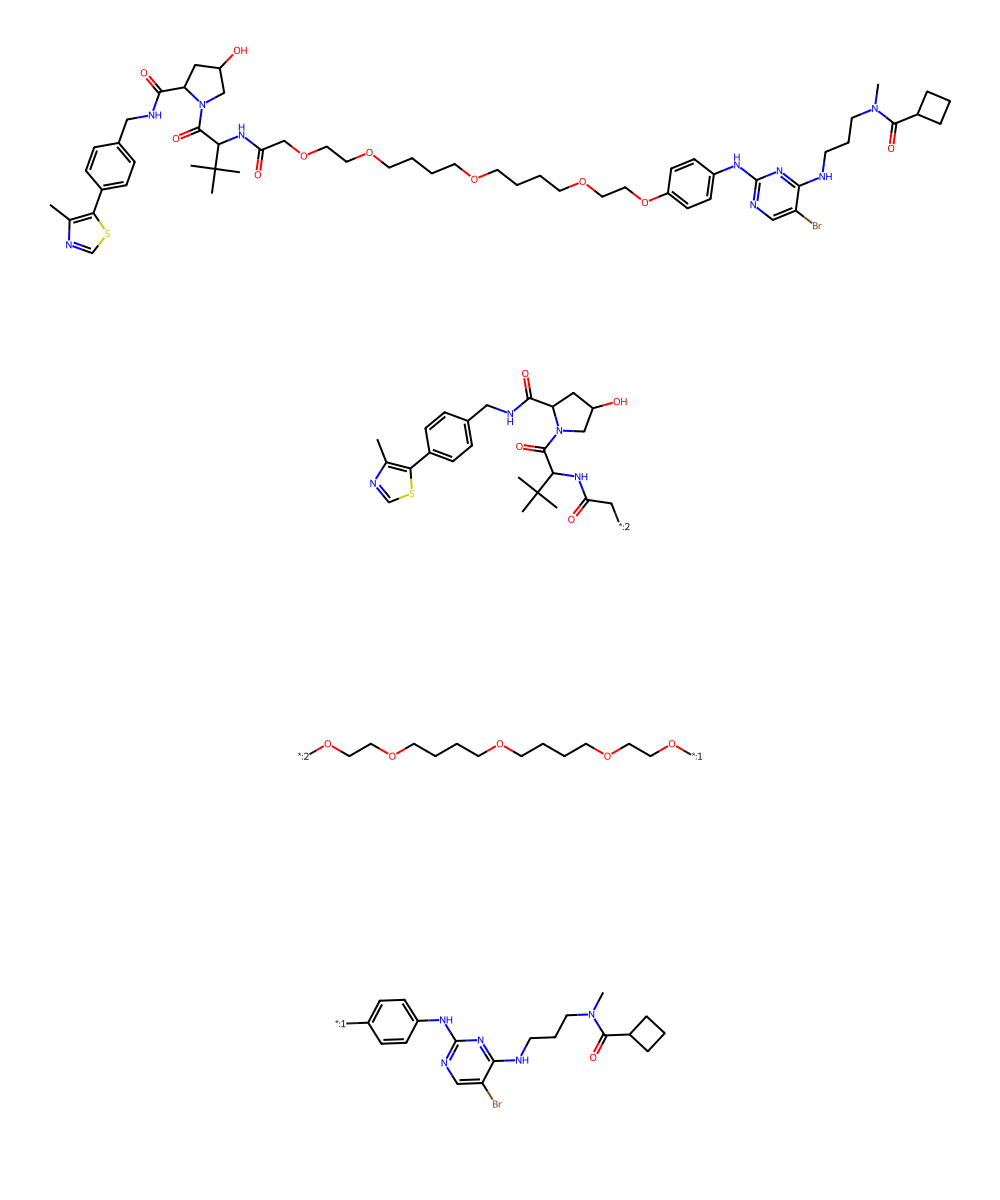

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CCOCCCOCCCOCCCOCCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]COCCCOCCCOCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


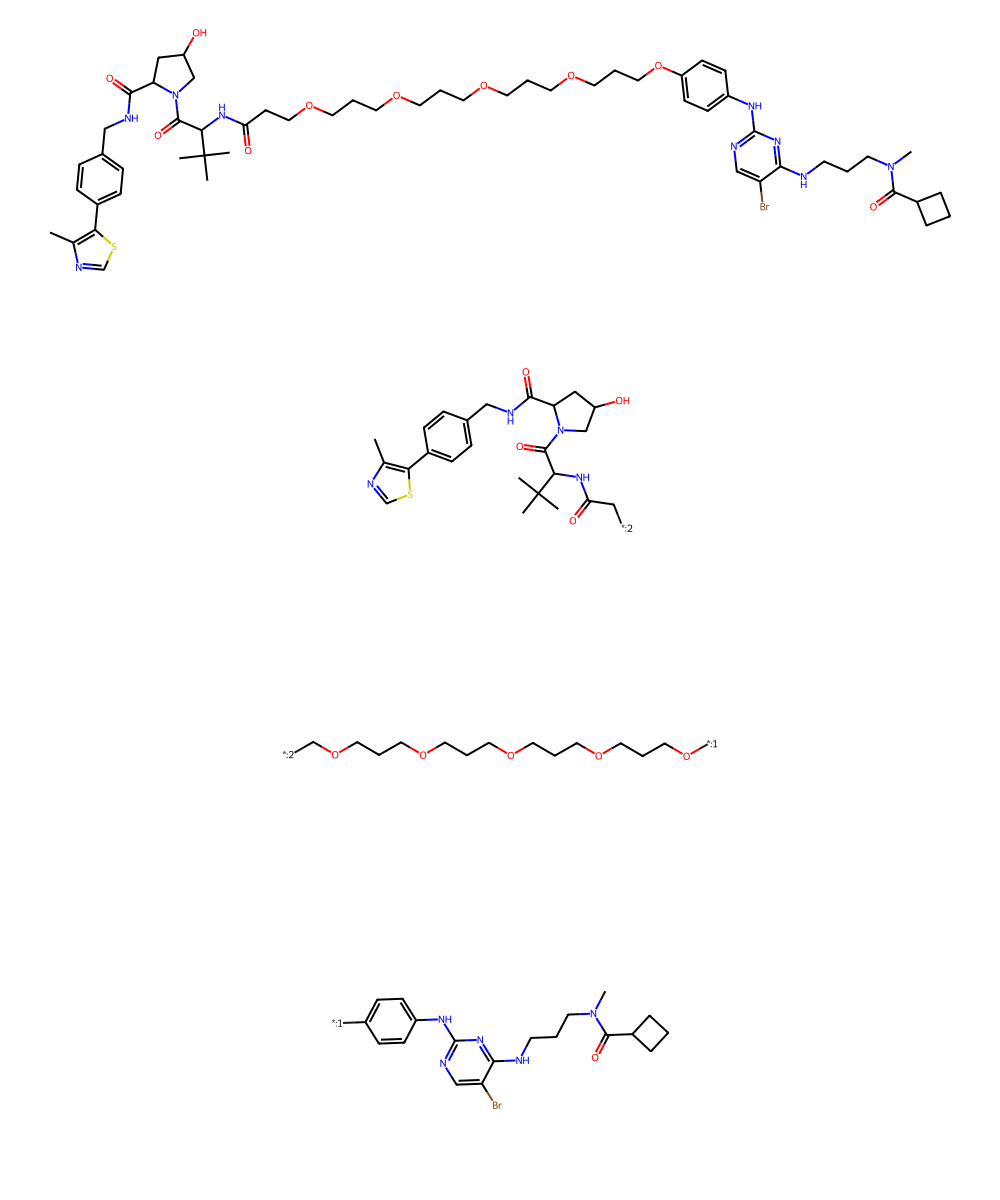

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCOCCOCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCOCCOCCOCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


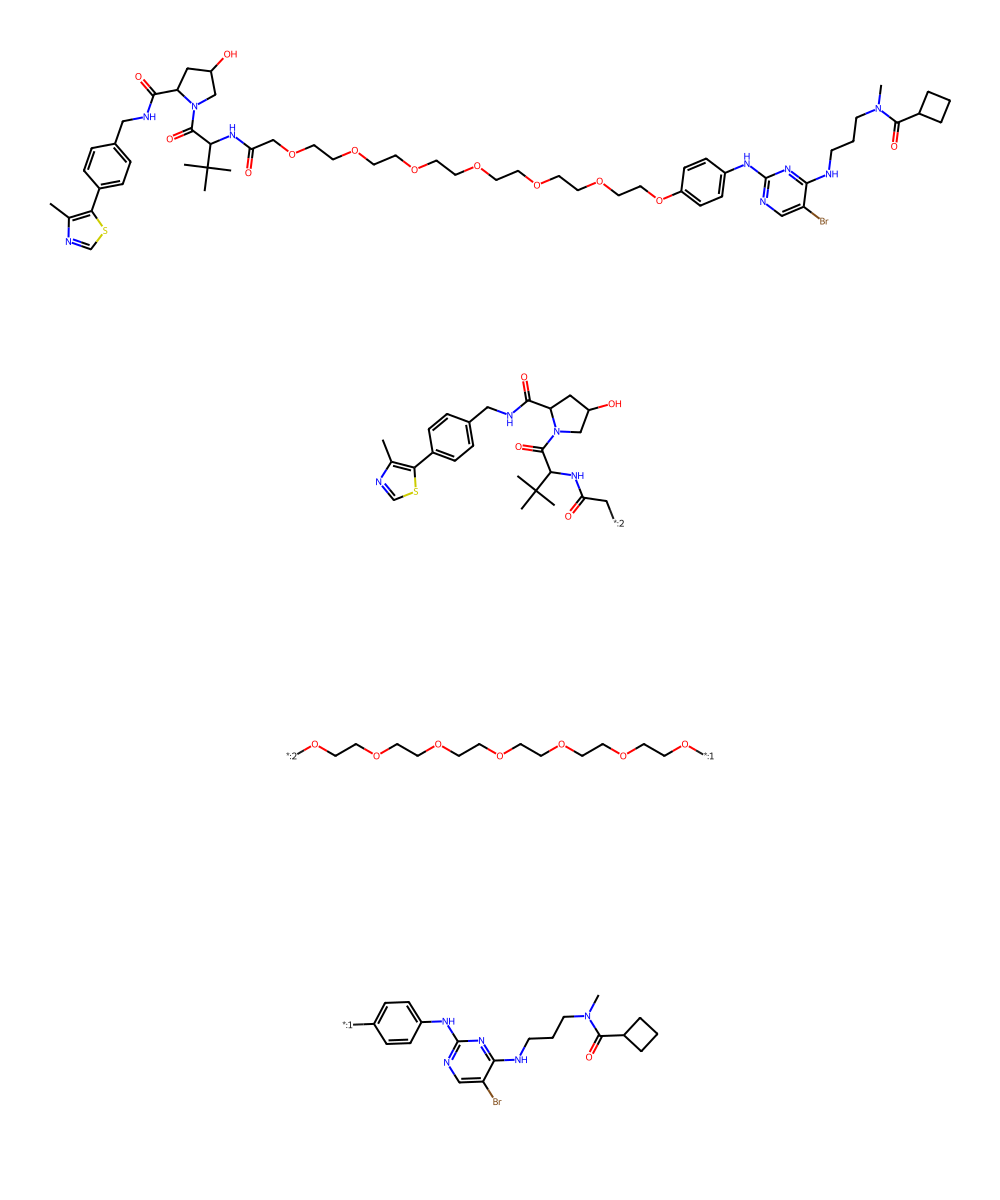

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCCCOCCCCOCCOCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCCCOCCCCOCCOCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


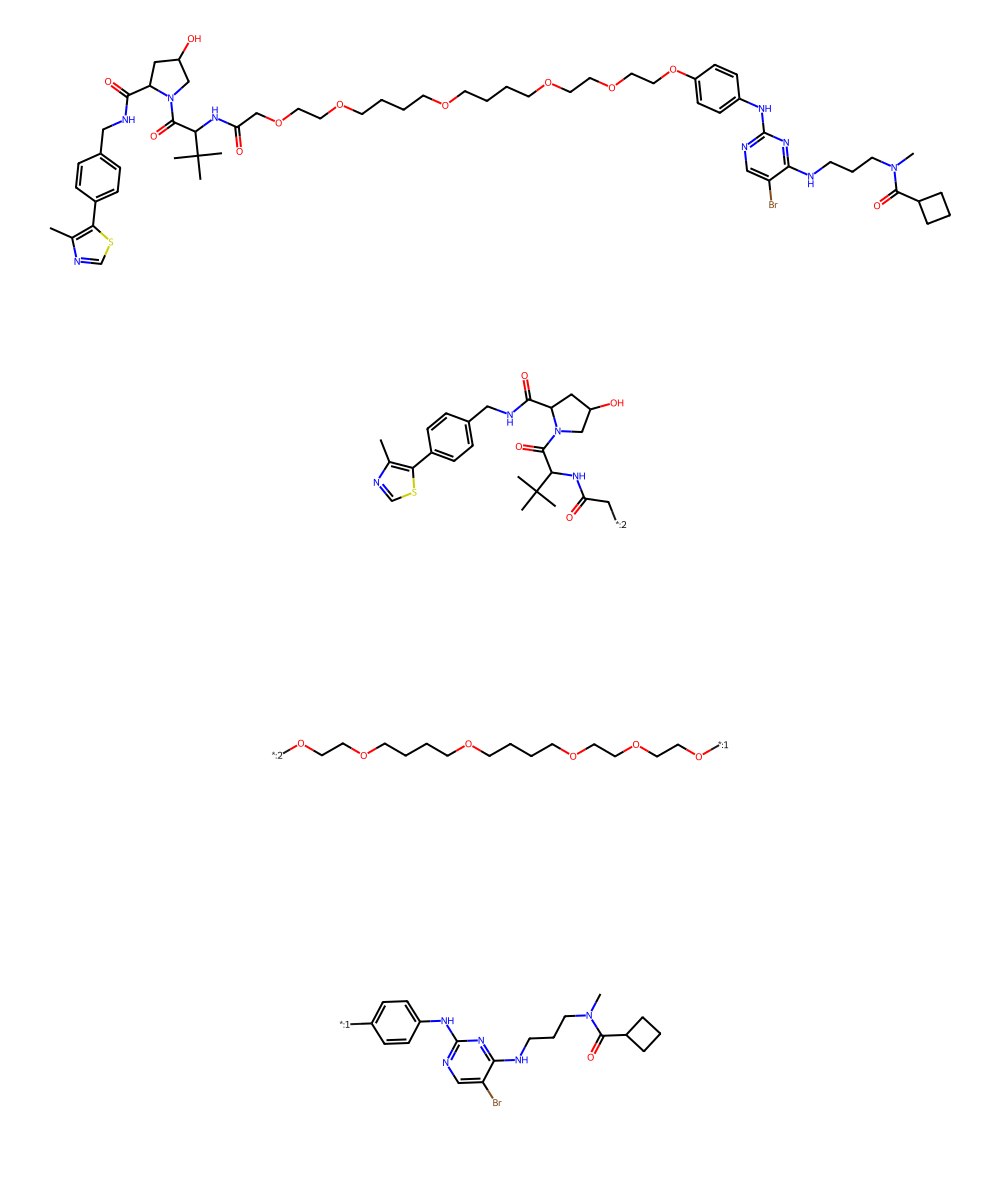

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCCCOCCCCOCCCCOCCCCOCCCCCOc2ccc(Nc3ncc(Br)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCCCOCCCCOCCCCOCCCCOCCCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Br)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


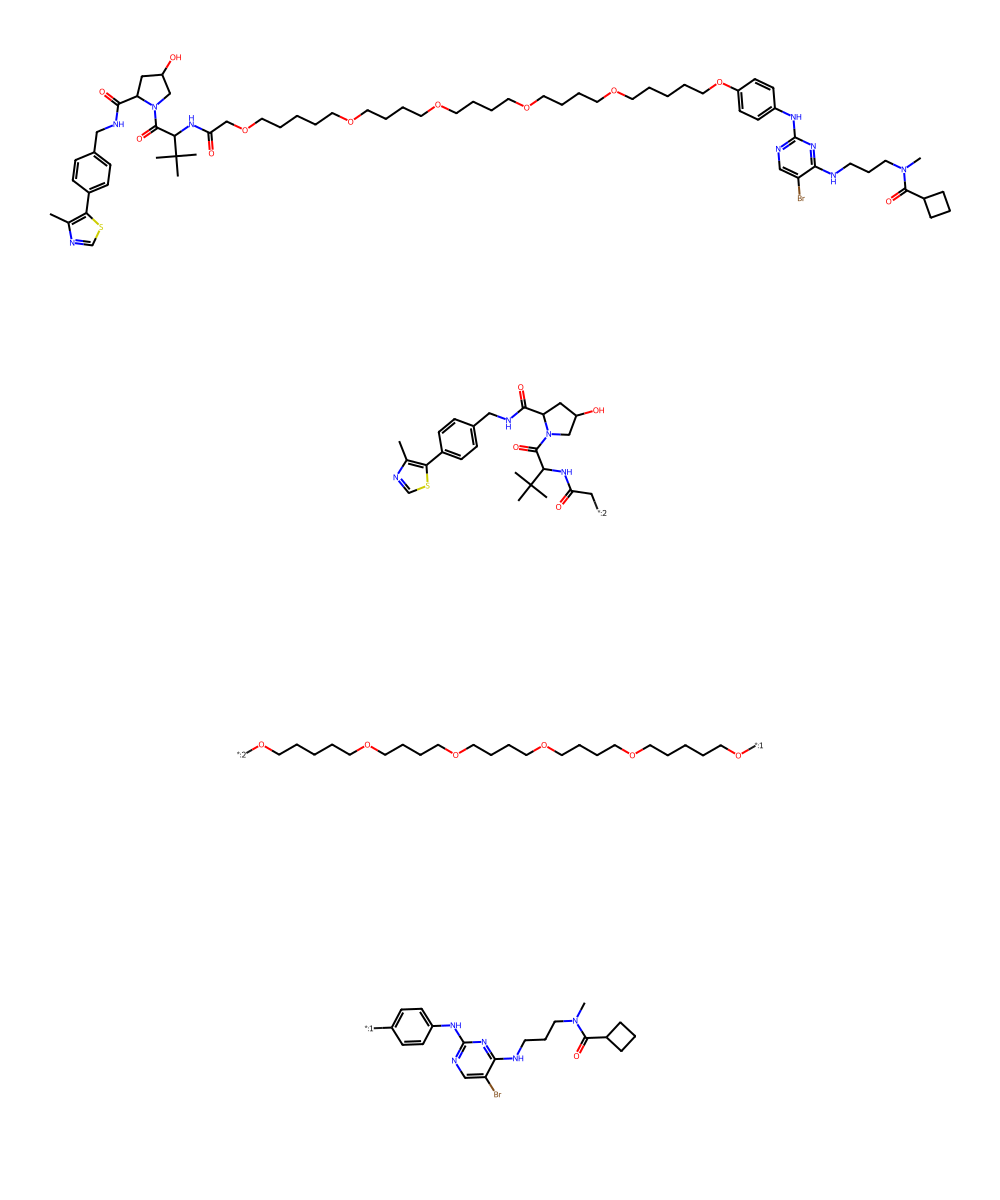

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCCOCCCOc2ccc(Nc3nccc(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2nccc(NCCCN(C)C(=O)C3CCC3)n2)cc1


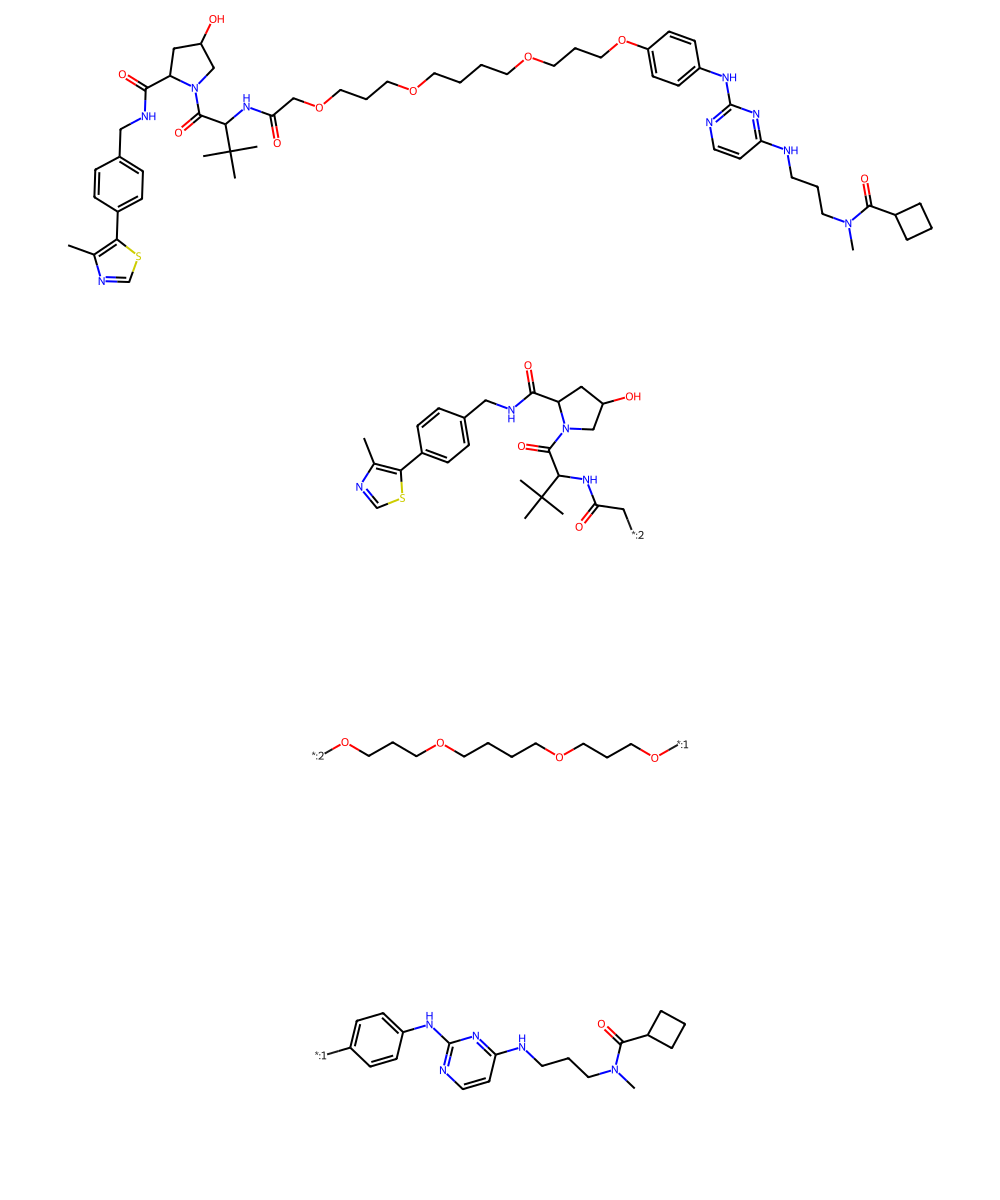

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCCOCCCOc2ccc(Nc3ncc(F)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(F)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


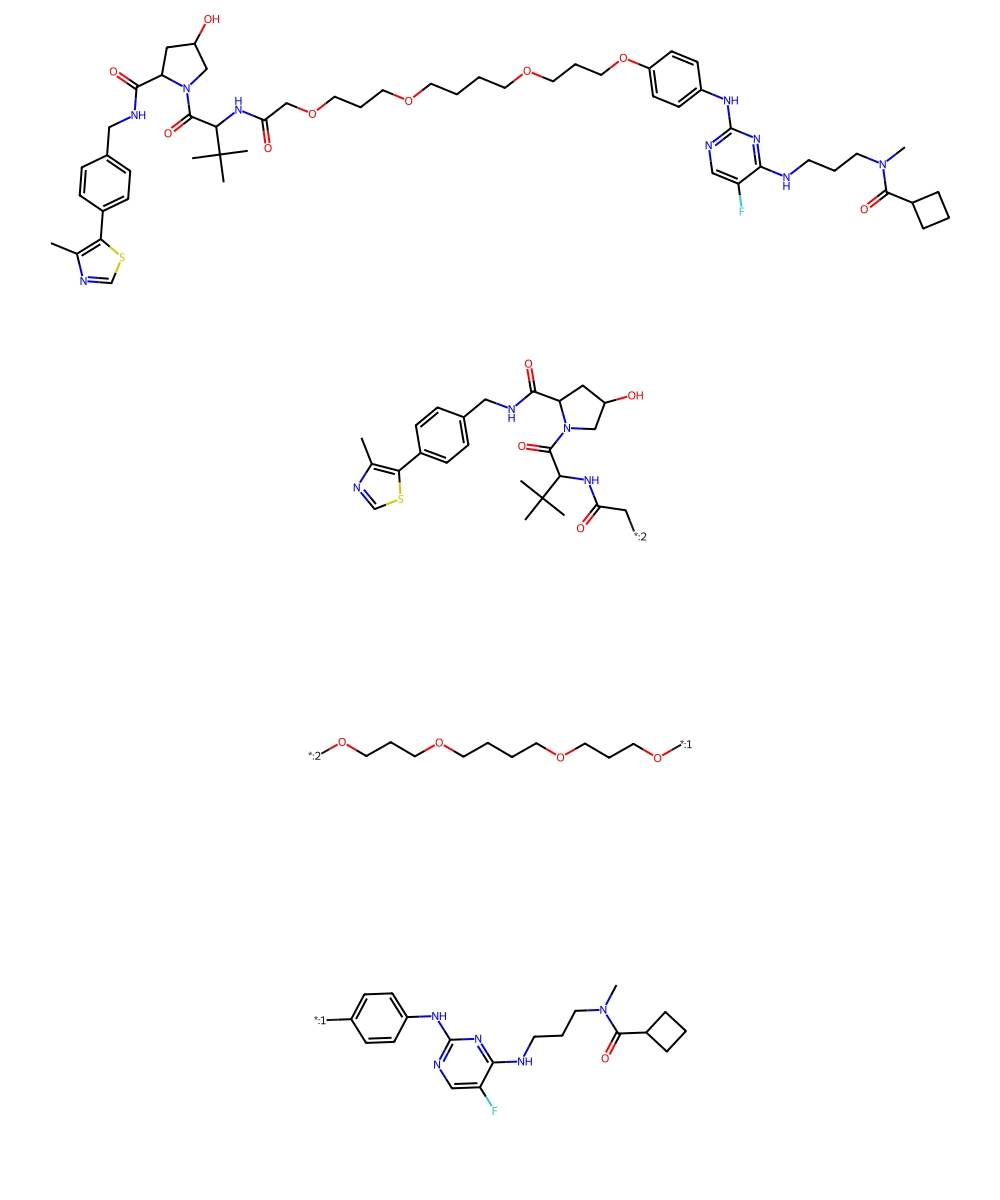

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCCOCCCOc2ccc(Nc3ncc(Cl)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(Cl)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


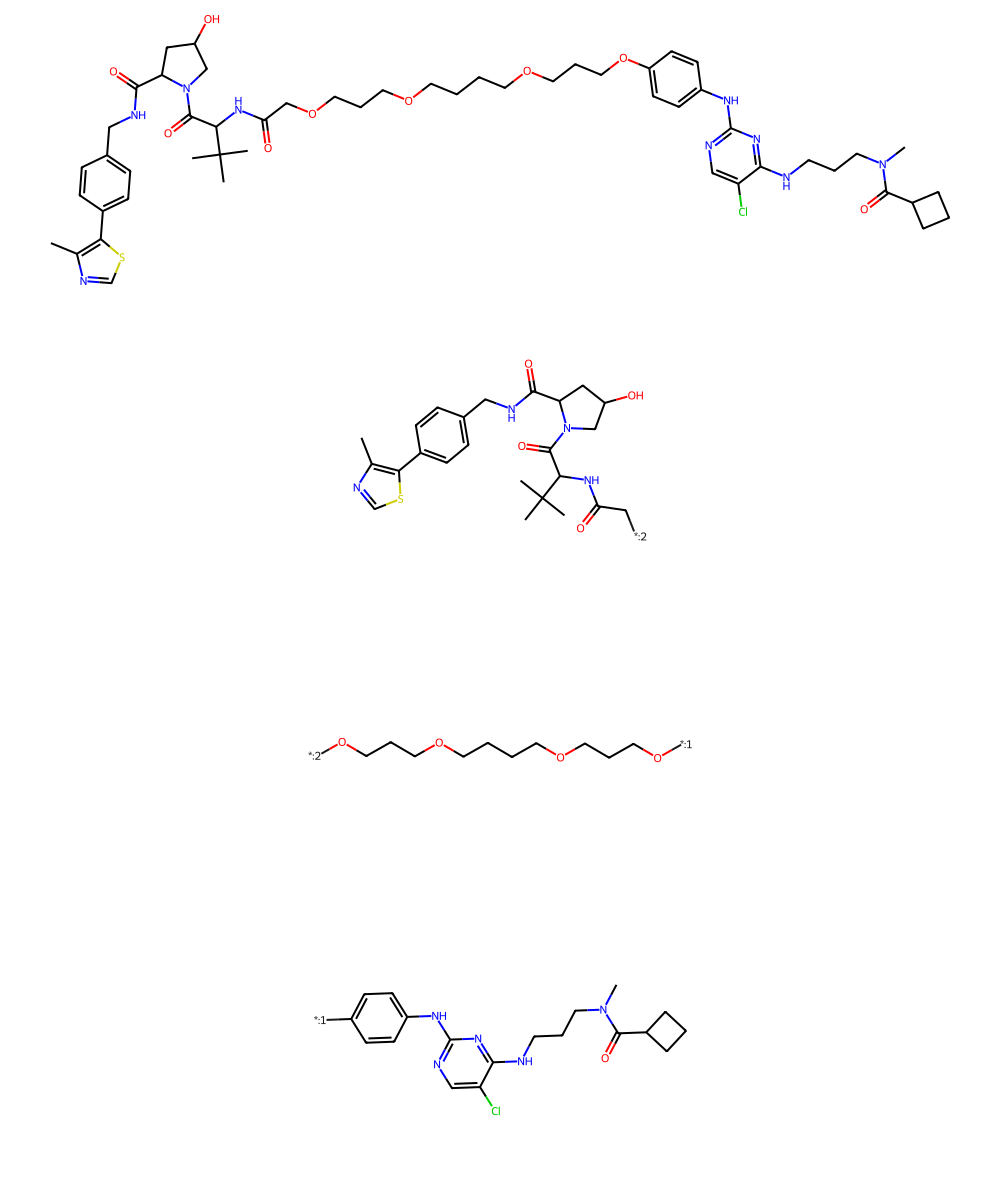

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCCOCCCOc2ccc(Nc3ncc(I)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(I)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


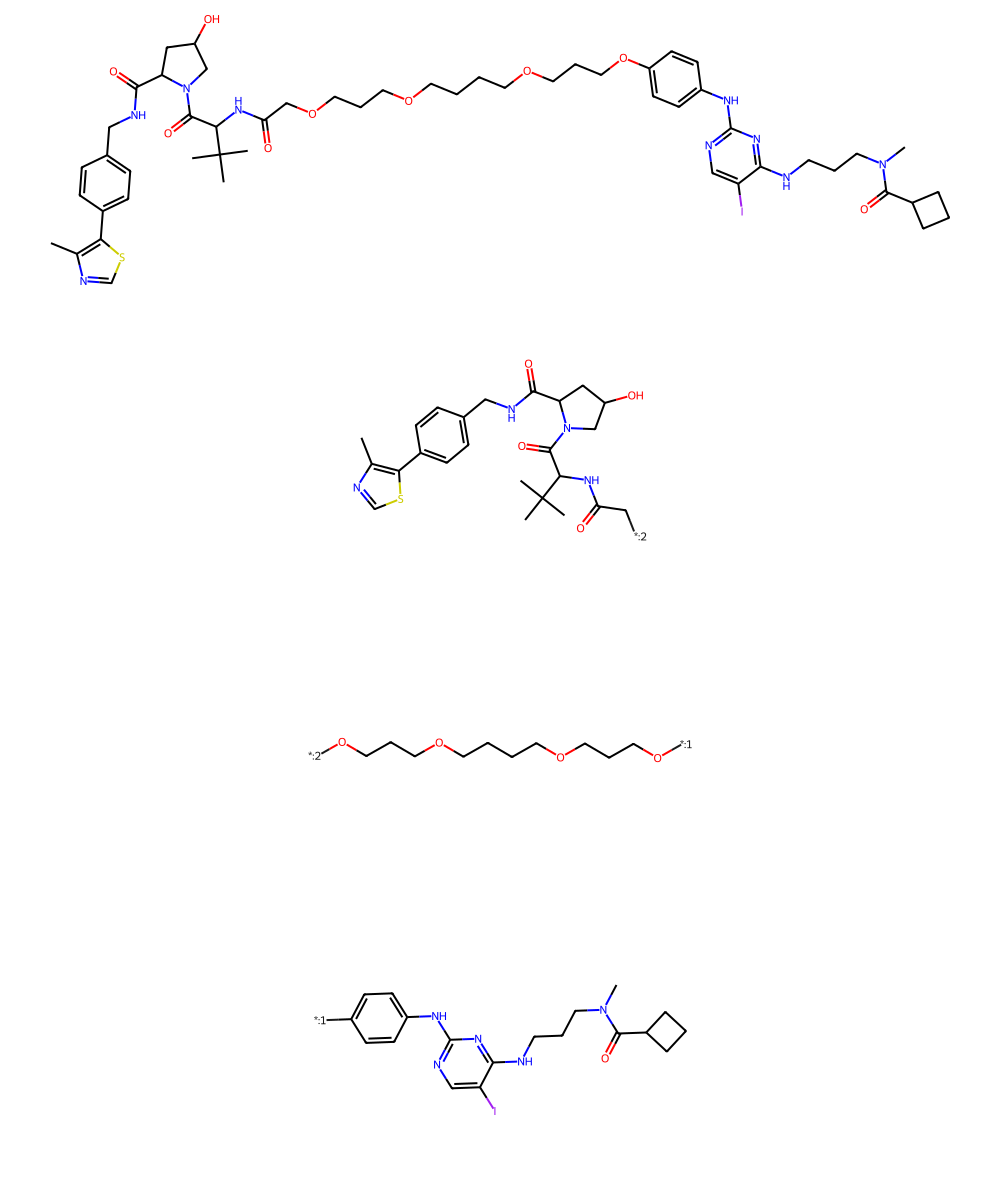

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCCOCCCOc2ccc(Nc3ncc(C(F)(F)F)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(C(F)(F)F)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


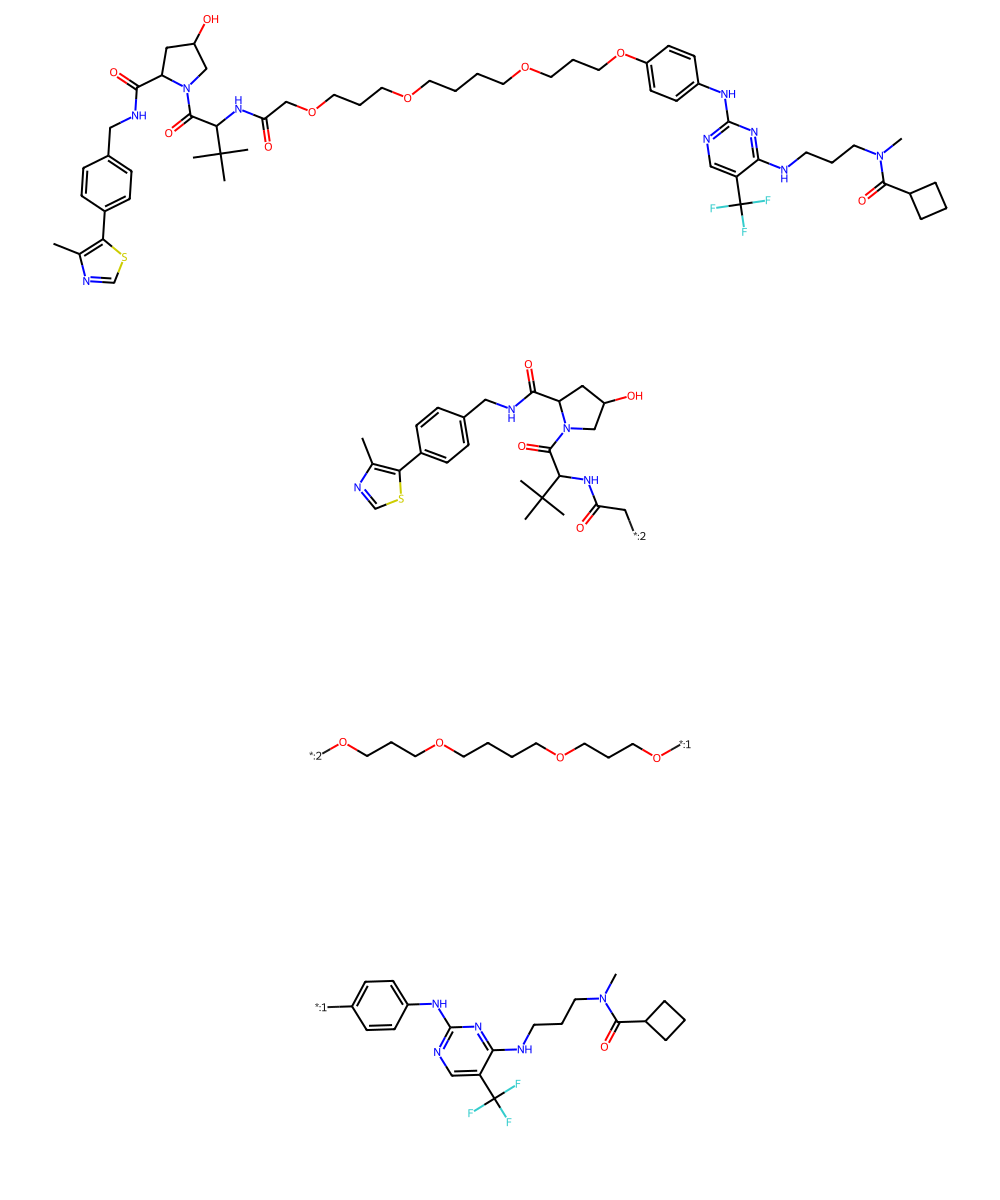

--------------------------------------------------------------------------------
PROTAC: Cc1cnc(Nc2ccc(OCCCOCCCCOCCCOCC(=O)NC(C(=O)N3CC(O)CC3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)cc2)nc1NCCCN(C)C(=O)C1CCC1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(C)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


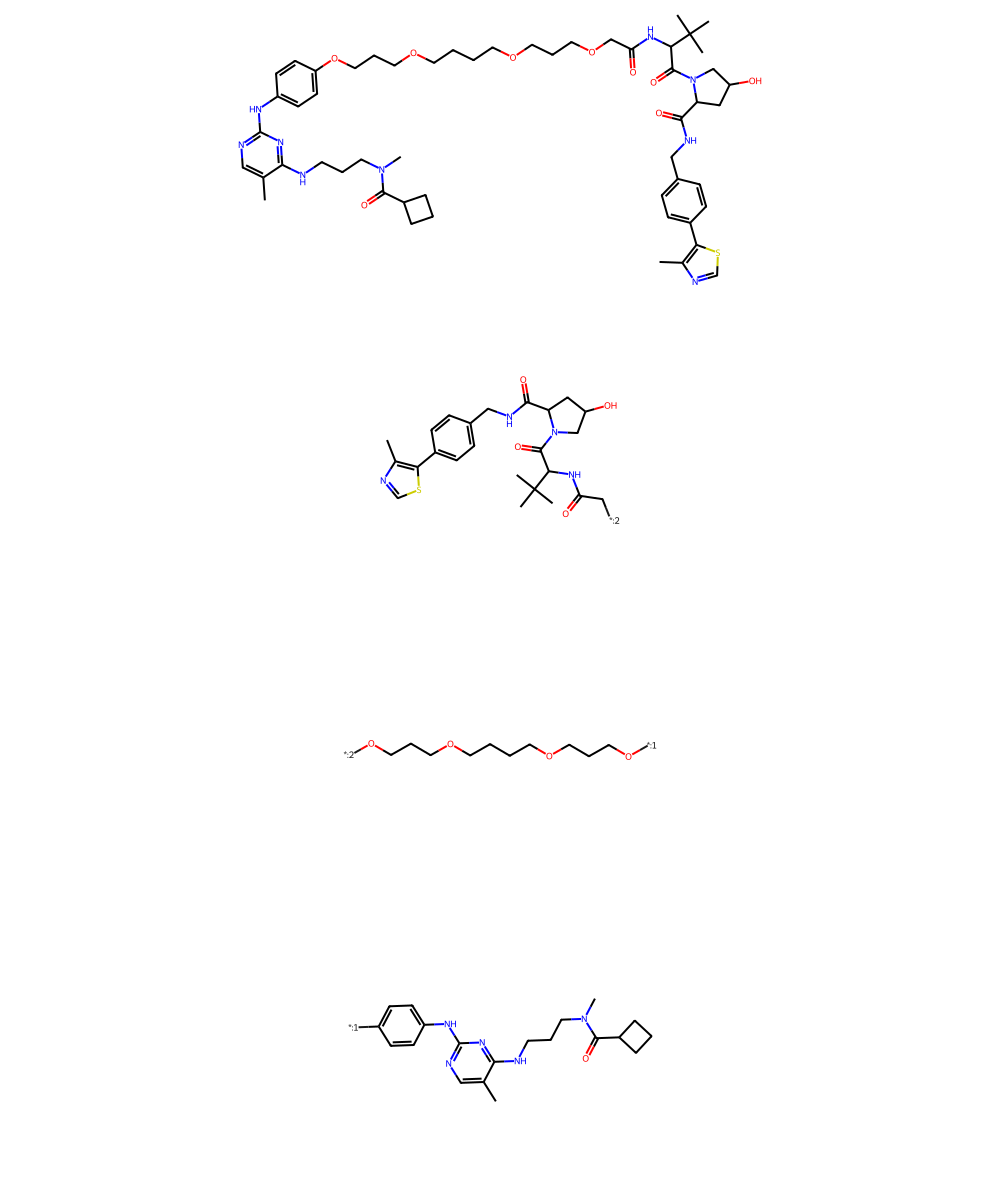

--------------------------------------------------------------------------------
PROTAC: CCc1cnc(Nc2ccc(OCCCOCCCCOCCCOCC(=O)NC(C(=O)N3CC(O)CC3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)cc2)nc1NCCCN(C)C(=O)C1CCC1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(CC)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


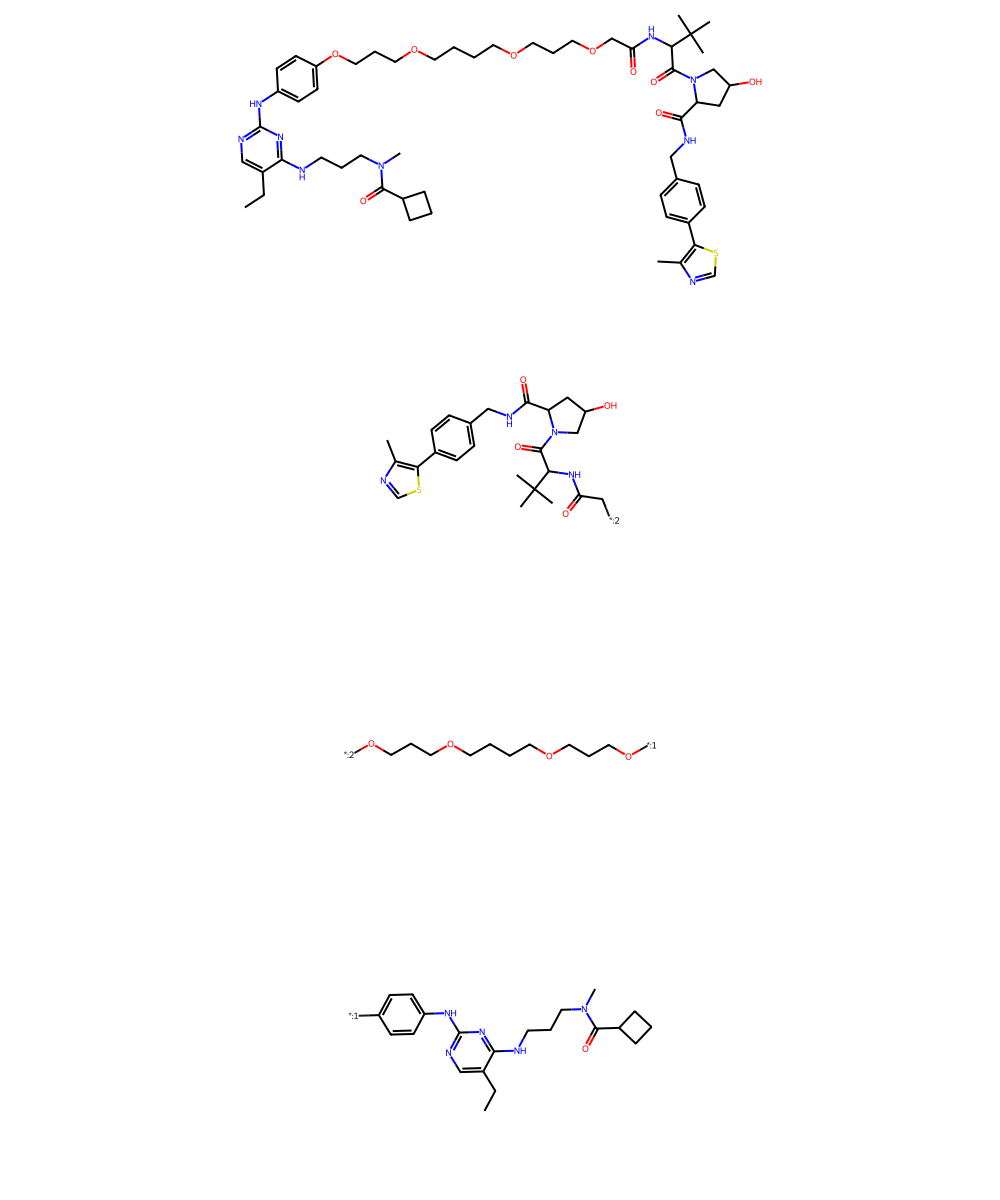

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCCOCCCCOCCCOc2ccc(Nc3ncc(C4CCC4)c(NCCCN(C)C(=O)C4CCC4)n3)cc2)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(C3CCC3)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


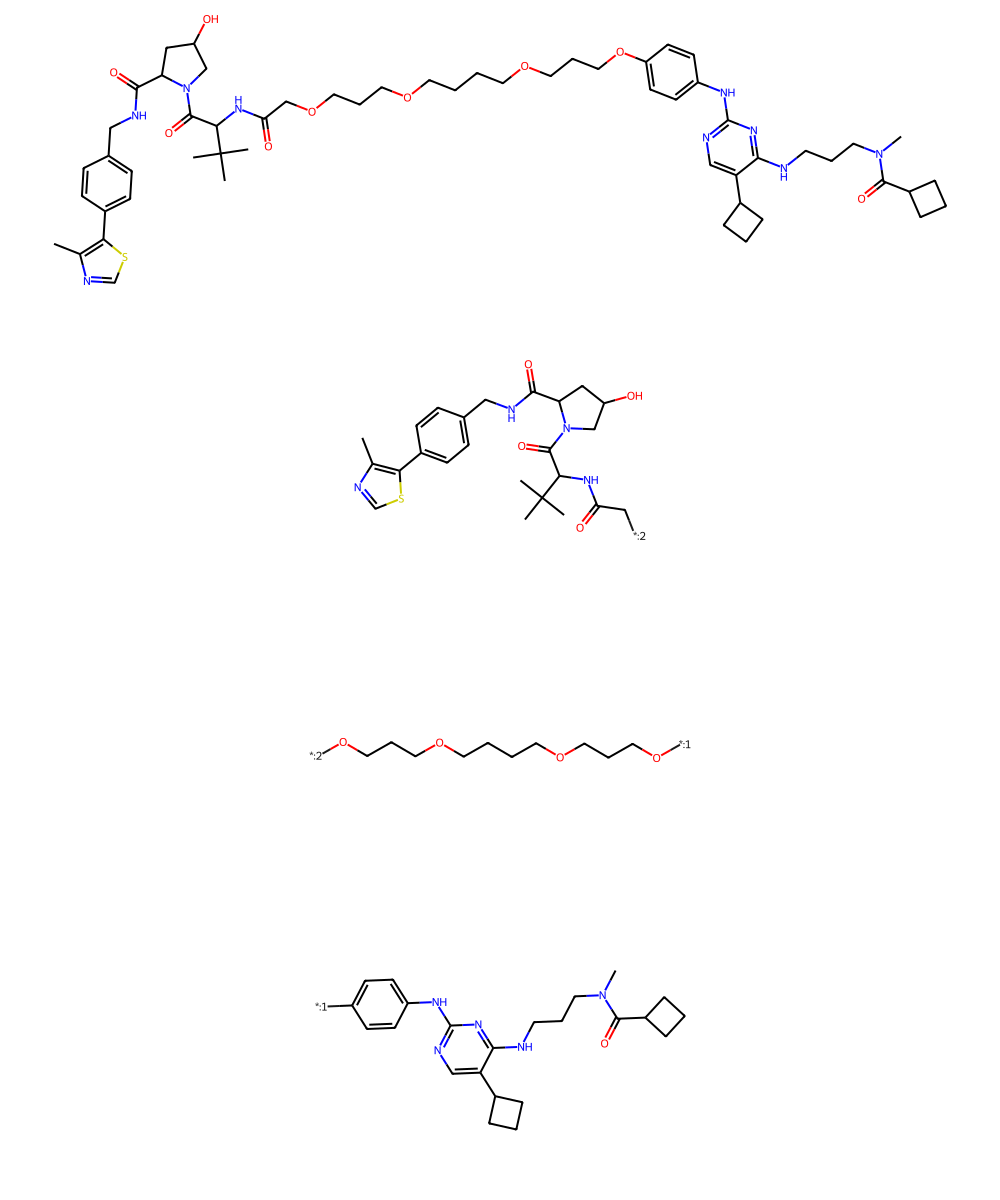

--------------------------------------------------------------------------------
PROTAC: C=Cc1cnc(Nc2ccc(OCCCOCCCCOCCCOCC(=O)NC(C(=O)N3CC(O)CC3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)cc2)nc1NCCCN(C)C(=O)C1CCC1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCCOCCCCOCCCO[*:1]
POI:    [*:1]c1ccc(Nc2ncc(C=C)c(NCCCN(C)C(=O)C3CCC3)n2)cc1


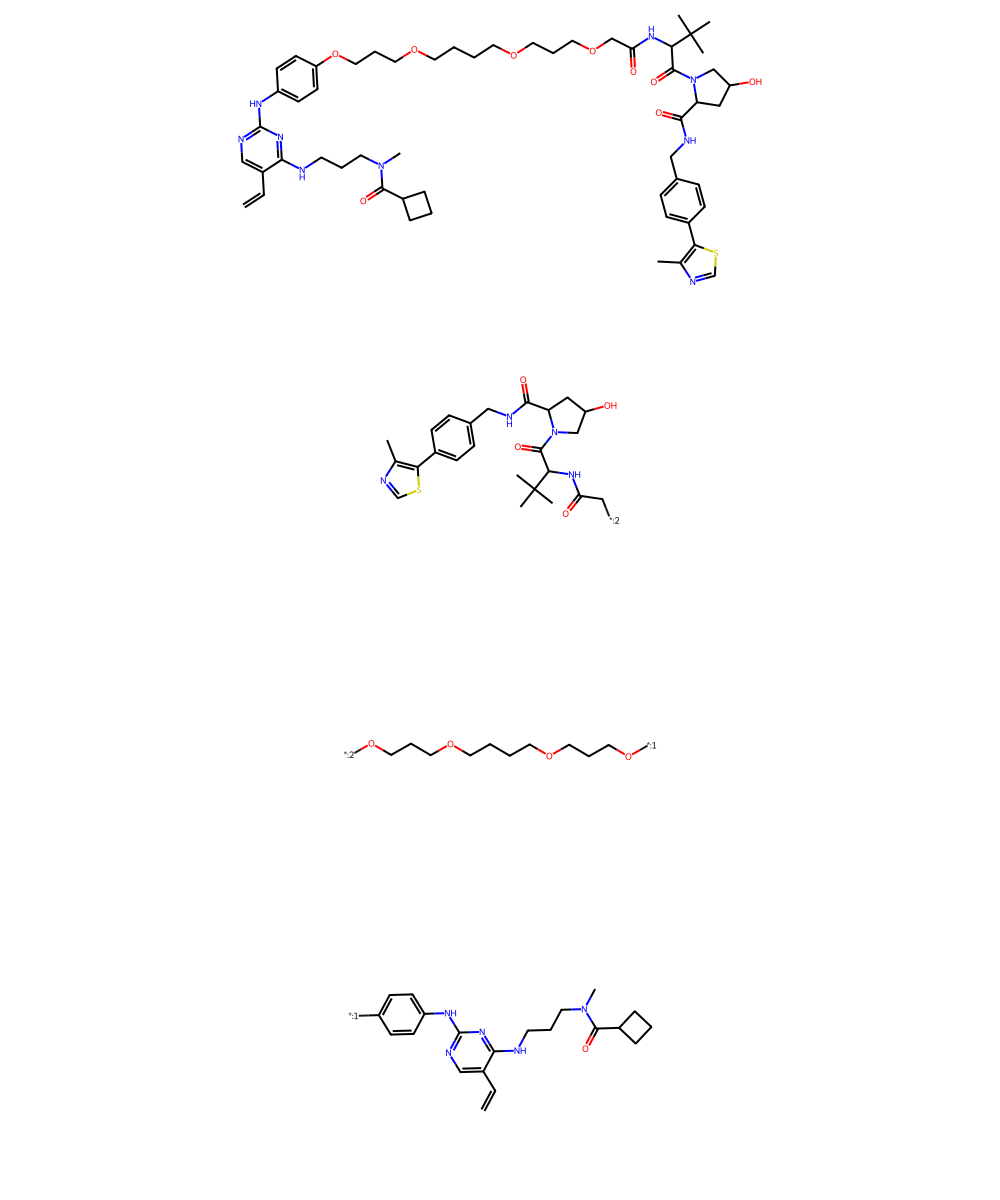

--------------------------------------------------------------------------------
PROTAC: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCOc2cc3nccc(Nc4ccc5scnc5c4)c3cc2S(=O)(=O)C(C)(C)C)C(C)(C)C)cc1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCOC[*:1]
POI:    [*:1]COc1cc2nccc(Nc3ccc4scnc4c3)c2cc1S(=O)(=O)C(C)(C)C


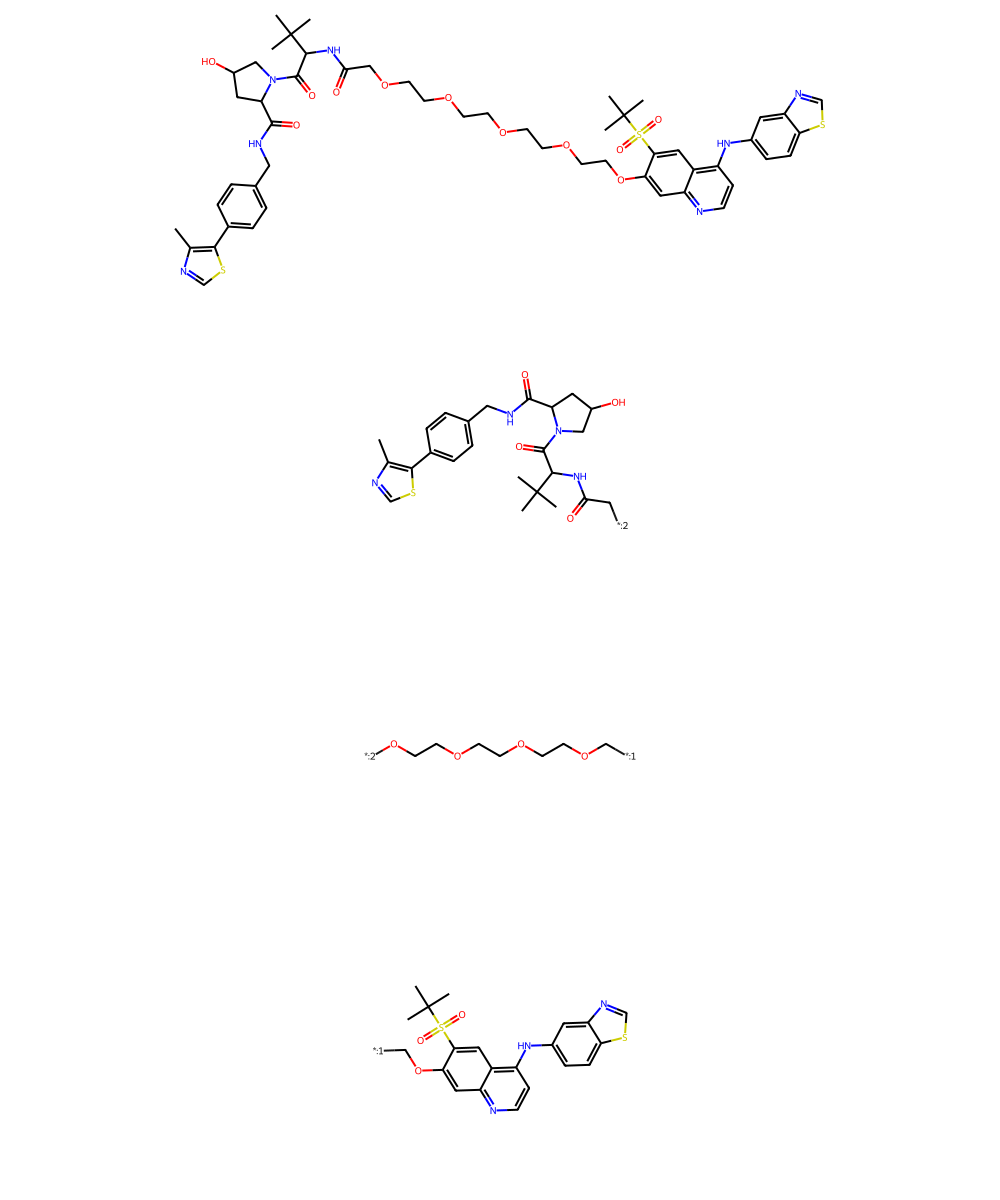

--------------------------------------------------------------------------------
PROTAC: COc1cc(C=C2SC(=O)N(CCOCCC(=O)NC(C(=O)N3CC(O)CC3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)C2=O)ccc1Oc1ccc(C#N)cc1C(F)(F)F
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]COC[*:1]
POI:    [*:1]CN1C(=O)SC(=Cc2ccc(Oc3ccc(C#N)cc3C(F)(F)F)c(OC)c2)C1=O


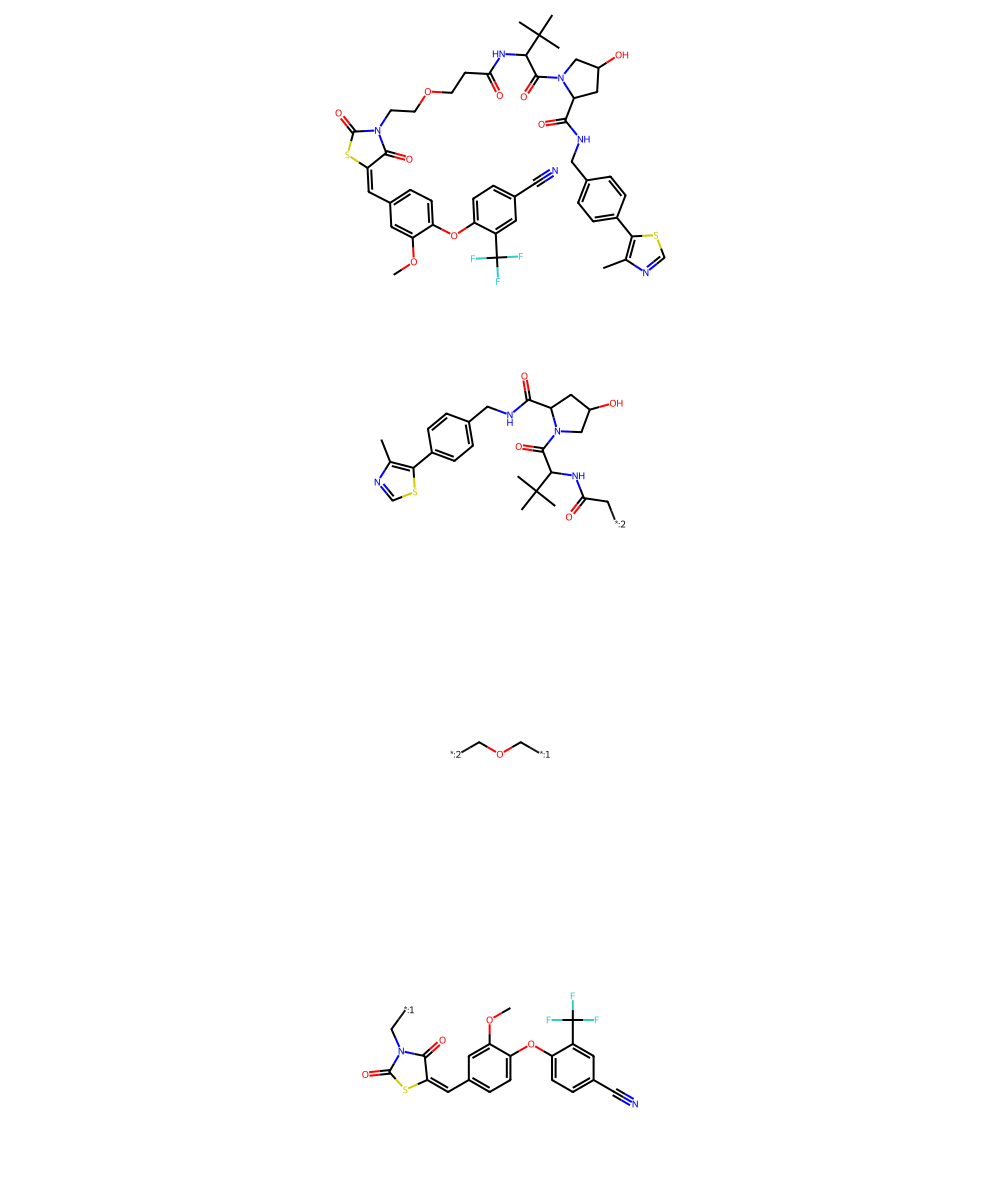

--------------------------------------------------------------------------------
PROTAC: Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=NC(CC(=O)NCCCCNC(=O)COc1cccc3c1C(=O)N(C1CCC(=O)NC1=O)C3=O)c1nnc(C)n1-2
E3:     [*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]OCC(=O)NCCCC[*:1]
POI:    [*:1]NC(=O)CC1N=C(c2ccc(Cl)cc2)c2c(sc(C)c2C)-n2c(C)nnc21


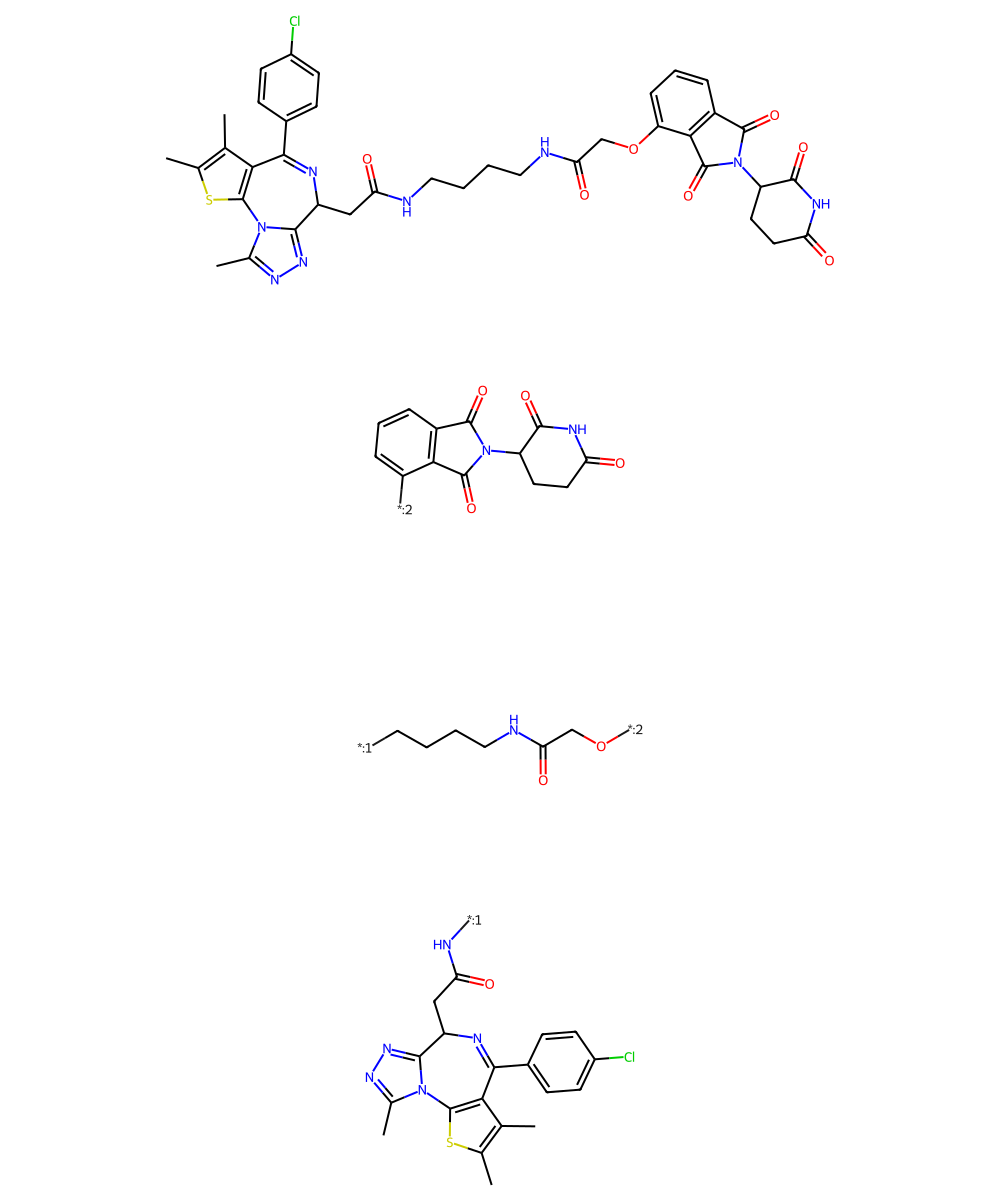

--------------------------------------------------------------------------------
PROTAC: CCC(C)(C)C(=O)C(=O)N1CCCCC1C(=O)OC(CCc1ccc(OC)c(OC)c1)c1cccc(NC(=O)CCC(=O)NCCCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)c1
E3:     [*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]OCC(=O)NCCCCNC(=O)CCC(=O)[*:1]
POI:    [*:1]Nc1cccc(C(CCc2ccc(OC)c(OC)c2)OC(=O)C2CCCCN2C(=O)C(=O)C(C)(C)CC)c1


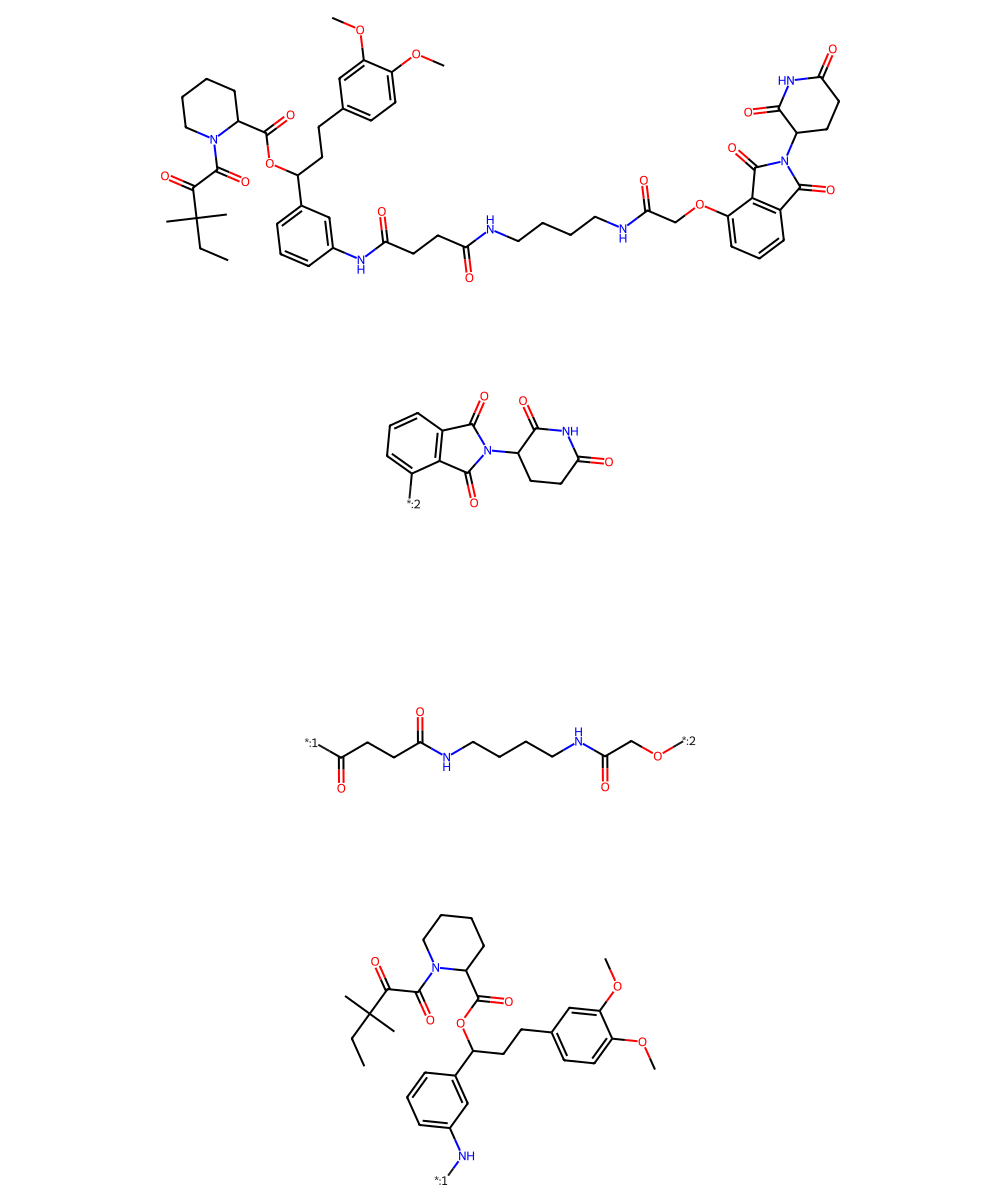

--------------------------------------------------------------------------------
PROTAC: CCC(C)(C)C(=O)C(=O)N1CCCCC1C(=O)OC(CCc1ccc(OC)c(OC)c1)c1cccc(NC(=O)CCC(=O)NCCCOCCOCCOCCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)c1
E3:     [*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]OCC(=O)NCCCOCCOCCOCCCNC(=O)CCC(=O)[*:1]
POI:    [*:1]Nc1cccc(C(CCc2ccc(OC)c(OC)c2)OC(=O)C2CCCCN2C(=O)C(=O)C(C)(C)CC)c1


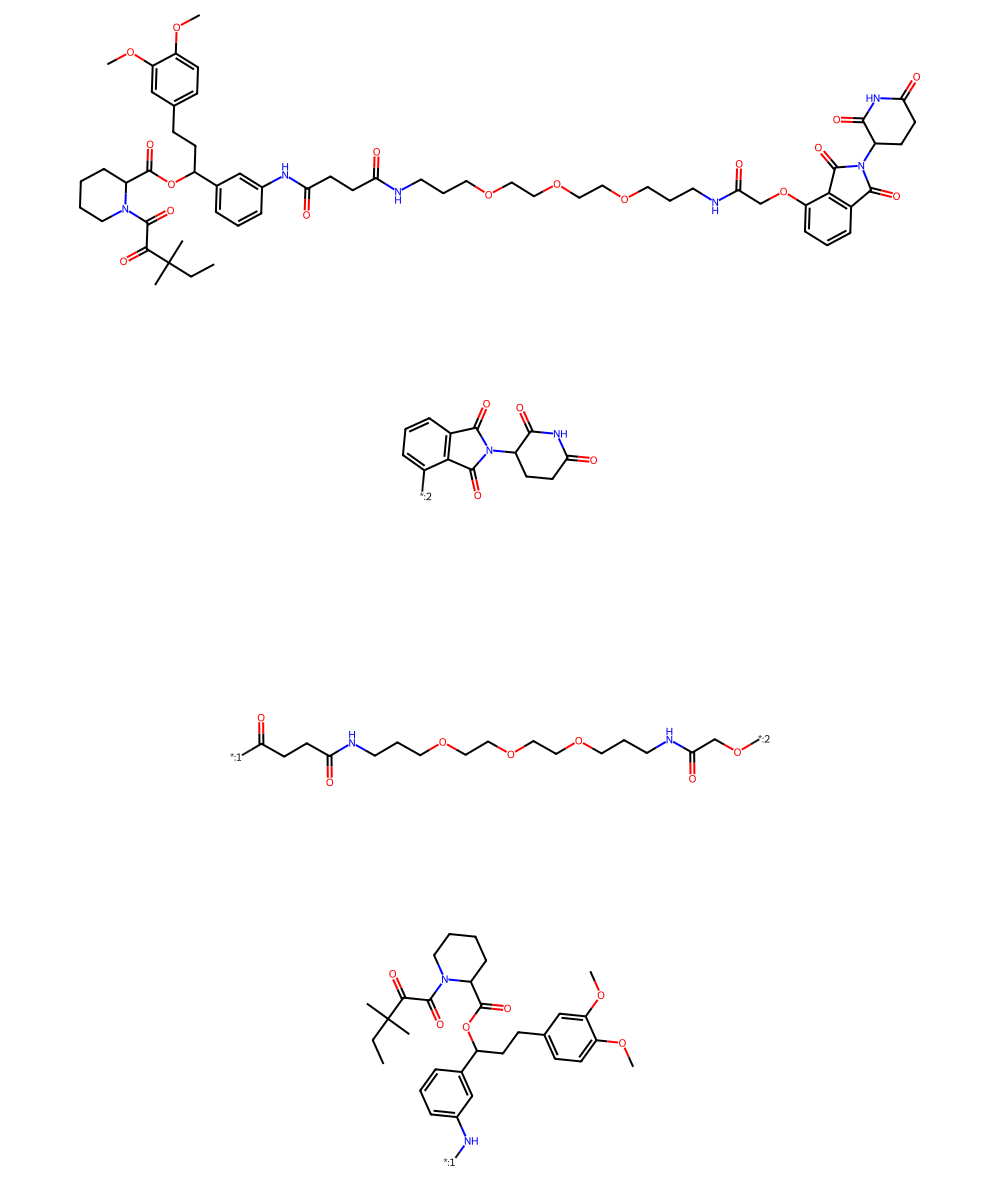

--------------------------------------------------------------------------------
PROTAC: Cc1ccc(NC(=O)c2ccc(CN3CCN(CCCCCCOCCOCCOCCCCCC(=O)NC(C(=O)N4CC(O)CC4C(=O)NCc4ccc(-c5scnc5C)cc4)C(C)(C)C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCOCCOCCOCCCCC[*:1]
POI:    [*:1]CN1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(Nc4nccc(-c5cccnc5)n4)c3)cc2)CC1


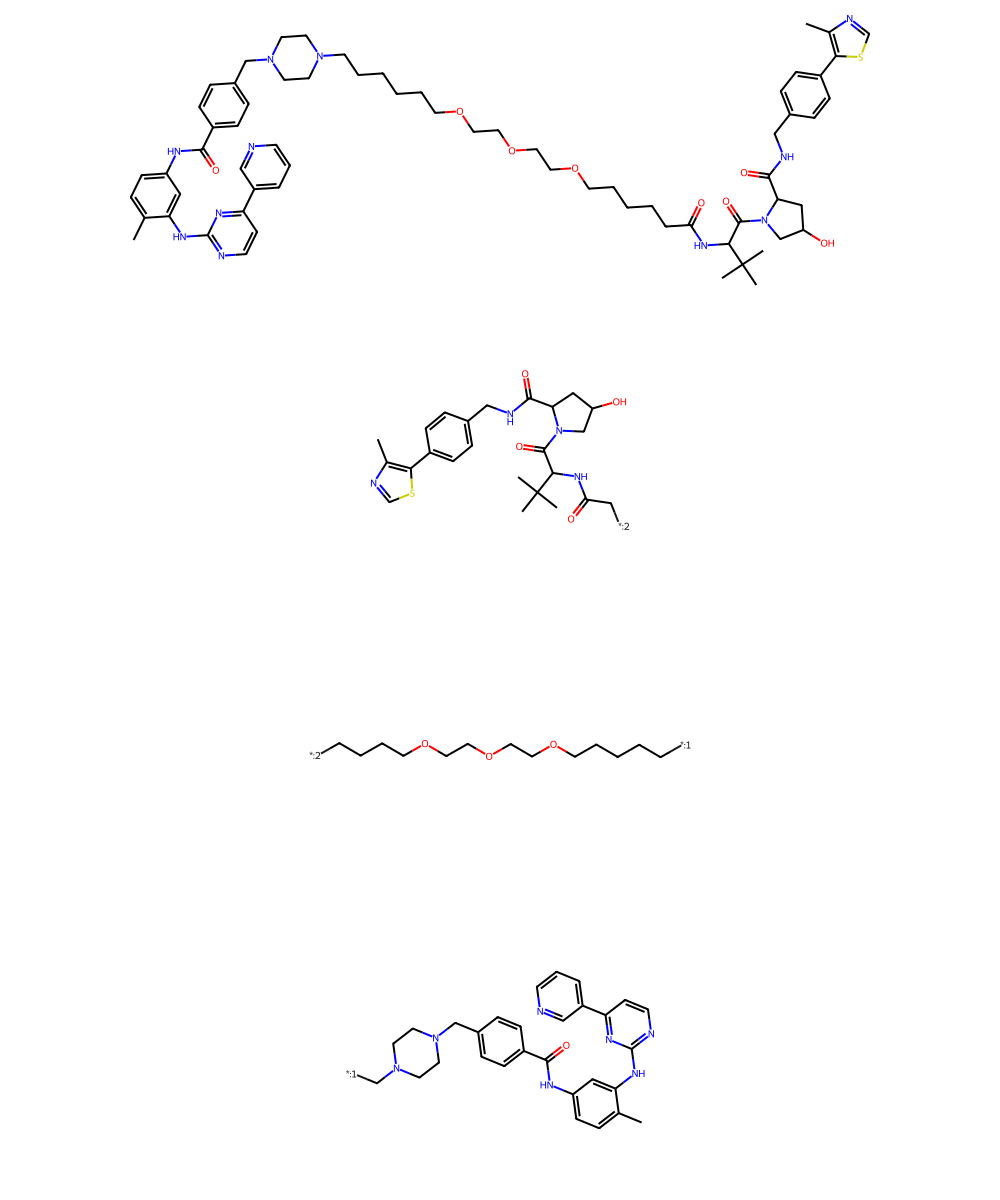

--------------------------------------------------------------------------------
PROTAC: Cc1ccc(NC(=O)c2ccc(CN3CCN(CCCCCCOCCOCC(=O)NC(C(=O)N4CC(O)CC4C(=O)NCc4ccc(-c5scnc5C)cc4)C(C)(C)C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCCCC[*:1]
POI:    [*:1]CN1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(Nc4nccc(-c5cccnc5)n4)c3)cc2)CC1


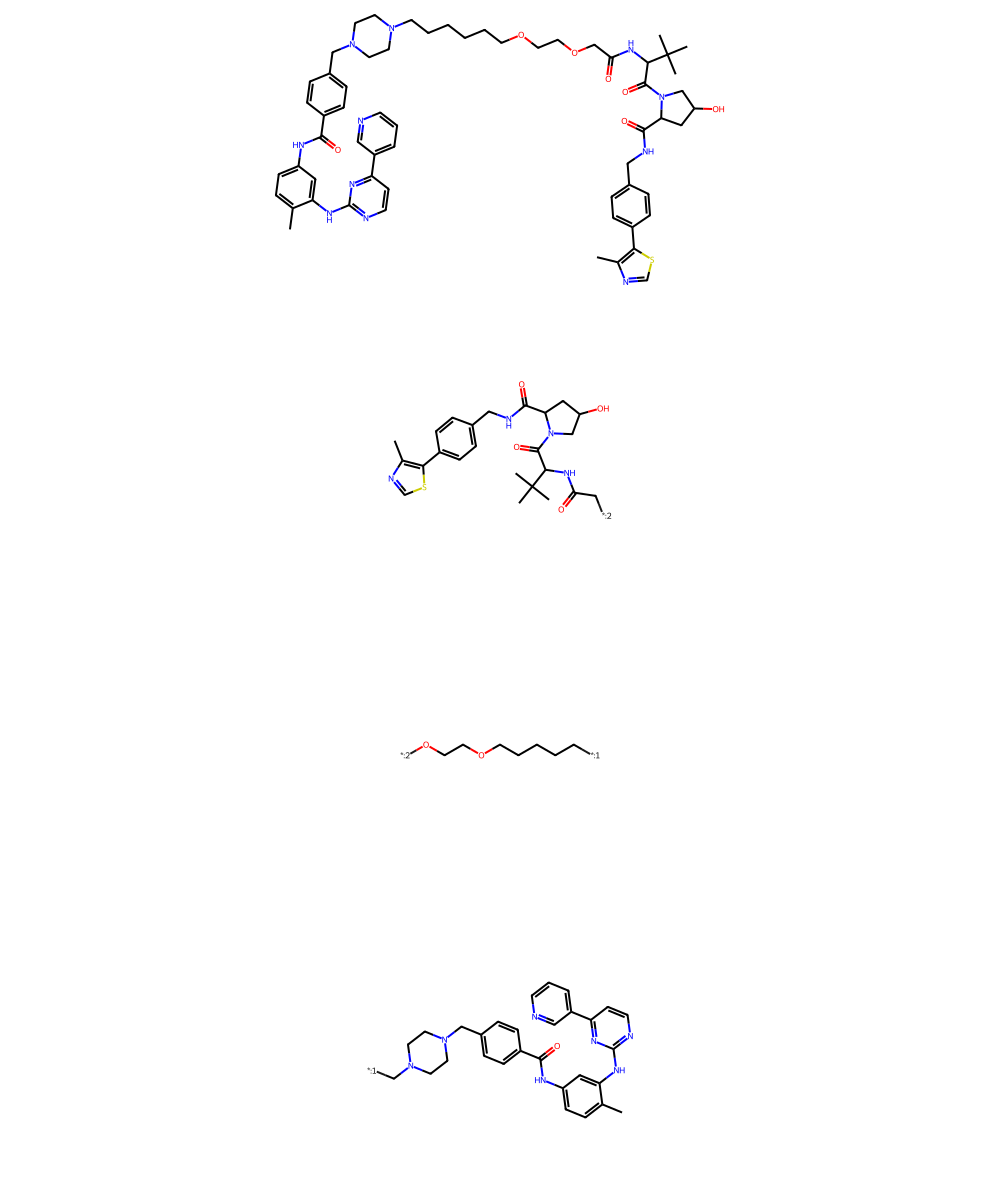

--------------------------------------------------------------------------------
PROTAC: Cc1ccc(NC(=O)c2ccc(CN3CCN(CCCCCCOCCOCCOCCOCCOCCOCC(=O)NC(C(=O)N4CC(O)CC4C(=O)NCc4ccc(-c5scnc5C)cc4)C(C)(C)C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCOCCOCCOCCCCC[*:1]
POI:    [*:1]CN1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(Nc4nccc(-c5cccnc5)n4)c3)cc2)CC1


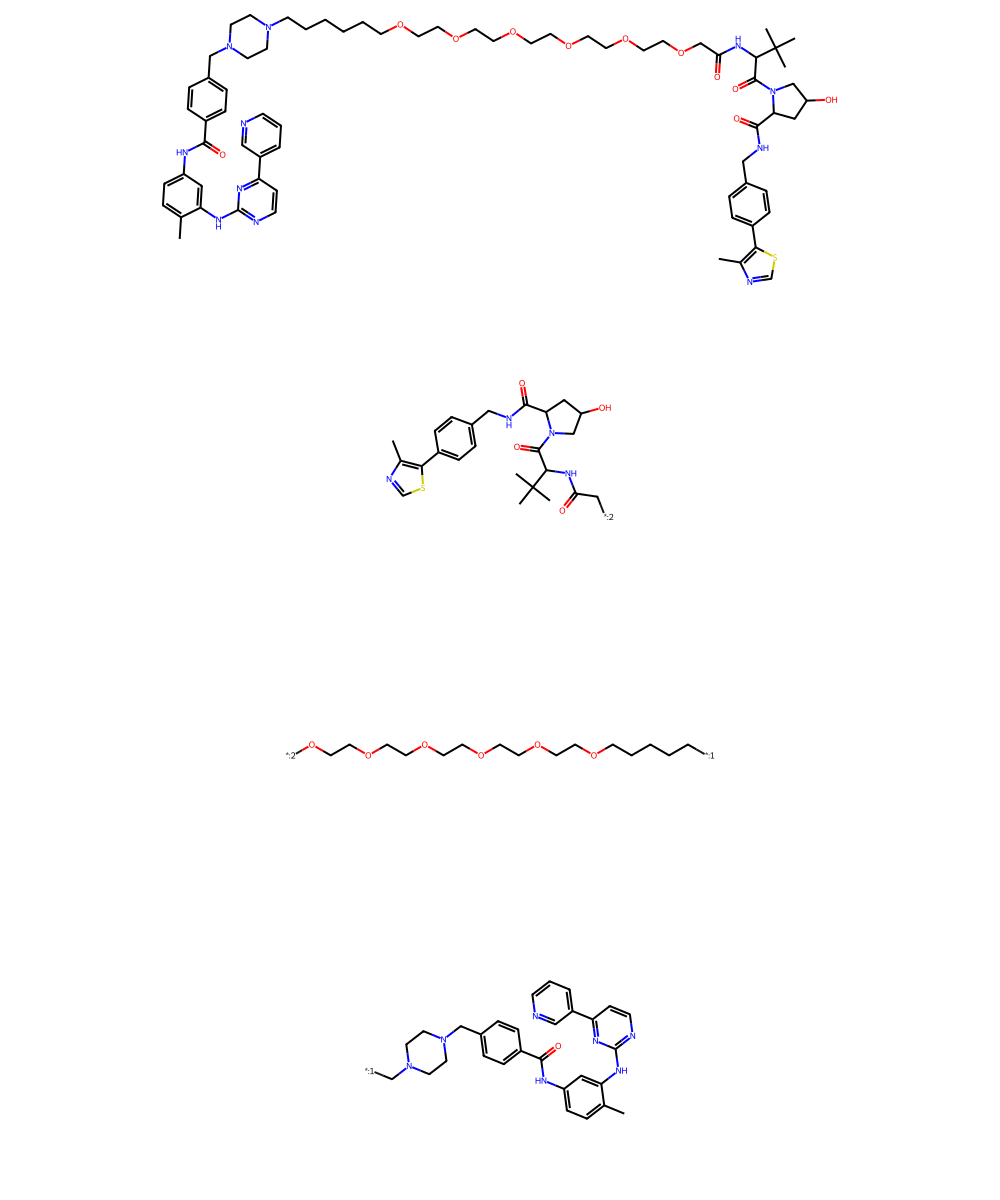

--------------------------------------------------------------------------------
PROTAC: Cc1ccc(NC(=O)c2ccc(CN3CCN(CCCCCCOCCCCCOCCCCCC(=O)NC(C(=O)N4CC(O)CC4C(=O)NCc4ccc(-c5scnc5C)cc4)C(C)(C)C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCOCCCCCOCCCCC[*:1]
POI:    [*:1]CN1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(Nc4nccc(-c5cccnc5)n4)c3)cc2)CC1


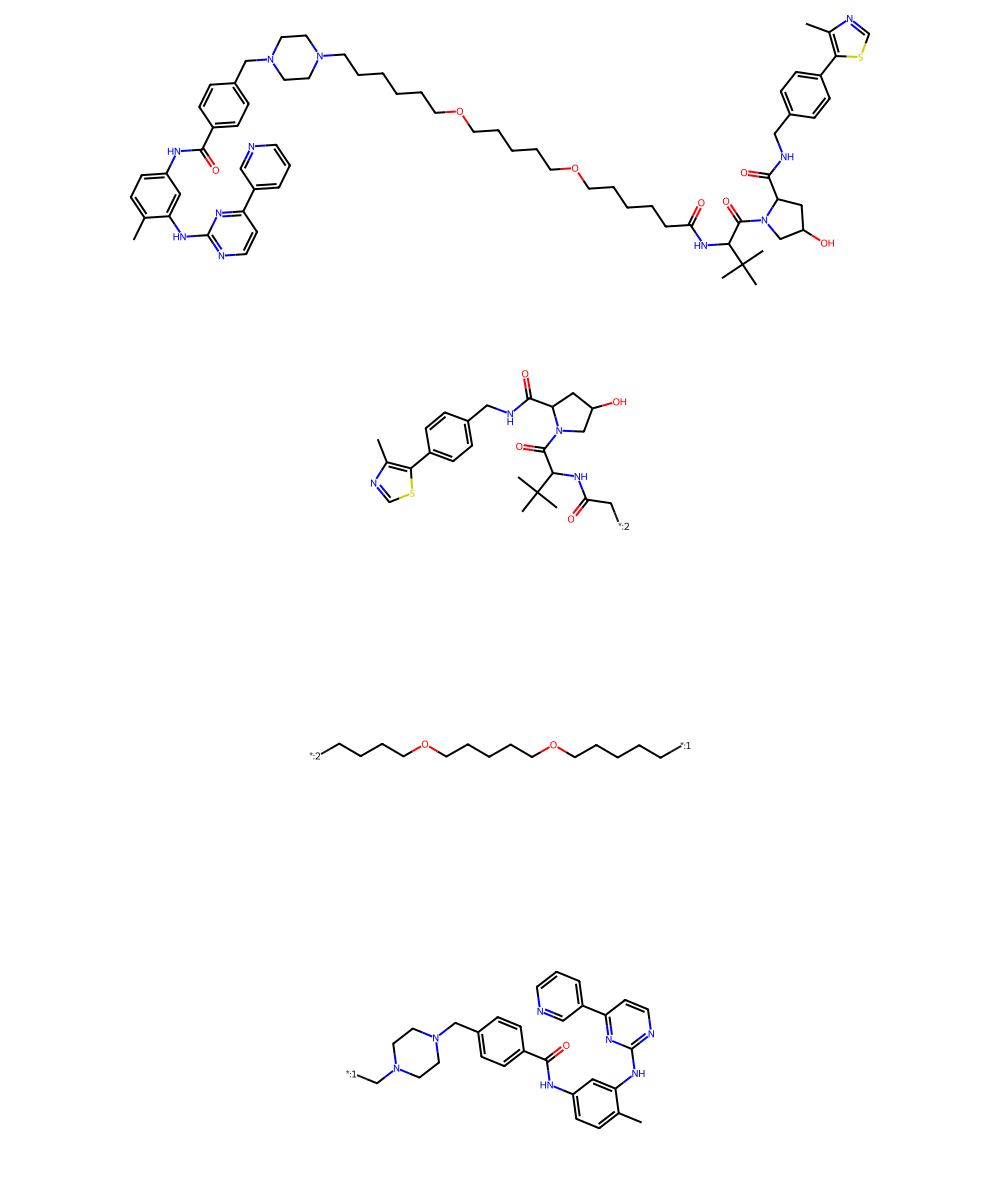

--------------------------------------------------------------------------------
PROTAC: COc1cc(Nc2c(C#N)cnc3cc(OCCCN4CCN(CCCCCCOCCOCCOCCCCCC(=O)NC(C(=O)N5CC(O)CC5C(=O)NCc5ccc(-c6scnc6C)cc5)C(C)(C)C)CC4)c(OC)cc23)c(Cl)cc1Cl
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCOCCOCCOCCCCC[*:1]
POI:    [*:1]CN1CCN(CCCOc2cc3ncc(C#N)c(Nc4cc(OC)c(Cl)cc4Cl)c3cc2OC)CC1


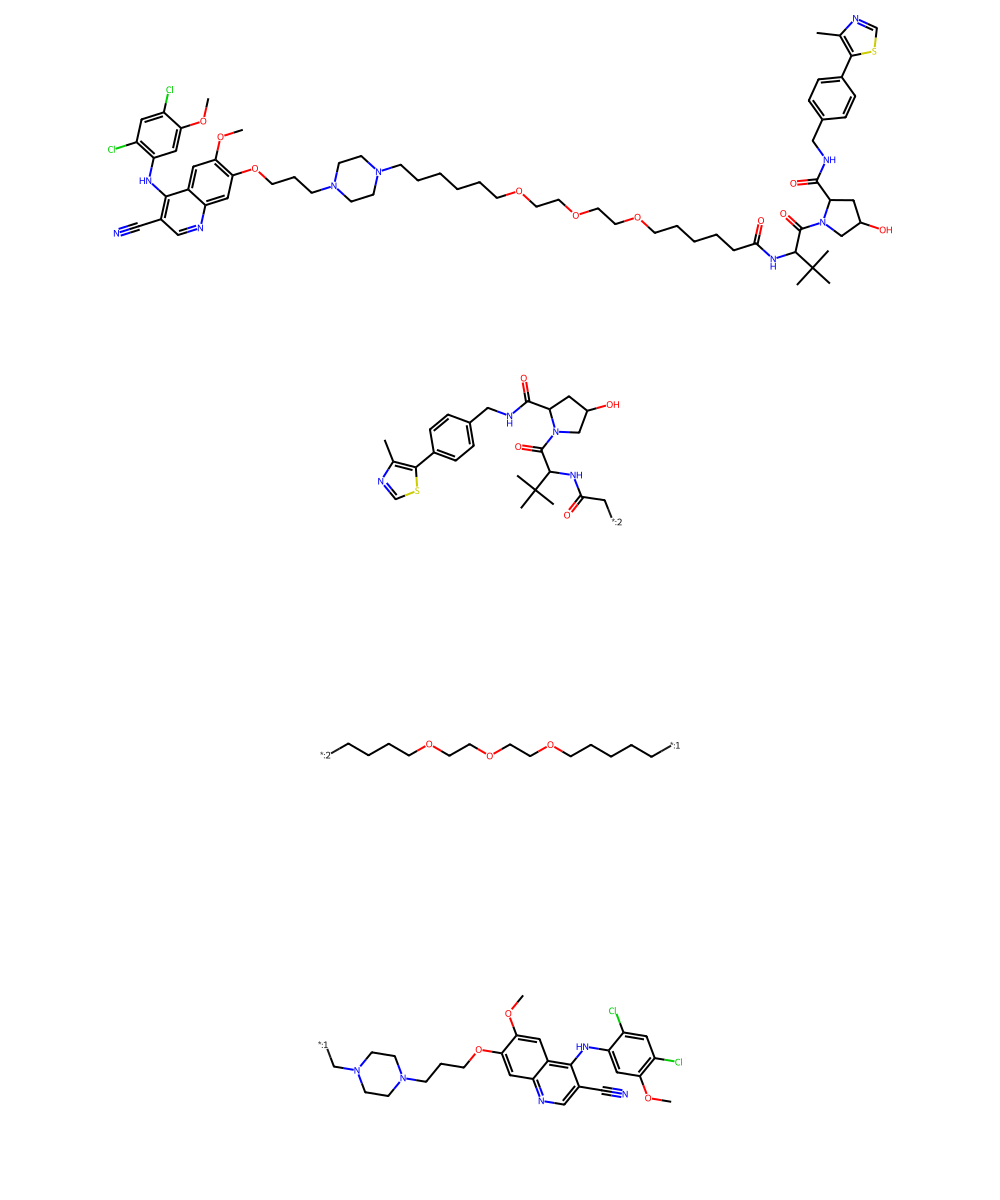

--------------------------------------------------------------------------------
PROTAC: COc1cc(Nc2c(C#N)cnc3cc(OCCCN4CCN(CCCCCCOCCOCC(=O)NC(C(=O)N5CC(O)CC5C(=O)NCc5ccc(-c6scnc6C)cc5)C(C)(C)C)CC4)c(OC)cc23)c(Cl)cc1Cl
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCCCC[*:1]
POI:    [*:1]CN1CCN(CCCOc2cc3ncc(C#N)c(Nc4cc(OC)c(Cl)cc4Cl)c3cc2OC)CC1


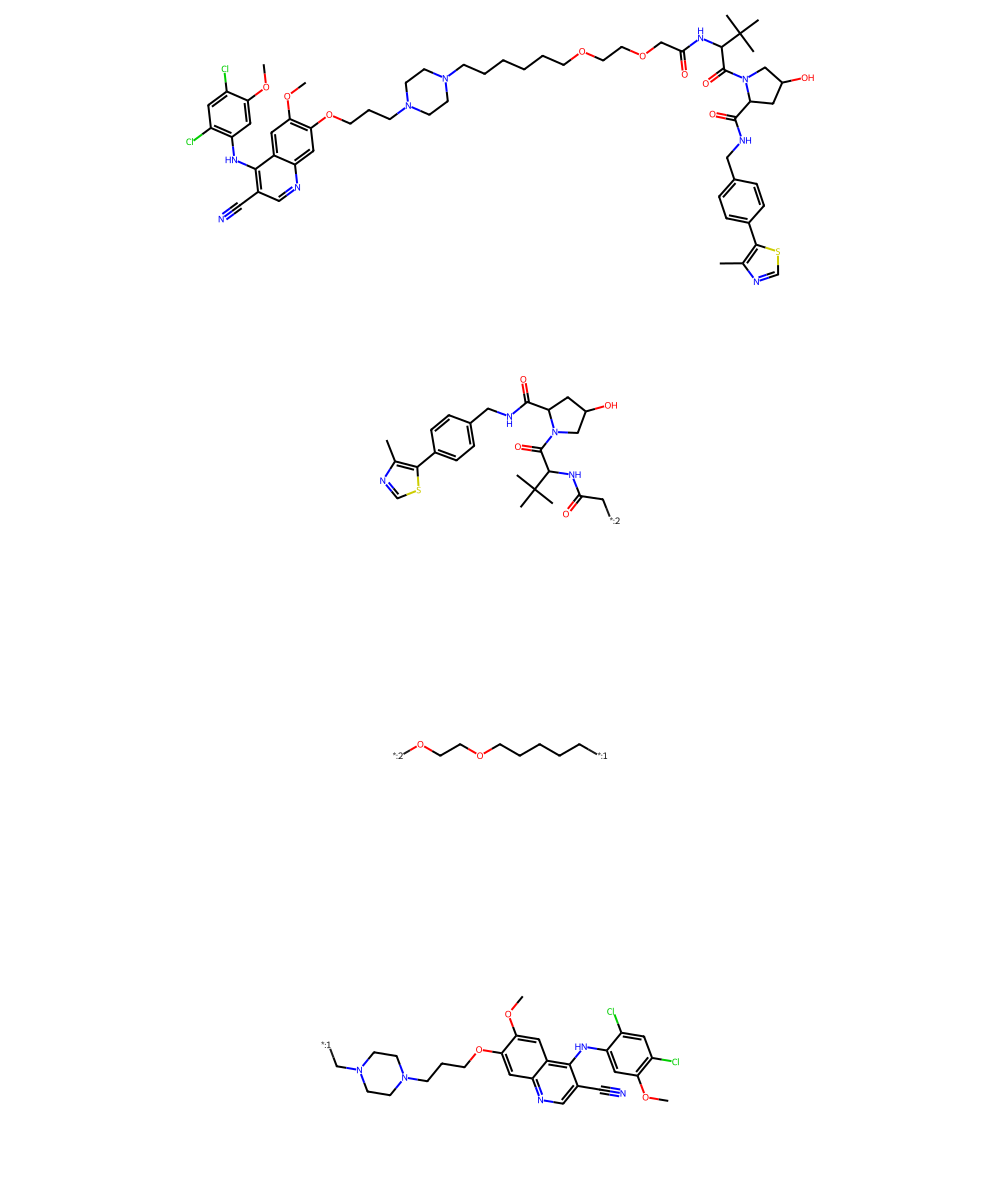

--------------------------------------------------------------------------------
PROTAC: COc1cc(Nc2c(C#N)cnc3cc(OCCCN4CCN(CCCCCCOCCOCCOCCOCCOCCOCC(=O)NC(C(=O)N5CC(O)CC5C(=O)NCc5ccc(-c6scnc6C)cc5)C(C)(C)C)CC4)c(OC)cc23)c(Cl)cc1Cl
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCOCCOCCOCCCCC[*:1]
POI:    [*:1]CN1CCN(CCCOc2cc3ncc(C#N)c(Nc4cc(OC)c(Cl)cc4Cl)c3cc2OC)CC1


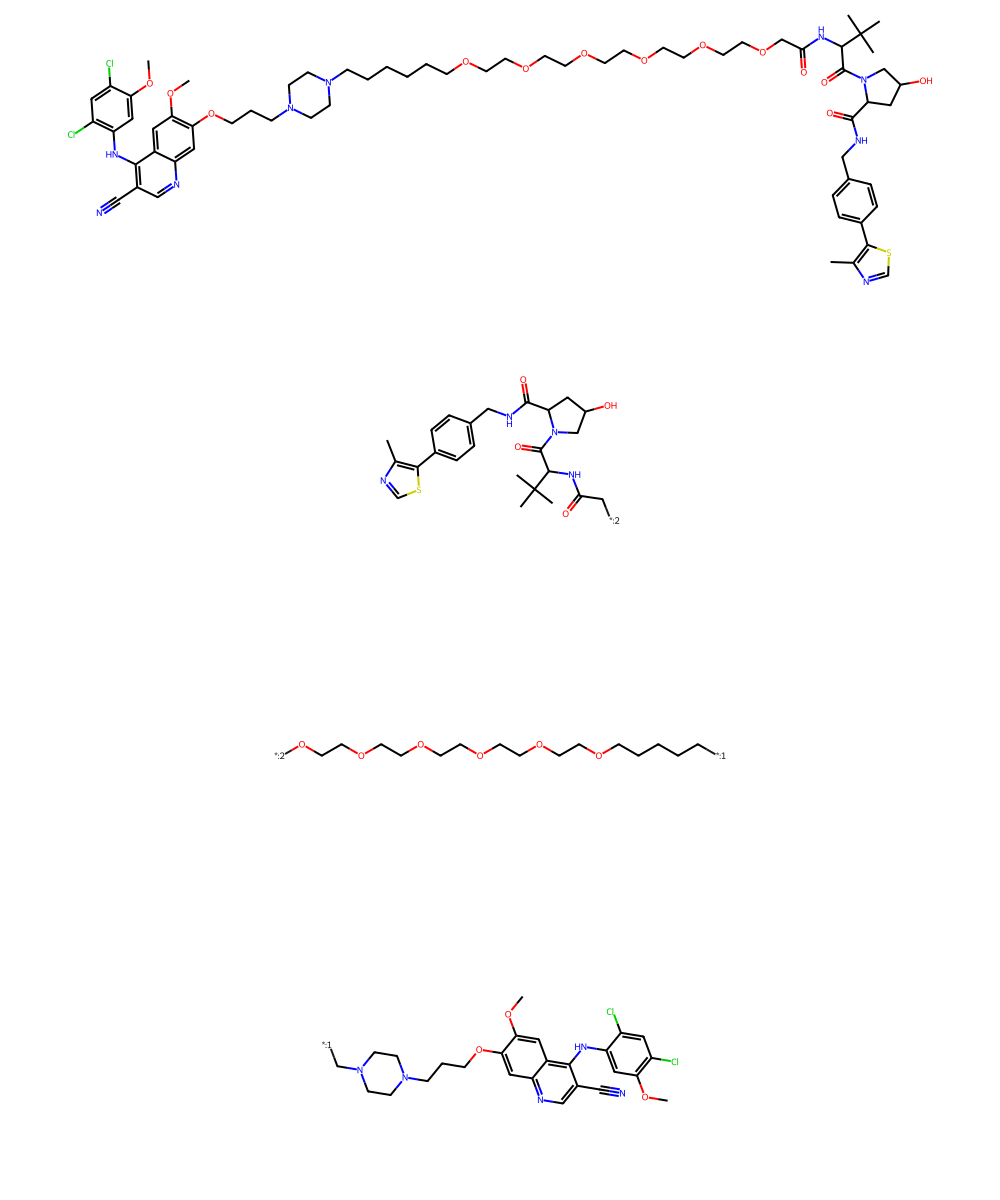

--------------------------------------------------------------------------------
PROTAC: COc1cc(Nc2c(C#N)cnc3cc(OCCCN4CCN(CCCCCCOCCCCCOCCCCCC(=O)NC(C(=O)N5CC(O)CC5C(=O)NCc5ccc(-c6scnc6C)cc5)C(C)(C)C)CC4)c(OC)cc23)c(Cl)cc1Cl
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]CCCCOCCCCCOCCCCC[*:1]
POI:    [*:1]CN1CCN(CCCOc2cc3ncc(C#N)c(Nc4cc(OC)c(Cl)cc4Cl)c3cc2OC)CC1


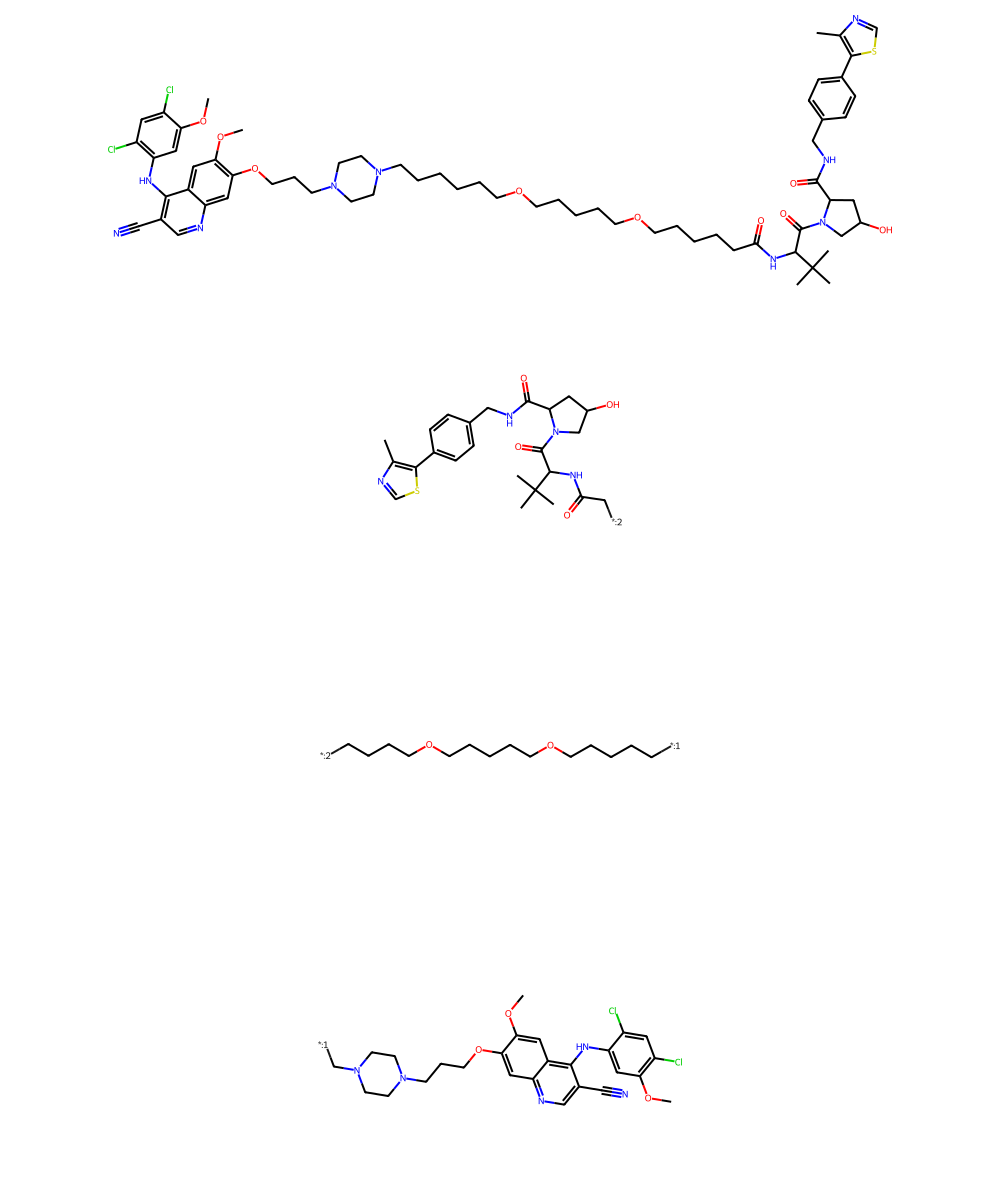

--------------------------------------------------------------------------------
PROTAC: COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN(C)CC(=O)NCCOCCOCCOCC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
E3:     Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C[*:2])C(C)(C)C)cc1
Linker: [*:2]OCCOCCOCCNC(=O)[*:1]
POI:    [*:1]CN(C)Cc1c(OC)cc(-c2cn(C)c(=O)c3cnccc23)cc1OC


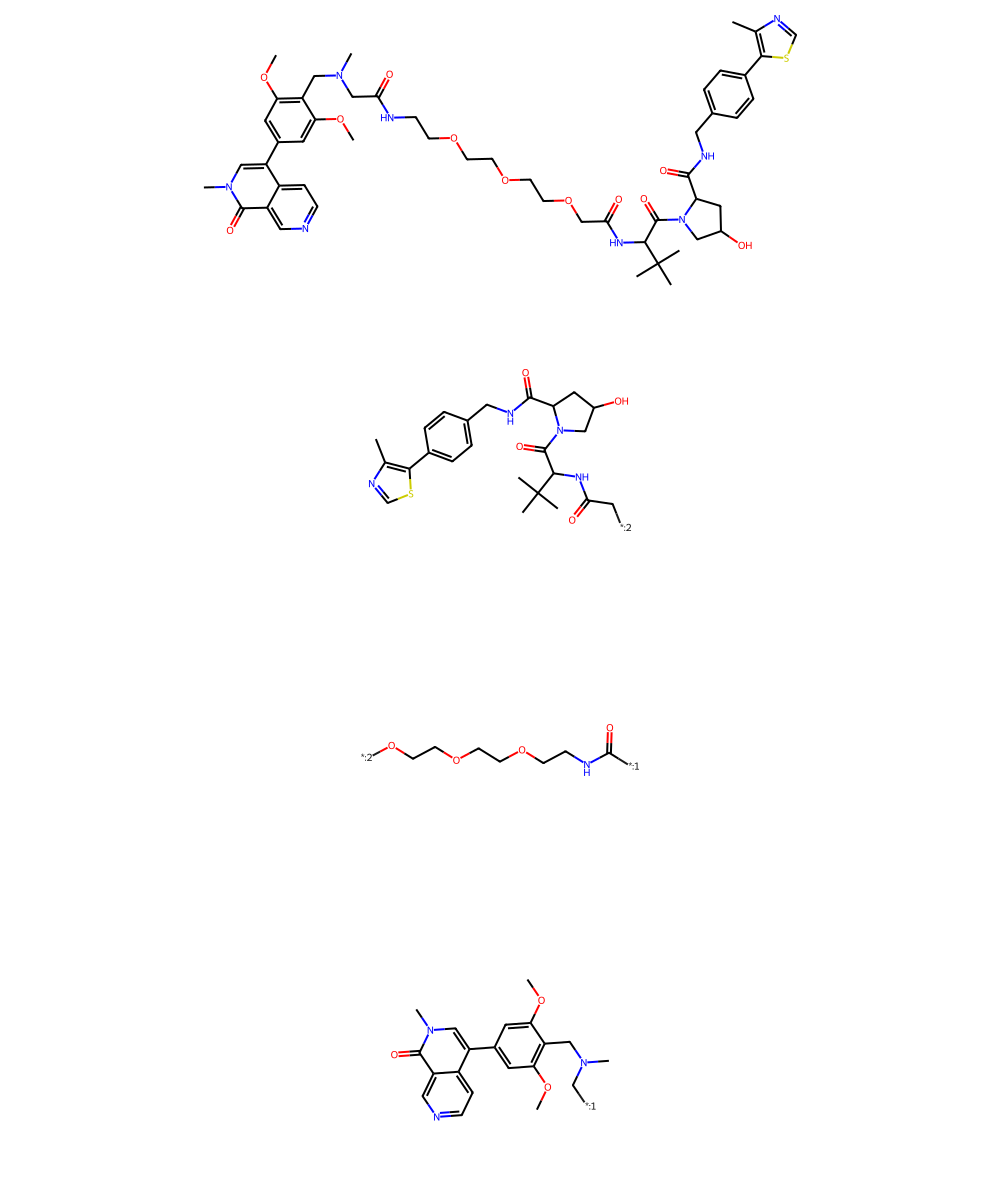

--------------------------------------------------------------------------------
PROTAC: Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=NC(CC(=O)NCCOCCOCCNc1cccc3nnn(C4CCC(=O)NC4=O)c(=O)c13)c1nnc(C)n1-2
E3:     [*:2]Nc1cccc2nnn(C3CCC(=O)NC3=O)c(=O)c12
Linker: [*:2]CCOCCOCC[*:1]
POI:    [*:1]NC(=O)CC1N=C(c2ccc(Cl)cc2)c2c(sc(C)c2C)-n2c(C)nnc21


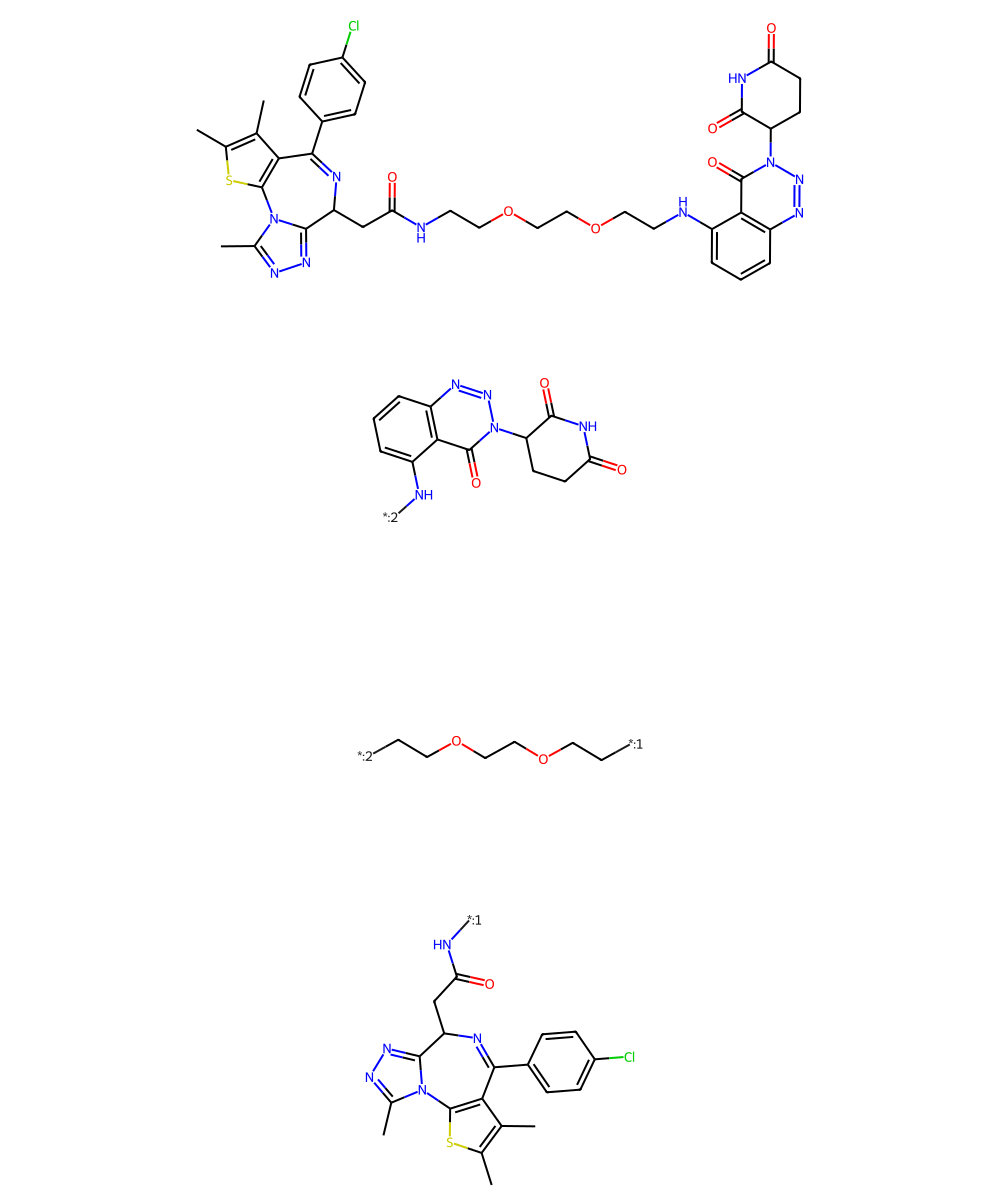

--------------------------------------------------------------------------------
PROTAC: Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=NC(CC(=O)NCCCCCCCCNc1cccc3nnn(C4CCC(=O)NC4=O)c(=O)c13)c1nnc(C)n1-2
E3:     [*:2]Nc1cccc2nnn(C3CCC(=O)NC3=O)c(=O)c12
Linker: [*:2]CCCCCCCC[*:1]
POI:    [*:1]NC(=O)CC1N=C(c2ccc(Cl)cc2)c2c(sc(C)c2C)-n2c(C)nnc21


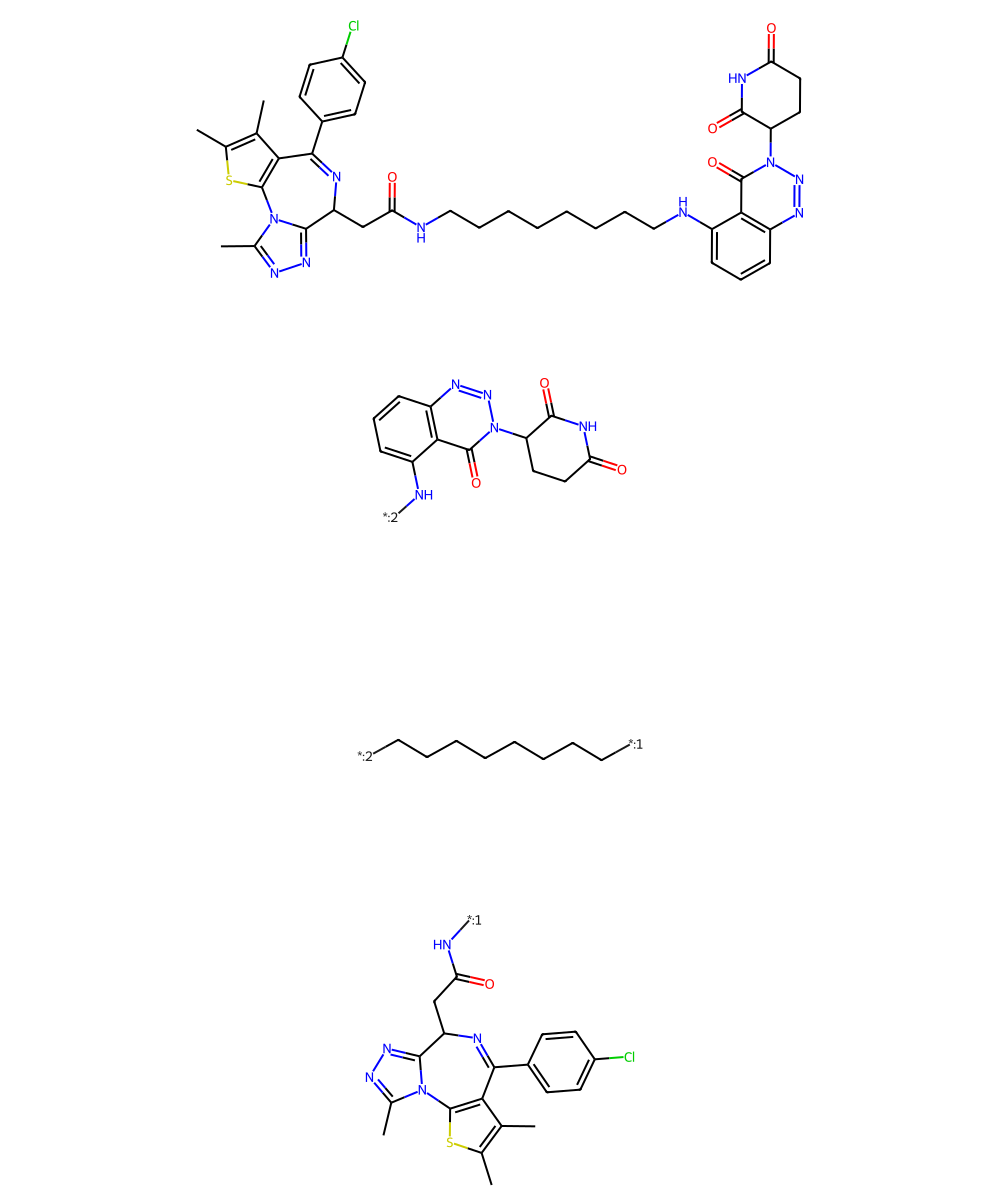

--------------------------------------------------------------------------------
PROTAC: Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=NC(CC(=O)Nc1ccc(OCCOCCOCCNc3cccc4nnn(C5CCC(=O)NC5=O)c(=O)c34)cc1)c1nnc(C)n1-2
E3:     [*:2]Nc1cccc2nnn(C3CCC(=O)NC3=O)c(=O)c12
Linker: [*:2]CCOCCOCC[*:1]
POI:    [*:1]Oc1ccc(NC(=O)CC2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)cc1


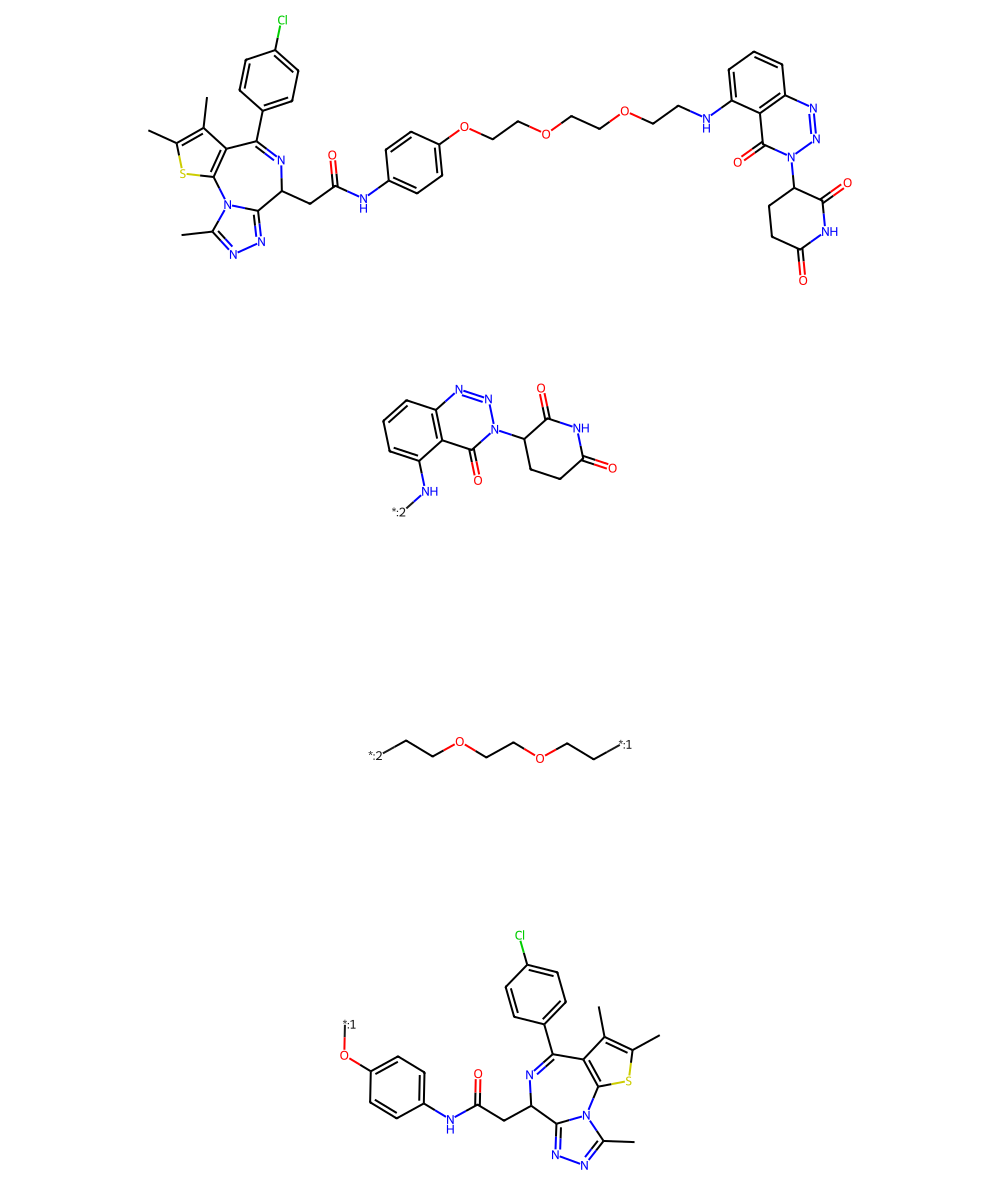

--------------------------------------------------------------------------------
PROTAC: Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=NC(CC(=O)Nc1cccc(OCCOCCOCCNc3cccc4nnn(C5CCC(=O)NC5=O)c(=O)c34)c1)c1nnc(C)n1-2
E3:     [*:2]Nc1cccc2nnn(C3CCC(=O)NC3=O)c(=O)c12
Linker: [*:2]CCOCCOCCOc1cccc([*:1])c1
POI:    [*:1]NC(=O)CC1N=C(c2ccc(Cl)cc2)c2c(sc(C)c2C)-n2c(C)nnc21


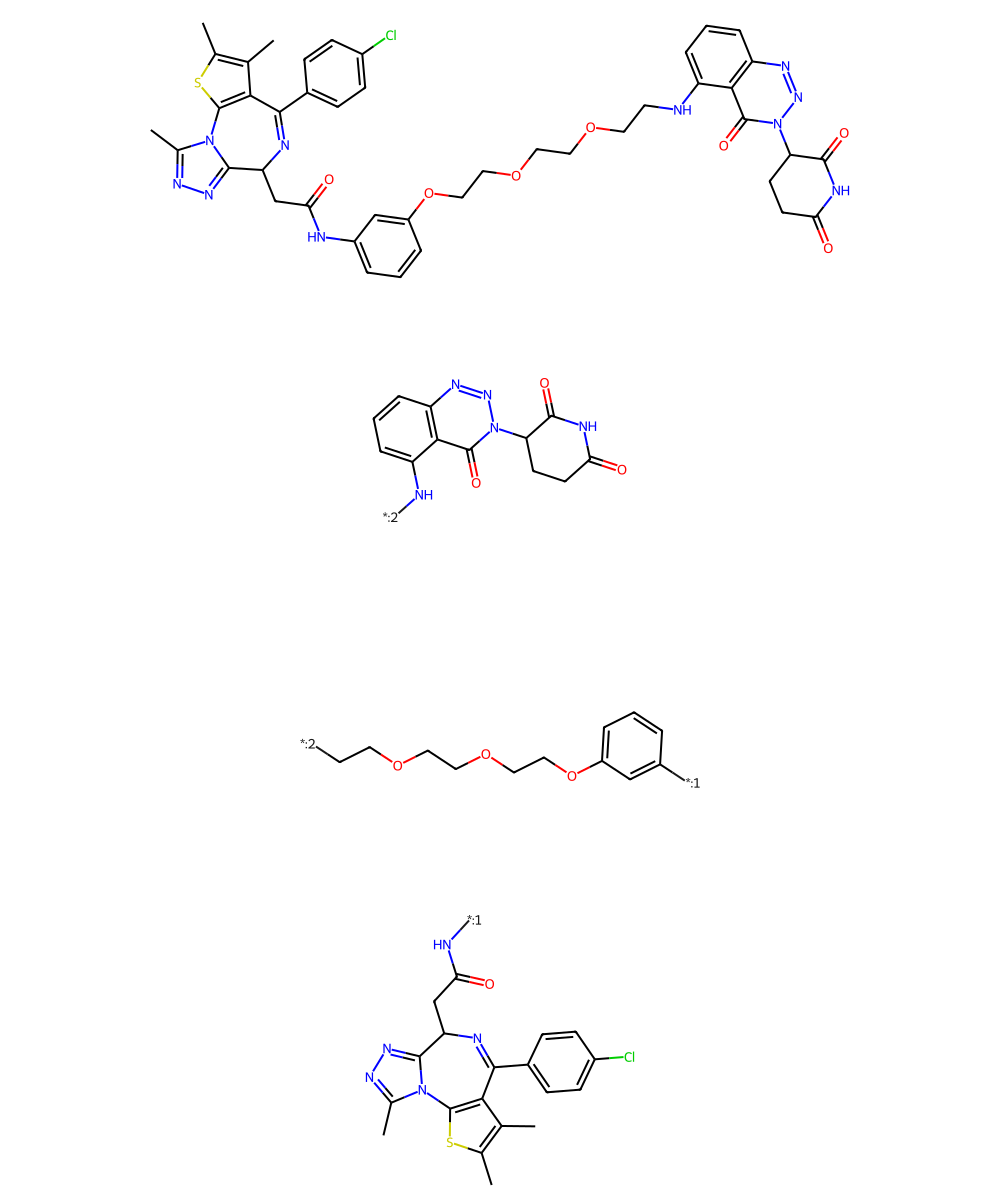

--------------------------------------------------------------------------------
PROTAC: Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=NC(CC(=O)NCCn1cc(COc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)nn1)c1nnc(C)n1-2
E3:     [*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Linker: [*:2]OCc1cn(CC[*:1])nn1
POI:    [*:1]NC(=O)CC1N=C(c2ccc(Cl)cc2)c2c(sc(C)c2C)-n2c(C)nnc21


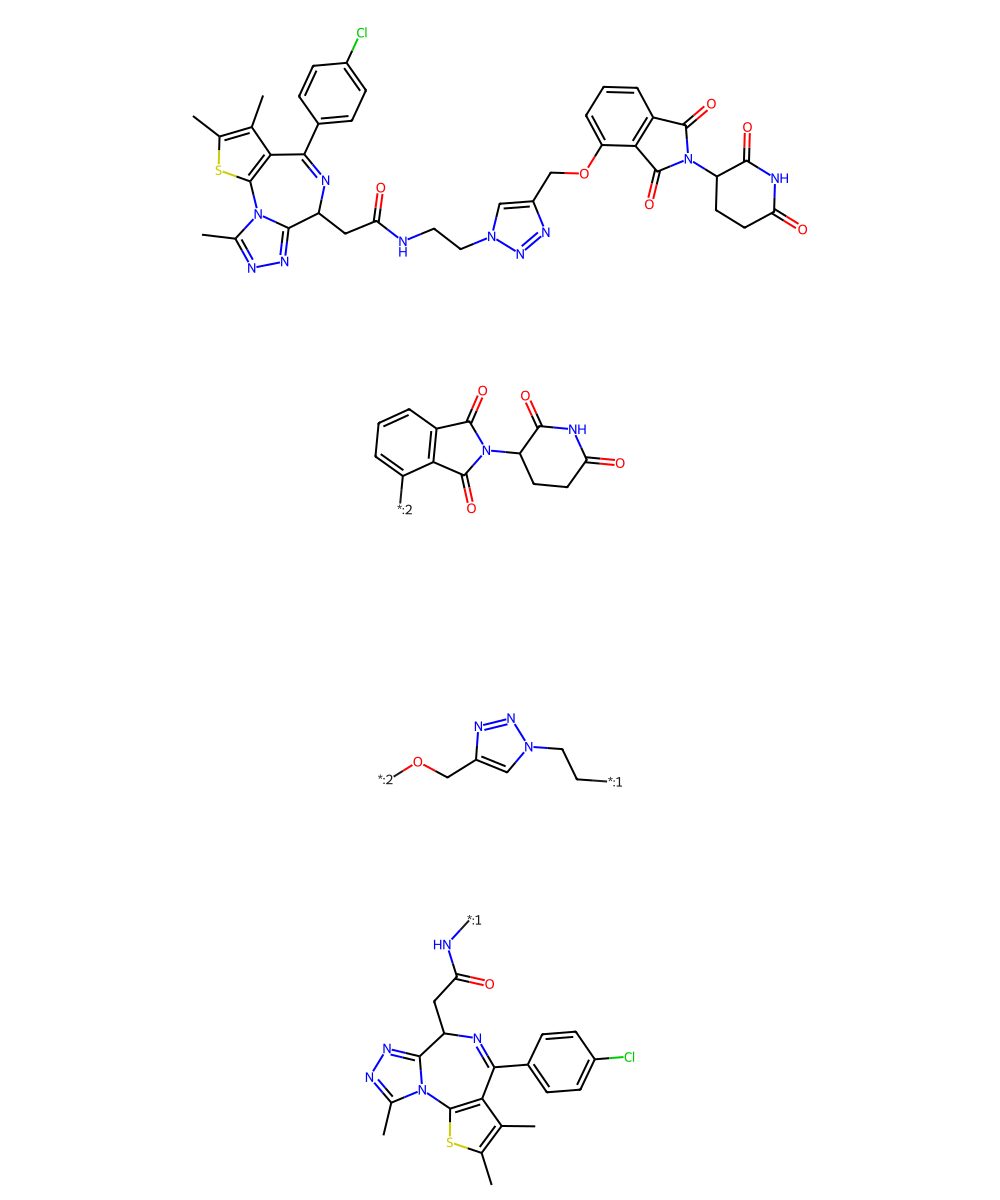

--------------------------------------------------------------------------------


In [18]:
for _, row in correct_df.iterrows():
    substructs = {}
    substructs_list = row["prediction"].split(".")
    for substruct in substructs_list:
        if "[*:1]" in substruct and "[*:2]" in substruct:
            substructs["linker"] = substruct
        elif "[*:1]" in substruct:
            substructs["poi"] = substruct
        elif "[*:2]" in substruct:
            substructs["e3"] = substruct
    print(f'PROTAC: {row["PROTAC SMILES"]}')
    print(f'E3:     {substructs["e3"]}')
    print(f'Linker: {substructs["linker"]}')
    print(f'POI:    {substructs["poi"]}')

    mols = [
        Chem.MolFromSmiles(row["PROTAC SMILES"]),
        Chem.MolFromSmiles(substructs["e3"]),
        Chem.MolFromSmiles(substructs["linker"]),
        Chem.MolFromSmiles(substructs["poi"]),
    ]
    img = Draw.MolsToGridImage(mols, molsPerRow=1, subImgSize=(1000, 300))
    safe_display(img)
    print("-" * 80)